<a href="https://colab.research.google.com/github/sajad95/Flowise/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Importingt librarries** <a class="anchor" id="1"></a>

[Table of Contents](#0.1)


In [1]:
%pip install tensorflow keras numpy

import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

from sklearn.preprocessing import MinMaxScaler

from google.colab import drive

## **2. Basic Functions** <a class="anchor" id="2"></a>

[Table of Contents](#0.1)

In [2]:
# Splitting the data
'''
def split_sequences(sequences, n_steps_in, n_steps_out):
	X, y = list(), list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps_in
		out_end_ix = end_ix + n_steps_out
		# check if we are beyond the dataset
		if out_end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix:out_end_ix, -1]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)
'''
# Data is splitted with thime (Miroslava)

import pandas as pd


def split_data(series):
    """
    Splits input series into train and test sets (80/20 split).

    Args:
        series: The input series or DataFrame to split.

    Returns:
        train_data: 80% of the data for training.
        test_data: 20% of the data for testing.
    """
    # Calculate the index for the split
    split_index = int(len(series) * 0.8)

    # Split the data
    train_data = series[:split_index]
    test_data = series[split_index:]

    return train_data, test_data


In [3]:
# stop the randomness
np.random.seed(1)
tf.random.set_seed(2)

## Reading merged data

In [4]:
def split_target_sequences(target_values, n_steps_in, n_steps_out):
    """Create output-only sequences aligned with split_sequences()."""
    y = []
    for i in range(len(target_values)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(target_values):
            break
        y.append(target_values[end_ix:out_end_ix])
    return np.array(y)

In [5]:
# mounting google drive and uploading the data
drive.mount('/content/saj')

Mounted at /content/saj


In [6]:

from pathlib import Path

folder = Path('/content/saj/MyDrive/DataElecOntario/ISO/Ontario New data /Weather files of Ontario')

city_file_map = {
    'Toronto'   : 'Toronto',
    'Kitchener' : 'Kitchener',
    'Niagara'   : 'Niagara Falls',   # note the space in the real file name
    'Ottawa'    : 'Ottawa',
    'Sudbury'   : 'Sudbury',
}

df_all = {
    city: pd.read_csv(folder / f'{filename}.csv')
    for city, filename in city_file_map.items()
}

# Example:
print(df_all['Toronto'].head())
print(df_all['Niagara'].shape)

              datetime  humidity  precip  windspeed  sealevelpressure  \
0  2015-01-01T00:00:00     50.98     0.0       41.9            1016.1   
1  2015-01-01T01:00:00     49.43     0.0       12.3            1015.1   
2  2015-01-01T02:00:00     53.74     0.0       43.9            1014.8   
3  2015-01-01T03:00:00     56.60     0.0       31.3            1014.9   
4  2015-01-01T04:00:00     58.50     0.0       35.0            1014.1   

   cloudcover  solarradiation  temp  Toronto  Essa  
0         0.0             0.0  -6.5     5317  1040  
1        97.8             0.0  -6.4     5135   995  
2         0.9             0.0  -6.6     4976   957  
3        30.0             0.0  -6.5     4851   933  
4        50.0             0.0  -6.5     4789   929  
(78887, 9)


In [7]:
df_all

{'Toronto':                   datetime  humidity  precip  windspeed  sealevelpressure  \
 0      2015-01-01T00:00:00     50.98   0.000       41.9            1016.1   
 1      2015-01-01T01:00:00     49.43   0.000       12.3            1015.1   
 2      2015-01-01T02:00:00     53.74   0.000       43.9            1014.8   
 3      2015-01-01T03:00:00     56.60   0.000       31.3            1014.9   
 4      2015-01-01T04:00:00     58.50   0.000       35.0            1014.1   
 ...                    ...       ...     ...        ...               ...   
 78882  2023-12-31T18:00:00     86.17   0.000       31.0            1015.3   
 78883  2023-12-31T19:00:00     87.98   0.198       27.1            1015.7   
 78884  2023-12-31T20:00:00     90.63   0.241       25.5            1015.9   
 78885  2023-12-31T21:00:00     93.39   0.241       27.2            1016.0   
 78886  2023-12-31T22:00:00     89.74   0.270       25.4            1016.2   
 
        cloudcover  solarradiation  temp  Toronto  

In [8]:
df_all['Toronto'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          78887 non-null  object 
 1   humidity          78887 non-null  float64
 2   precip            78887 non-null  float64
 3   windspeed         78887 non-null  float64
 4   sealevelpressure  78887 non-null  float64
 5   cloudcover        78871 non-null  float64
 6   solarradiation    78871 non-null  float64
 7   temp              78887 non-null  float64
 8   Toronto           78887 non-null  int64  
 9   Essa              78887 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.0+ MB


In [9]:
# Imputting the data

# Simple linear interpolation for all DataFrames in df_all
for city, df in df_all.items():

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime').sort_index()

    # Apply linear interpolation to all numeric columns
    df_all[city] = df.interpolate(method='linear', limit_direction='both').reset_index()

In [10]:
df_all['Ottawa'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          78887 non-null  datetime64[ns]
 1   humidity          78887 non-null  float64       
 2   precip            78887 non-null  float64       
 3   windspeed         78887 non-null  float64       
 4   sealevelpressure  78887 non-null  float64       
 5   cloudcover        78887 non-null  float64       
 6   solarradiation    78887 non-null  float64       
 7   temp              78887 non-null  float64       
 8   Ottawa            78887 non-null  int64         
 9   East              78887 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 6.0 MB


In [11]:
# Your function (slightly improved to work directly on DataFrame column)
def make_time_features(df, time_col='datetime'):
    times = pd.to_datetime(df[time_col])
    datetimes = pd.DatetimeIndex(times)

    df['hour']   = datetimes.hour
    df['dayofw'] = datetimes.dayofweek   # 0 = Monday, 6 = Sunday
    df['month']  = datetimes.month
    return df

# ------------------------------------------------------------------
# Apply to ALL cities in df_all
# ------------------------------------------------------------------
for city, df in df_all.items():
    # 1. Ensure datetime column exists and is parsed
    if 'datetime' not in df.columns:
        raise ValueError(f"Column 'datetime' not found in {city} DataFrame")

    df['datetime'] = pd.to_datetime(df['datetime'])

    # 2. Format datetime as "2015-01-01T00:00:00" (ISO with T)
    df['datetime'] = df['datetime'].dt.strftime('%Y-%m-%dT%H:%M:%S')

    # 3. Re-parse it back (so pandas knows it's datetime again for feature extraction)
    df['datetime'] = pd.to_datetime(df['datetime'])

    # 4. Add time features
    df_all[city] = make_time_features(df, time_col='datetime')



In [12]:
df_all['Sudbury'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        78887 non-null  datetime64[ns]
 1   temp            78887 non-null  float64       
 2   humidity        78887 non-null  float64       
 3   precip          78887 non-null  float64       
 4   windspeed       78887 non-null  float64       
 5   cloudcover      78887 non-null  float64       
 6   solarradiation  78887 non-null  float64       
 7   Northwest       78887 non-null  int64         
 8   Northeast       78887 non-null  int64         
 9   West            78887 non-null  int64         
 10  hour            78887 non-null  int32         
 11  dayofw          78887 non-null  int32         
 12  month           78887 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(3), int64(3)
memory usage: 6.9 MB


In [13]:
East = df_all['Ottawa'].drop(columns = ['Ottawa'])
Ottawa = df_all['Ottawa'].drop(columns = ['East'])

Toronto = df_all['Toronto'].drop(columns = ['Essa'])
Essa = df_all['Toronto'].drop(columns = ['Toronto'])

Southwest = df_all['Kitchener'].drop(columns = ['West'])

West = df_all['Sudbury'].drop(columns = ['Northwest','Northeast'])

Northwest = df_all['Sudbury'].drop(columns = ['Northeast','West'])

Northeast = df_all['Sudbury'].drop(columns = ['Northwest','West'])

Niagara = df_all['Niagara']

In [14]:
# Extract each region's energy column using the datetime column
energy_data = {}

# Helper function to extract energy column with datetime
def extract_energy(df_source, region_name):
    if region_name in df_source.columns and 'datetime' in df_source.columns:
        df_temp = df_source[['datetime', region_name]].copy()
        df_temp.set_index('datetime', inplace=True)
        return df_temp[region_name]
    return None

# Extract each region
energy_data['East'] = extract_energy(df_all['Ottawa'], 'East')
energy_data['Ottawa'] = extract_energy(df_all['Ottawa'], 'Ottawa')
energy_data['Toronto'] = extract_energy(df_all['Toronto'], 'Toronto')
energy_data['Essa'] = extract_energy(df_all['Toronto'], 'Essa')
energy_data['Southwest'] = extract_energy(df_all['Kitchener'], 'Southwest')
energy_data['West'] = extract_energy(df_all['Sudbury'], 'West')
energy_data['Northwest'] = extract_energy(df_all['Sudbury'], 'Northwest')
energy_data['Northeast'] = extract_energy(df_all['Sudbury'], 'Northeast')
energy_data['Niagara'] = extract_energy(df_all['Niagara'], 'Niagara')

# Remove None values
energy_data = {k: v for k, v in energy_data.items() if v is not None}

# Combine into single DataFrame with datetime as index
if energy_data:
    df_energy = pd.DataFrame(energy_data)

    # Ensure datetime index is properly formatted (only if needed)
    if not isinstance(df_energy.index, pd.DatetimeIndex):
        df_energy.index = pd.to_datetime(df_energy.index, errors='coerce')

    print(f"Energy DataFrame created with shape: {df_energy.shape}")
    print(f"Date range: {df_energy.index.min()} to {df_energy.index.max()}")
    print(f"Columns: {list(df_energy.columns)}")
    print(f"\nFirst few rows:")
    print(df_energy.head())

Energy DataFrame created with shape: (78887, 9)
Date range: 2015-01-01 00:00:00 to 2023-12-31 22:00:00
Columns: ['East', 'Ottawa', 'Toronto', 'Essa', 'Southwest', 'West', 'Northwest', 'Northeast', 'Niagara']

First few rows:
                     East  Ottawa  Toronto  Essa  Southwest  West  Northwest  \
datetime                                                                       
2015-01-01 00:00:00   935    1026     5317  1040       2881  1346        604   
2015-01-01 01:00:00   911     988     5135   995       2784  1289        597   
2015-01-01 02:00:00   900     966     4976   957       2679  1249        592   
2015-01-01 03:00:00   903     954     4851   933       2576  1221        590   
2015-01-01 04:00:00   904     954     4789   929       2543  1217        585   

                     Northeast  Niagara  
datetime                                 
2015-01-01 00:00:00       1314      411  
2015-01-01 01:00:00       1282      388  
2015-01-01 02:00:00       1280      372  
2015

In [15]:
# Add Ontario column as the sum of all energy columns
df_energy['Ontario'] = df_energy.sum(axis=1)

print(f"\nAdded 'Ontario' column (sum of all regions)")
print(f"Updated DataFrame shape: {df_energy.shape}")
print(f"Columns: {list(df_energy.columns)}")
print(f"\nFirst few rows with Ontario column:")
print(df_energy.head())


Added 'Ontario' column (sum of all regions)
Updated DataFrame shape: (78887, 10)
Columns: ['East', 'Ottawa', 'Toronto', 'Essa', 'Southwest', 'West', 'Northwest', 'Northeast', 'Niagara', 'Ontario']

First few rows with Ontario column:
                     East  Ottawa  Toronto  Essa  Southwest  West  Northwest  \
datetime                                                                       
2015-01-01 00:00:00   935    1026     5317  1040       2881  1346        604   
2015-01-01 01:00:00   911     988     5135   995       2784  1289        597   
2015-01-01 02:00:00   900     966     4976   957       2679  1249        592   
2015-01-01 03:00:00   903     954     4851   933       2576  1221        590   
2015-01-01 04:00:00   904     954     4789   929       2543  1217        585   

                     Northeast  Niagara  Ontario  
datetime                                          
2015-01-01 00:00:00       1314      411    14874  
2015-01-01 01:00:00       1282      388    14369  


In [16]:
# Get top 5 energy values for each year
years = [2021, 2022, 2023]
top_5_by_year = {}

for year in years:
    # Filter data for this year
    df_year = df_energy[df_energy.index.year == year].copy()

    if len(df_year) > 0:
        # Get top 5 Ontario energy values for this year
        top_5 = df_year.nlargest(5, 'Ontario')[['Ontario']].copy()
        top_5['datetime'] = top_5.index
        top_5['year'] = year

        top_5_by_year[year] = top_5

        print(f"\n{'='*70}")
        print(f"Top 5 Ontario Energy Values in {year}")
        print(f"{'='*70}")
        print(top_5.to_string(index=False))
        print(f"\nSummary for {year}:")
        print(f"  Maximum: {df_year['Ontario'].max():,.2f}")
        print(f"  Minimum: {df_year['Ontario'].min():,.2f}")
        print(f"  Mean: {df_year['Ontario'].mean():,.2f}")
    else:
        print(f"\nNo data found for year {year}")

# Optional: Create a combined DataFrame with all top 5 values
if top_5_by_year:
    print(f"\n{'='*70}")
    print(f"Combined Top 5 Energy Values (All Years)")
    print(f"{'='*70}")

    all_top_5 = pd.concat(top_5_by_year.values(), ignore_index=False)
    all_top_5 = all_top_5.sort_values('Ontario', ascending=False)

    print(all_top_5[['datetime', 'year', 'Ontario']].to_string(index=False))


Top 5 Ontario Energy Values in 2021
 Ontario            datetime  year
   22807 2021-08-24 17:00:00  2021
   22743 2021-08-26 14:00:00  2021
   22705 2021-08-26 15:00:00  2021
   22643 2021-08-26 13:00:00  2021
   22615 2021-08-24 18:00:00  2021

Summary for 2021:
  Maximum: 22,807.00
  Minimum: 10,519.00
  Mean: 15,272.27

Top 5 Ontario Energy Values in 2022
 Ontario            datetime  year
   22614 2022-07-19 17:00:00  2022
   22552 2022-07-19 18:00:00  2022
   22312 2022-07-19 16:00:00  2022
   22226 2022-07-19 19:00:00  2022
   22148 2022-07-19 15:00:00  2022

Summary for 2022:
  Maximum: 22,614.00
  Minimum: 10,675.00
  Mean: 15,634.50

Top 5 Ontario Energy Values in 2023
 Ontario            datetime  year
   23403 2023-09-05 17:00:00  2023
   23209 2023-09-05 18:00:00  2023
   23092 2023-09-05 16:00:00  2023
   23074 2023-09-05 19:00:00  2023
   23060 2023-09-05 20:00:00  2023

Summary for 2023:
  Maximum: 23,403.00
  Minimum: 10,937.00
  Mean: 15,624.39

Combined Top 5 Energy

In [17]:
East.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          78887 non-null  datetime64[ns]
 1   humidity          78887 non-null  float64       
 2   precip            78887 non-null  float64       
 3   windspeed         78887 non-null  float64       
 4   sealevelpressure  78887 non-null  float64       
 5   cloudcover        78887 non-null  float64       
 6   solarradiation    78887 non-null  float64       
 7   temp              78887 non-null  float64       
 8   East              78887 non-null  int64         
 9   hour              78887 non-null  int32         
 10  dayofw            78887 non-null  int32         
 11  month             78887 non-null  int32         
dtypes: datetime64[ns](1), float64(7), int32(3), int64(1)
memory usage: 6.3 MB


/tmp/ipykernel_2554/1241871265.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = df_merged[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(method='ffill')


East: R² = 0.6786
Ottawa: R² = 0.6913
Toronto: R² = 0.8110
Essa: R² = 0.7427
Southwest: R² = 0.7758
West: R² = 0.6660
Northwest: R² = 0.6778
Northeast: R² = 0.7577
Niagara: R² = 0.5912
Ontario: R² = 0.7833


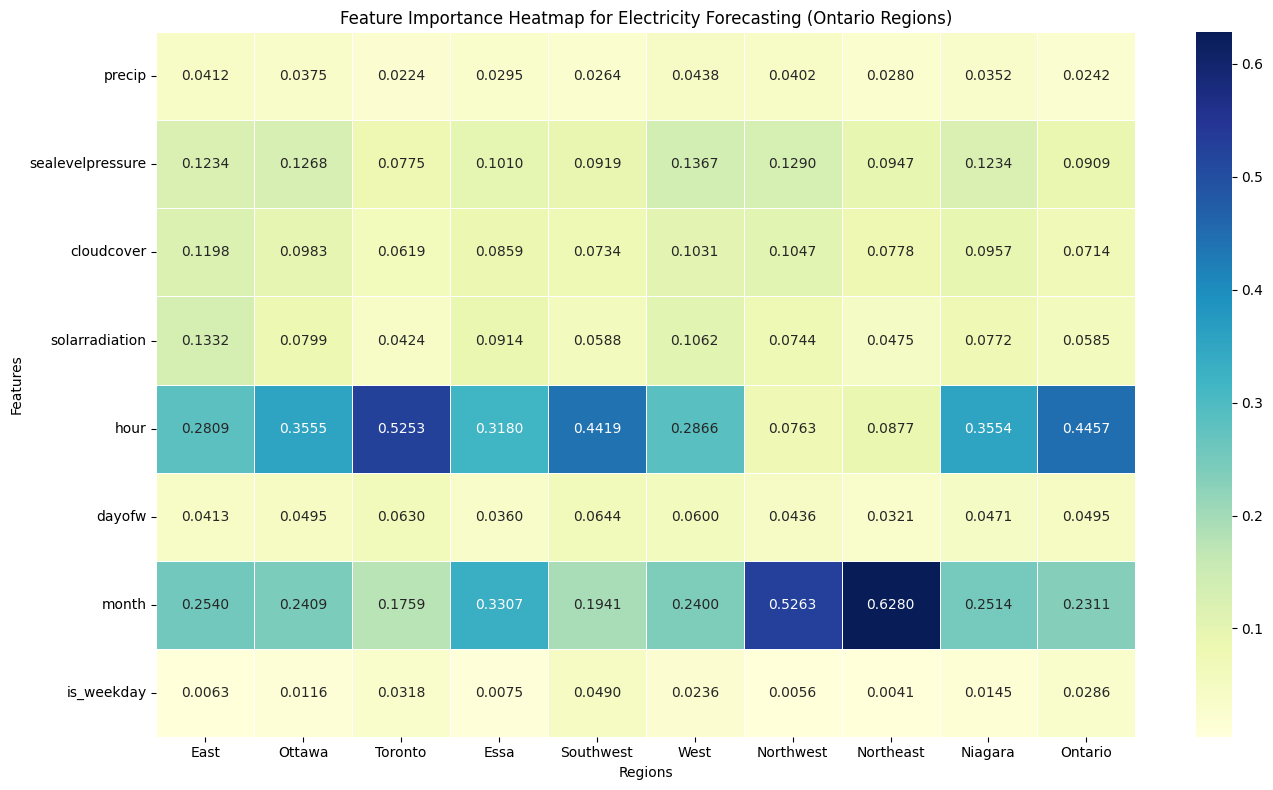


Feature Importance Matrix:
                      East    Ottawa   Toronto      Essa  Southwest      West  \
precip            0.041190  0.037509  0.022426  0.029469   0.026442  0.043827   
sealevelpressure  0.123362  0.126826  0.077488  0.100996   0.091884  0.136696   
cloudcover        0.119770  0.098340  0.061851  0.085857   0.073398  0.103067   
solarradiation    0.133185  0.079948  0.042369  0.091388   0.058780  0.106187   
hour              0.280922  0.355471  0.525262  0.318037   0.441935  0.286596   
dayofw            0.041269  0.049484  0.062954  0.035989   0.064434  0.060002   
month             0.254027  0.240864  0.175886  0.330737   0.194117  0.240010   
is_weekday        0.006276  0.011557  0.031764  0.007526   0.049009  0.023616   

                  Northwest  Northeast   Niagara   Ontario  
precip             0.040152   0.027984  0.035246  0.024246  
sealevelpressure   0.129010   0.094734  0.123365  0.090889  
cloudcover         0.104670   0.077818  0.095745  0.071444 

In [18]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Aggregate weather data from all cities (take mean)
weather_cols = ['umidity', 'precip','temp'
                'windspeed', 'sealevelpressure', 'cloudcover',
                'solarradiation',
                'hour', 'dayofw', 'month']
weather_list = []

for city, df_city in df_all.items():
    df_city = df_city.copy()
    df_city['datetime'] = pd.to_datetime(df_city['datetime'])
    df_city.set_index('datetime', inplace=True)
    available = [c for c in weather_cols if c in df_city.columns]
    weather_list.append(df_city[available])

# Combine and take mean across cities
weather_combined = pd.concat(weather_list, axis=1, keys=range(len(weather_list)))
X_weather = pd.DataFrame(index=weather_combined.index)

for col in weather_cols:
    if col in weather_combined.columns.get_level_values(1):
        cols = [c for c in weather_combined.columns if col in str(c)]
        if cols:
            X_weather[col] = weather_combined[cols].mean(axis=1)

# Add is_weekday
if 'dayofw' in X_weather.columns:
    X_weather['is_weekday'] = (X_weather['dayofw'] < 5).astype(int)

# Merge with energy data
df_merged = pd.merge(X_weather, df_energy, left_index=True, right_index=True, how='inner')

# Feature importance analysis
feature_cols = [c for c in X_weather.columns if c in df_merged.columns]
target_regions = [c for c in df_merged.columns if c not in feature_cols]

X = df_merged[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(method='ffill')
feature_importance_results = {}

for region in target_regions:
    y = pd.to_numeric(df_merged[region], errors='coerce')
    valid = ~(y.isna() | X.isna().any(axis=1))
    X_clean, y_clean = X[valid], y[valid]

    if len(X_clean) == 0:
        continue

    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
    model = RandomForestRegressor(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)
    feature_importance_results[region] = model.feature_importances_
    print(f"{region}: R² = {model.score(X_test, y_test):.4f}")

# Display results
importance_df = pd.DataFrame(feature_importance_results, index=feature_cols)

plt.figure(figsize=(14, 8))
sns.heatmap(importance_df, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.4f')
plt.title('Feature Importance Heatmap for Electricity Forecasting (Ontario Regions)')
plt.xlabel('Regions')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\nFeature Importance Matrix:")
print(importance_df)
print("\nAverage Importance:")
print(importance_df.mean(axis=1).sort_values(ascending=False))

East: R² = 0.7760
Ottawa: R² = 0.8181
Toronto: R² = 0.9259
Essa: R² = 0.8990
Southwest: R² = 0.9010
West: R² = 0.8090
Northwest: R² = 0.7652
Northeast: R² = 0.8333
Niagara: R² = 0.7171
Ontario: R² = 0.9187


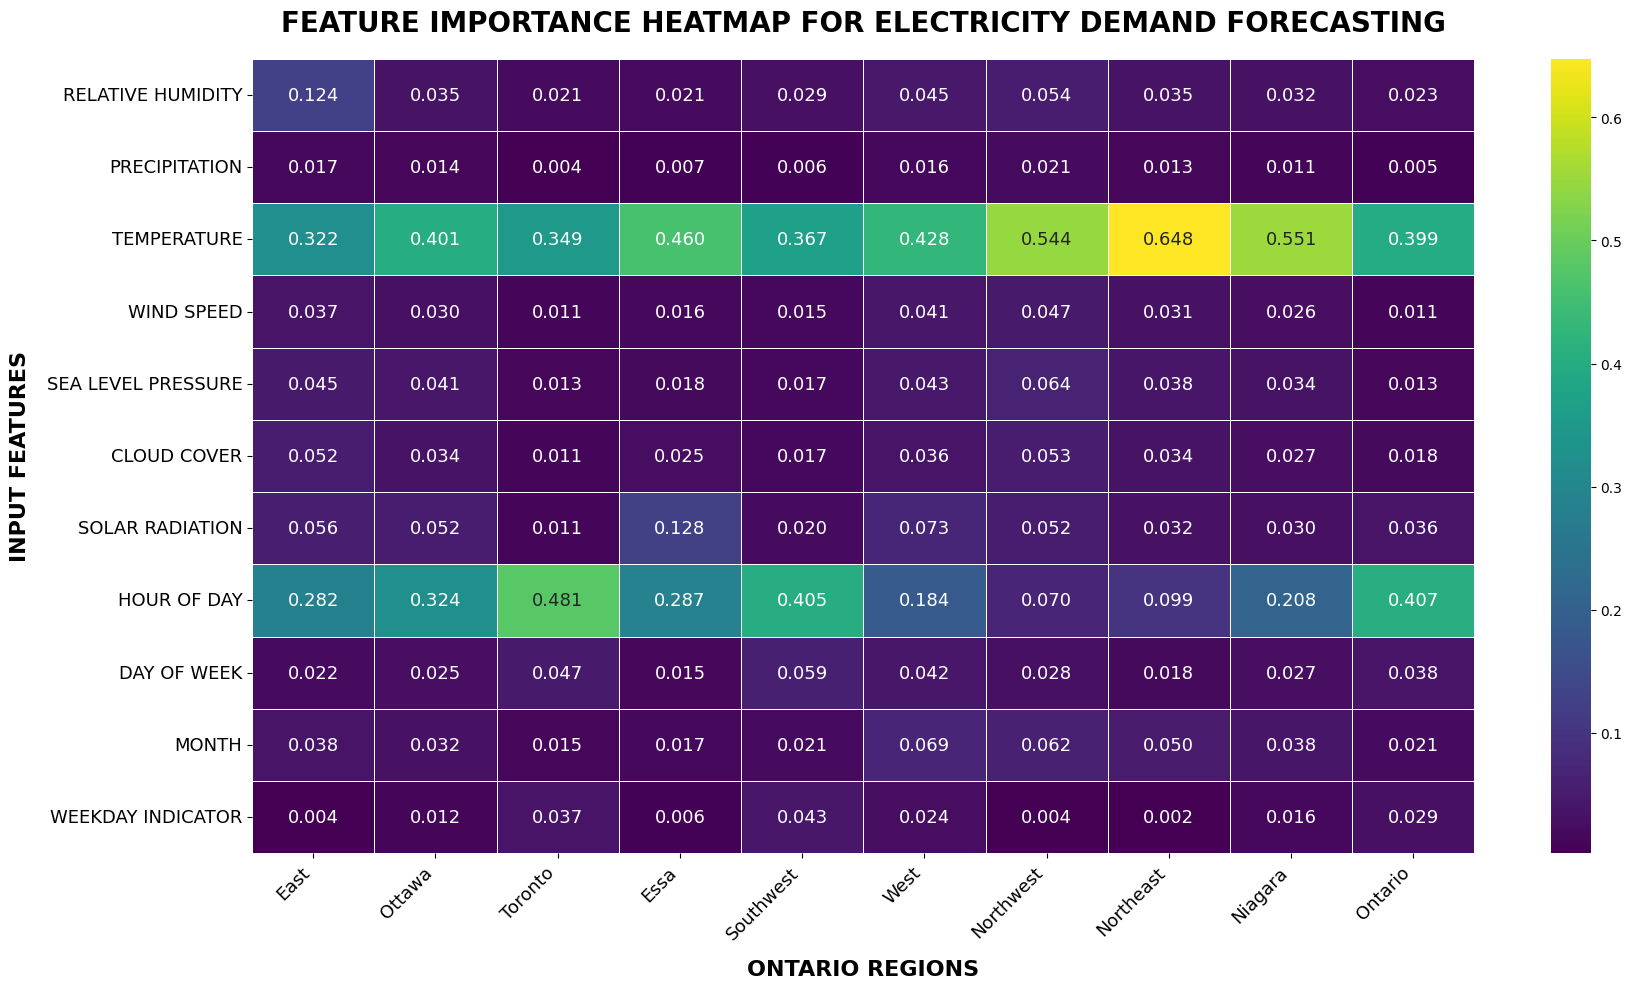


Feature Importance Matrix:
                      East    Ottawa   Toronto      Essa  Southwest      West  \
humidity          0.124495  0.034794  0.020919  0.021249   0.028882  0.044650   
precip            0.017051  0.014103  0.004496  0.007248   0.006141  0.016178   
temp              0.322148  0.401059  0.349057  0.460269   0.367205  0.427979   
windspeed         0.036918  0.030039  0.010774  0.015771   0.015389  0.041397   
sealevelpressure  0.045372  0.040817  0.012926  0.017974   0.016869  0.043266   
cloudcover        0.052343  0.033628  0.011489  0.024782   0.017388  0.035593   
solarradiation    0.055590  0.052253  0.010529  0.128192   0.020411  0.072745   
hour              0.282492  0.323908  0.481100  0.287333   0.405170  0.184144   
dayofw            0.022081  0.025383  0.046776  0.014770   0.058660  0.041790   
month             0.037578  0.032189  0.014654  0.016538   0.021362  0.068679   
is_weekday        0.003932  0.011826  0.037278  0.005873   0.042524  0.023578   


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate weather data from all cities (take mean)
weather_cols = [
    'humidity', 'precip', 'temp',
    'windspeed', 'sealevelpressure', 'cloudcover',
    'solarradiation', 'hour', 'dayofw', 'month'
]

weather_list = []

for city, df_city in df_all.items():
    df_city = df_city.copy()
    df_city['datetime'] = pd.to_datetime(df_city['datetime'])
    df_city.set_index('datetime', inplace=True)

    available = [c for c in weather_cols if c in df_city.columns]
    weather_list.append(df_city[available])

# Combine and take mean across cities
weather_combined = pd.concat(weather_list, axis=1, keys=range(len(weather_list)))
X_weather = pd.DataFrame(index=weather_combined.index)

for col in weather_cols:
    if col in weather_combined.columns.get_level_values(1):
        cols = [c for c in weather_combined.columns if c[1] == col]
        if cols:
            X_weather[col] = weather_combined[cols].mean(axis=1)

# Add weekday indicator
if 'dayofw' in X_weather.columns:
    X_weather['is_weekday'] = (X_weather['dayofw'] < 5).astype(int)

# Merge with energy data
df_merged = pd.merge(X_weather, df_energy, left_index=True, right_index=True, how='inner')

# Feature importance analysis
feature_cols = [c for c in X_weather.columns if c in df_merged.columns]
target_regions = [c for c in df_merged.columns if c not in feature_cols]

X = (
    df_merged[feature_cols]
    .apply(pd.to_numeric, errors='coerce')
    .ffill()
    .bfill()
)

feature_importance_results = {}

for region in target_regions:
    y = pd.to_numeric(df_merged[region], errors='coerce')
    valid = ~(y.isna() | X.isna().any(axis=1))
    X_clean, y_clean = X[valid], y[valid]

    if len(X_clean) == 0:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42
    )

    model = RandomForestRegressor(random_state=42, n_estimators=100)
    model.fit(X_train, y_train)

    feature_importance_results[region] = model.feature_importances_
    print(f"{region}: R² = {model.score(X_test, y_test):.4f}")

# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_results, index=feature_cols)

# Rename features for figure display
feature_name_map = {
    'humidity': 'RELATIVE HUMIDITY',
    'precip': 'PRECIPITATION',
    'temp': 'TEMPERATURE',
    'windspeed': 'WIND SPEED',
    'sealevelpressure': 'SEA LEVEL PRESSURE',
    'cloudcover': 'CLOUD COVER',
    'solarradiation': 'SOLAR RADIATION',
    'hour': 'HOUR OF DAY',
    'dayofw': 'DAY OF WEEK',
    'month': 'MONTH',
    'is_weekday': 'WEEKDAY INDICATOR'
}

importance_df_display = importance_df.rename(index=feature_name_map)

# Plot heatmap
plt.figure(figsize=(18, 10))

sns.heatmap(
    importance_df_display,
    annot=True,
    cmap='viridis',
    linewidths=0.6,
    linecolor='white',
    fmt='.3f',
    annot_kws={"size": 13}
)

plt.title(
    'FEATURE IMPORTANCE HEATMAP FOR ELECTRICITY DEMAND FORECASTING',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel('ONTARIO REGIONS', fontsize=16, fontweight='bold', labelpad=12)
plt.ylabel('INPUT FEATURES', fontsize=16, fontweight='bold', labelpad=12)

plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13, rotation=0)

plt.tight_layout()
plt.show()

print("\nFeature Importance Matrix:")
print(importance_df)

print("\nAverage Importance:")
print(importance_df.mean(axis=1).sort_values(ascending=False))

## Running the model with the Selected Hyperparamters



## Common hyperparameters across cities (best configs)

**Strongly consistent (6/6 cities):**

* **activation = tanh**
* **use_normalization = True**
* **use_target_lags = True**

**Mostly consistent (5/6 cities):**

* **use_lstm = False** → meaning **GRU** was best for 5 cities (only Southwest preferred LSTM)
* **use_bidirectional = True** (only Ottawa preferred unidirectional)
* **use_stage2 = True** (only Toronto preferred stage2 = False)

**Most common numeric choices (mode):**

* **dropout_rate = 0.2** (4/6 cities)
* **lstm_units** varies a lot (64–256), with **256** appearing in 3 cities.
* **learning_rate** tends to sit in the **~1.4e-4 to 6.1e-4** range in your winners.

---

## Best hyperparameters in each city (Excel-ready table)

One row per city (so you can paste into Excel easily), with **many columns**:

| City      | Best val_loss |  Best R2 | activation | RNN type (use_lstm) | Bidirectional | Dropout | Units | Learning rate | Normalization | Target lags | Stage 2   |
| --------- | ------------: | -------: | ---------- | ------------------- | ------------- | ------: | ----: | ------------: | ------------- | ----------- | --------- |
| Toronto   |      0.032890 | 0.923184 | tanh       | GRU (False)         | True          |     0.3 |    64 |  0.0003245435 | True          | True        | **False** |
| Ottawa    |      0.043051 | 0.873594 | tanh       | GRU (False)         | **False**     |     0.2 |   128 |  0.0002238693 | True          | True        | True      |
| Essa      |      0.056459 | 0.868597 | tanh       | GRU (False)         | True          |     0.4 |   256 |  0.0006065100 | True          | True        | True      |
| Southwest |      0.044680 | 0.873109 | tanh       | **LSTM (True)**     | True          |     0.2 |   256 |  0.0001430487 | True          | True        | True      |
| West      |      0.118883 | 0.780383 | tanh       | GRU (False)         | True          |     0.2 |   128 |  0.0003489653 | True          | True        | True      |
| Northwest |      0.088124 | 0.803265 | tanh       | GRU (False)         | True          |     0.2 |   256 |  0.0002382439 | True          | True        | True      |

---

## Quick takeaways you can use immediately

* If you want a **strong “default starting point”** for a new city based on your results:
  **tanh + GRU + bidirectional + dropout 0.2 + normalization + lags + stage2**
  (This matches the majority winners.)
* Toronto is the main exception: **stage2 off** and **smaller units (64)** with **dropout 0.3**.

If you paste the other cities’ results too (East, Niagara, etc.), I can expand the same table and also compute a “most robust” configuration based on frequency + performance.


## Developing model and saving model for Ontario Prediction

In [ ]:
# Peak season oversampling configuration
USE_PEAK_SEASON_OVERSAMPLING = True  # Enable/disable peak season oversampling
PEAK_MONTHS = [1, 2, 7, 8, 12]  # Peak months (Jan, Feb, Jul, Aug, Dec - adjust based on your data)
PEAK_HOUR_ZSCORE_THRESHOLD = 2  # Z-score threshold for peak hours within peak months
OVERSAMPLING_RATIO = 2.0  # How many times to repeat peak sequences (2.0 = double them)

In [ ]:

def _build_previous_year_stats(series):
    """
    Build mean/std for each year using only the immediately previous year.
    """
    series = pd.Series(series).dropna()
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series must have a DatetimeIndex.")

    stats = {}
    years = sorted(series.index.year.unique())

    for year in years:
        prev_year_values = series[series.index.year == (year - 1)]
        if len(prev_year_values) == 0:
            stats[year] = None
        else:
            stats[year] = {
                'mean': prev_year_values.mean(),
                'std': prev_year_values.std(ddof=0) + 1e-8
            }

    return stats


def identify_peak_season_sequences(X_train, y_train, train_data, n_steps_in,
                                   peak_months, zscore_threshold=2.0):
    """
    Identify training sequences from peak months that contain peak hours,
    using only the previous year's data to compute the threshold.
    """
    peak_sequences = np.zeros(len(y_train), dtype=bool)
    year_stats = _build_previous_year_stats(train_data.iloc[:, -1])

    for i in range(len(y_train)):
        seq_end_idx = i + n_steps_in
        if seq_end_idx >= len(train_data):
            continue

        timestamp = train_data.index[seq_end_idx]
        seq_year = timestamp.year
        seq_month = timestamp.month

        if seq_month not in peak_months:
            continue

        stats = year_stats.get(seq_year)
        if stats is None:
            continue

        mean_val = stats['mean']
        std_val = stats['std']

        seq_targets = y_train[i]
        z_scores = (seq_targets - mean_val) / std_val

        if np.any(z_scores >= zscore_threshold):
            peak_sequences[i] = True

    return peak_sequences

In [ ]:
def identify_peak_sequences(y_train, train_data, n_steps_in,
                            zscore_threshold=2.0, subset_ratio=None):
    """
    Identify peak sequences using only the previous year's data
    to compute the threshold for each current year.
    """
    year_stats = _build_previous_year_stats(train_data.iloc[:, -1])

    peak_scores = np.full(len(y_train), -np.inf)
    valid_mask = np.zeros(len(y_train), dtype=bool)

    for i in range(len(y_train)):
        seq_end_idx = i + n_steps_in
        if seq_end_idx >= len(train_data):
            continue

        seq_year = train_data.index[seq_end_idx].year
        stats = year_stats.get(seq_year)
        if stats is None:
            continue

        mean_val = stats['mean']
        std_val = stats['std']

        seq = y_train[i]
        z_scores = (seq - mean_val) / std_val

        peak_scores[i] = np.max(z_scores)
        valid_mask[i] = True

    peak_sequences = valid_mask & (peak_scores >= zscore_threshold)

    if subset_ratio is not None and subset_ratio > 0:
        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) == 0:
            return peak_sequences

        n_select = max(1, int(len(valid_indices) * subset_ratio))
        top_indices = valid_indices[np.argsort(peak_scores[valid_indices])[-n_select:]]

        peak_sequences = np.zeros(len(y_train), dtype=bool)
        peak_sequences[top_indices] = True

    return peak_sequences

In [ ]:
"""
Improved Multistep Forecasting Model with Enhanced Features

- Safely uses historical city values as lagged features (prevents data leakage)
- Better model architecture (LSTM instead of SimpleRNN)
- Enhanced feature engineering options
- Improved hyperparameters and optimizer
- Supports multi-city aggregation while denormalizing prior to combining forecasts
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from numpy import hstack  # Changed from scipy.sparse.hstack
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# Define your input features (everything except target)
INPUT_FEATURES = [
    'temp',
    'solarradiation',
    'humidity',
    'precip',
    'windspeed',
    'cloudcover',
    'hour',
    'dayofw',
]

# Define your target variable
TARGET_COLUMN = 'Toronto'  # Change to 'Northeast' or 'West' if needed

# Model parameters
# EPOCHS = 50
N_STEPS_IN = 24   # Input sequence length
N_STEPS_OUT = 24  # Forecast horizon
TRAIN_SIZE = 52560

# Normalization (set to True if you want to normalize)
USE_NORMALIZATION = True

# NEW: Configuration for using historical target values
USE_TARGET_LAGS = True  # Set to True to include historical values
LAG_WINDOW = 8  # Number of historical time steps to include (should match N_STEPS_IN for safety)

# NEW: Model architecture improvements
USE_LSTM = True
USE_BIDIRECTIONAL = False
USE_GRU = False
DROPOUT_RATE = 0.2
LSTM_UNITS = 128

# NEW: Optimizer improvements
USE_ADAM = True
LEARNING_RATE = 0.001
USE_LEARNING_RATE_SCHEDULER = True

# NEW: Feature engineering options
USE_CYCLICAL_ENCODING = True
USE_ROLLING_STATS = True


def split_data(series, train_size=TRAIN_SIZE):
    """Split data into train and test sets."""
    train_data = series[:train_size]
    test_data = series[train_size:]
    return train_data, test_data


def split_sequences(sequences, n_steps_in, n_steps_out):
    """Split multivariate sequence into samples for multistep forecasting."""
    X, y = list(), list()
    for i in range(len(sequences)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix:out_end_ix, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


def create_lagged_features(data, target_column, lag_window=LAG_WINDOW):
    """Create lagged features from target column safely."""
    if not USE_TARGET_LAGS:
        return data

    data = data.copy()
    for lag in range(1, lag_window + 1):
        col_name = f'{target_column}_lag{lag}'
        data[col_name] = data[target_column].shift(lag)

    # Keep the original DatetimeIndex; do NOT reset it
    data = data.iloc[lag_window:].copy()
    return data


def create_cyclical_features(data):
    """Create cyclical encoding for time-based features."""
    if not USE_CYCLICAL_ENCODING:
        return data
    data = data.copy()
    if 'hour' in data.columns:
        data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
        data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
    if 'dayofw' in data.columns:
        data['dayofw_sin'] = np.sin(2 * np.pi * data['dayofw'] / 7)
        data['dayofw_cos'] = np.cos(2 * np.pi * data['dayofw'] / 7)
    return data




def R_squared(y_true, y_pred):
    """Calculate R-squared score."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


class Metric:
    """Class to compute and store various metrics."""
    def __init__(self):
        self.predictions = []
        self.real_values = []

    def add(self, y_true, y_pred):
        self.predictions.append(y_pred)
        self.real_values.append(y_true)

    def get(self):
        if len(self.predictions) == 0:
            return pd.DataFrame()
        y_pred_all = np.concatenate(self.predictions, axis=0)
        y_true_all = np.concatenate(self.real_values, axis=0)
        metrics = {
            'MAE': [np.mean(np.abs(y_true_all - y_pred_all))],
            'RMSE': [np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))],
            'R2': [R_squared(y_true_all.flatten(), y_pred_all.flatten())]
        }
        return pd.DataFrame(metrics)


class MetricsPlotter:
    """Class to plot training metrics."""
    def __init__(self, mse, val_mse, loss, val_loss):
        self.mse = mse
        self.val_mse = val_mse
        self.loss = loss
        self.val_loss = val_loss

    def plot(self, title='Model'):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(self.mse, label='Train MSE')
        ax1.plot(self.val_mse, label='Val MSE')
        ax1.set_title(f'{title} - MSE')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('MSE')
        ax1.legend()
        ax1.grid(True)
        ax2.plot(self.loss, label='Train Loss')
        ax2.plot(self.val_loss, label='Val Loss')
        ax2.set_title(f'{title} - Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
        plt.show()


def build_improved_model(n_steps_in, n_features, use_lstm=True, use_gru=False,
                         use_bidirectional=False, dropout_rate=0.2, lstm_units=128):
    """Build the improved model architecture."""
    model = Sequential()
    if use_bidirectional:
        if use_gru:
            model.add(Bidirectional(
                GRU(lstm_units, activation='relu', return_sequences=True),
                input_shape=(n_steps_in, n_features)))
        elif use_lstm:
            model.add(Bidirectional(
                LSTM(lstm_units, activation='relu', return_sequences=True),
                input_shape=(n_steps_in, n_features)))
    else:
        if use_gru:
            model.add(GRU(lstm_units, activation='relu', return_sequences=True,
                          input_shape=(n_steps_in, n_features)))
        elif use_lstm:
            model.add(LSTM(lstm_units, activation='relu', return_sequences=True,
                           input_shape=(n_steps_in, n_features)))
    model.add(Dropout(dropout_rate))
    if use_bidirectional:
        if use_gru:
            model.add(Bidirectional(GRU(lstm_units // 2, activation='relu', return_sequences=False)))
        elif use_lstm:
            model.add(Bidirectional(LSTM(lstm_units // 2, activation='relu', return_sequences=False)))
    else:
        if use_gru:
            model.add(GRU(lstm_units // 2, activation='relu', return_sequences=False))
        elif use_lstm:
            model.add(LSTM(lstm_units // 2, activation='relu', return_sequences=False))
    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate / 2))
    model.add(Dense(N_STEPS_OUT, activation='linear'))
    return model


def forecast_multistep(dataframe, input_features=None, target_column=None,
                       epochs=None, n_steps_in=None, n_steps_out=None,
                       train_size=None, use_normalization=None,
                       use_target_lags=None, lag_window=None,
                       use_lstm=None, use_bidirectional=None,
                       dropout_rate=None, lstm_units=None,
                       use_adam=None, learning_rate=None):
    """
    Main function to perform multistep ahead forecasting with improvements.

    Returns
    -------
    dict
        Dictionary containing model, predictions, metrics, history, scaler,
        denormalized predictions/real values, and timestamp alignment.
    """

    input_features = input_features or INPUT_FEATURES.copy()
    target_column = target_column or TARGET_COLUMN
    epochs = epochs or EPOCHS
    n_steps_in = n_steps_in or N_STEPS_IN
    n_steps_out = n_steps_out or N_STEPS_OUT
    train_size = train_size or TRAIN_SIZE
    use_normalization = use_normalization if use_normalization is not None else USE_NORMALIZATION
    use_target_lags = use_target_lags if use_target_lags is not None else USE_TARGET_LAGS
    lag_window = lag_window or LAG_WINDOW
    use_lstm = use_lstm if use_lstm is not None else USE_LSTM
    use_bidirectional = use_bidirectional if use_bidirectional is not None else USE_BIDIRECTIONAL
    dropout_rate = dropout_rate if dropout_rate is not None else DROPOUT_RATE
    lstm_units = lstm_units or LSTM_UNITS
    use_adam = use_adam if use_adam is not None else USE_ADAM
    learning_rate = learning_rate or LEARNING_RATE

    dataframe = dataframe.copy()

    # Ensure timestamps are preserved for previous-year peak logic
    if not isinstance(dataframe.index, pd.DatetimeIndex):
        if 'datetime' not in dataframe.columns:
            raise ValueError("DataFrame must have a DatetimeIndex or a 'datetime' column.")
        dataframe['datetime'] = pd.to_datetime(dataframe['datetime'])
        dataframe = dataframe.sort_values('datetime').set_index('datetime')
    else:
        dataframe = dataframe.sort_index()

    print("=" * 60)
    print("Improved Multistep Ahead Forecasting")
    print("=" * 60)
    print(f"Input features: {input_features}")
    print(f"Target column: {target_column}")
    print(f"Data shape: {dataframe.shape}")
    print(f"Use historical target lags: {use_target_lags}")
    print(f"Model type: {'Bidirectional LSTM' if use_bidirectional and use_lstm else 'LSTM' if use_lstm else 'GRU'}")

    rows_lost_to_feature_engineering = 0

    if use_target_lags:
        print("\nCreating lagged features from historical target values...")
        print(f"Creating lags: {[f'{target_column}_lag{i}' for i in range(1, lag_window + 1)]}")
        dataframe = create_lagged_features(dataframe, target_column, lag_window)
        rows_lost_to_feature_engineering += lag_window
        lag_features = [f'{target_column}_lag{i}' for i in range(1, lag_window + 1)]
        input_features = input_features + lag_features
        print(f"Updated input features (including lags): {len(input_features)} features")
        print(f"Note: First {lag_window} rows removed due to lag creation")

    if USE_CYCLICAL_ENCODING:
        print("\nCreating cyclical features...")
        dataframe = create_cyclical_features(dataframe)
        if 'hour_sin' in dataframe.columns:
            if 'hour' in input_features:
                input_features.remove('hour')
            input_features.extend(['hour_sin', 'hour_cos'])
        if 'dayofw_sin' in dataframe.columns:
            if 'dayofw' in input_features:
                input_features.remove('dayofw')
            input_features.extend(['dayofw_sin', 'dayofw_cos'])

    all_features = input_features + [target_column]
    missing_cols = [col for col in all_features if col not in dataframe.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    data = dataframe[all_features].copy()

    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    data = data.bfill().ffill()

    if rows_lost_to_feature_engineering > 0:
        train_size = train_size - rows_lost_to_feature_engineering
        print(f"\nAdjusted train_size: {train_size} (lost {rows_lost_to_feature_engineering} rows to feature engineering)")

    train_data, test_data = split_data(data, train_size=train_size)
    print(f"\nTrain size: {len(train_data)}, Test size: {len(test_data)}")

    scaler = None
    target_mean = None
    target_scale = None

    if use_normalization:
        print("\nApplying normalization...")
        scaler = StandardScaler()
        train_scaled = pd.DataFrame(
            scaler.fit_transform(train_data.values),
            columns=train_data.columns,
            index=train_data.index
        )
        test_scaled = pd.DataFrame(
            scaler.transform(test_data.values),
            columns=test_data.columns,
            index=test_data.index
        )
        train_data = train_scaled
        test_data = test_scaled
        target_index = train_data.columns.get_loc(target_column)
        target_mean = scaler.mean_[target_index]
        target_scale = scaler.scale_[target_index]

    print("\nPreparing sequences...")
    train_features = []
    test_features = []

    for feature in input_features:
        train_features.append(train_data[feature].values.reshape(-1, 1))
        test_features.append(test_data[feature].values.reshape(-1, 1))

    train_target = train_data[target_column].values.reshape(-1, 1)
    test_target = test_data[target_column].values.reshape(-1, 1)

    dataset = hstack(train_features + [train_target])
    dataset_test = hstack(test_features + [test_target])

    print(f"Dataset shape: {dataset.shape}")
    print(f"Dataset test shape: {dataset_test.shape}")

    print(f"\nCreating sequences (input: {n_steps_in}, output: {n_steps_out})...")
    X, y = split_sequences(dataset, n_steps_in, n_steps_out)
    X1, y1 = split_sequences(dataset_test, n_steps_in, n_steps_out)
    n_features = X.shape[2]

    print(f"Training sequences: {X.shape}, Targets: {y.shape}")
    print(f"Test sequences: {X1.shape}, Targets: {y1.shape}")
    print(f"Number of features: {n_features}")

    # Save original sequences before oversampling
    X_original = X.copy()
    y_original = y.copy()

    # Peak season oversampling
    if USE_PEAK_SEASON_OVERSAMPLING:
        print(f"\n{'='*60}")
        print("PEAK SEASON OVERSAMPLING")
        print(f"{'='*60}")
        print(f"Peak months: {PEAK_MONTHS}")
        print(f"Peak hour Z-score threshold: {PEAK_HOUR_ZSCORE_THRESHOLD}")
        print(f"Oversampling ratio: {OVERSAMPLING_RATIO}x")

        peak_season_sequences = identify_peak_season_sequences(
            X, y, train_data, n_steps_in,
            peak_months=PEAK_MONTHS,
            zscore_threshold=PEAK_HOUR_ZSCORE_THRESHOLD
        )

        n_peak_season = np.sum(peak_season_sequences)
        n_total_sequences = len(X)
        peak_percentage = (n_peak_season / n_total_sequences) * 100

        print(f"\nIdentified {n_peak_season:,} peak season sequences (peak months + peak hours)")
        print(f"  out of {n_total_sequences:,} total ({peak_percentage:.2f}%)")

        if n_peak_season > 0:
            X_peak_season = X[peak_season_sequences]
            y_peak_season = y[peak_season_sequences]

            n_repeats = int(OVERSAMPLING_RATIO)
            n_extra = int((OVERSAMPLING_RATIO - n_repeats) * len(X_peak_season))

            X_peak_oversampled = np.repeat(X_peak_season, n_repeats, axis=0)
            y_peak_oversampled = np.repeat(y_peak_season, n_repeats, axis=0)

            if n_extra > 0:
                extra_indices = np.random.choice(len(X_peak_season), n_extra, replace=False)
                X_peak_oversampled = np.vstack([X_peak_oversampled, X_peak_season[extra_indices]])
                y_peak_oversampled = np.vstack([y_peak_oversampled, y_peak_season[extra_indices]])

            X = np.vstack([X, X_peak_oversampled])
            y = np.vstack([y, y_peak_oversampled])

            shuffle_indices = np.random.permutation(len(X))
            X = X[shuffle_indices]
            y = y[shuffle_indices]

            print(f"After oversampling: {len(X):,} training sequences")
            print(f"  (added {len(X_peak_oversampled):,} peak season sequences)")
            print(f"{'='*60}\n")
        else:
            print("Warning: No peak season sequences found. Training without oversampling.")
            print(f"{'='*60}\n")
    else:
        print("Peak season oversampling disabled.")

    print("\nBuilding improved model...")
    start_time = time.time()
    tf.keras.backend.clear_session()

    model_rnn = build_improved_model(
        n_steps_in, n_features,
        use_lstm=use_lstm,
        use_gru=USE_GRU,
        use_bidirectional=use_bidirectional,
        dropout_rate=dropout_rate,
        lstm_units=lstm_units
    )

    if use_adam:
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate)

    loss = tf.keras.losses.Huber()
    model_rnn.compile(loss=loss, optimizer=optimizer, metrics=['mse'])

    callbacks = []
    if USE_LEARNING_RATE_SCHEDULER:
        lr_scheduler = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            verbose=1,
            min_lr=1e-6
        )
        callbacks.append(lr_scheduler)

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        verbose=1,
        restore_best_weights=True
    )
    callbacks.append(early_stopping)

    model_rnn.summary()

    # Stage 1
    stage1_epochs = STAGE1_EPOCHS if USE_TWO_STAGE_TRAINING else epochs
    stage2_epochs = STAGE2_EPOCHS if USE_TWO_STAGE_TRAINING else 0

    print(f"\n{'='*60}")
    print(f"STAGE 1: Training on all data ({stage1_epochs} epochs)")
    print(f"{'='*60}")

    history_stage1 = model_rnn.fit(
        X, y,
        epochs=stage1_epochs,
        verbose=1,
        validation_data=(X1, y1),
        callbacks=callbacks
    )

    # Stage 2
    if USE_TWO_STAGE_TRAINING and stage2_epochs > 0:
        print(f"\n{'='*60}")
        print(f"STAGE 2: Fine-tuning on peak-focused subset ({stage2_epochs} epochs)")
        print(f"{'='*60}")

        peak_sequences = identify_peak_sequences(
            y_original,
            train_data,
            n_steps_in,
            zscore_threshold=PEAK_ZSCORE_THRESHOLD,
            subset_ratio=PEAK_SUBSET_RATIO if PEAK_SUBSET_RATIO else None
        )

        n_peak_sequences = np.sum(peak_sequences)
        n_total_sequences = len(y_original)
        peak_percentage = (n_peak_sequences / n_total_sequences) * 100

        print(f"Identified {n_peak_sequences:,} peak sequences out of {n_total_sequences:,} total ({peak_percentage:.2f}%)")
        print("Using ORIGINAL (non-oversampled) sequences for Stage 2 fine-tuning")

        if n_peak_sequences > 0:
            X_peak = X_original[peak_sequences]
            y_peak = y_original[peak_sequences]

            print(f"Fine-tuning on {len(X_peak)} peak sequences...")

            fine_tune_optimizer = Adam(learning_rate=learning_rate * 0.1)
            model_rnn.compile(loss=loss, optimizer=fine_tune_optimizer, metrics=['mse'])

            fine_tune_callbacks = []
            if USE_LEARNING_RATE_SCHEDULER:
                fine_tune_lr_scheduler = ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=3,
                    verbose=1,
                    min_lr=1e-7
                )
                fine_tune_callbacks.append(fine_tune_lr_scheduler)

            fine_tune_early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=8,
                verbose=1,
                restore_best_weights=True
            )
            fine_tune_callbacks.append(fine_tune_early_stopping)

            history_stage2 = model_rnn.fit(
                X_peak, y_peak,
                epochs=stage2_epochs,
                verbose=1,
                validation_data=(X1, y1),
                callbacks=fine_tune_callbacks
            )

            history = {
                'loss': history_stage1.history['loss'] + history_stage2.history['loss'],
                'val_loss': history_stage1.history['val_loss'] + history_stage2.history['val_loss'],
                'mse': history_stage1.history['mse'] + history_stage2.history['mse'],
                'val_mse': history_stage1.history['val_mse'] + history_stage2.history['val_mse']
            }

            class CombinedHistory:
                def __init__(self, history_dict):
                    self.history = history_dict

            history = CombinedHistory(history)
            print("✓ Fine-tuning complete")
        else:
            print("Warning: No peak sequences found. Skipping fine-tuning.")
            history = history_stage1
    else:
        history = history_stage1

    print("\nEvaluating model...")
    mse = history.history['mse']
    loss_vals = history.history['loss']
    val_mse = history.history['val_mse']
    val_loss = history.history['val_loss']

    metrics_plotter = MetricsPlotter(mse, val_mse, loss_vals, val_loss)
    metrics_plotter.plot(title='Improved Model')

    yhat1 = model_rnn.predict(X1, verbose=0)

    num_cols = n_steps_out
    pred_cols = ['pt' + str(i + 1) for i in range(num_cols)]
    real_cols = ['t' + str(i + 1) for i in range(num_cols)]

    df_prediction = pd.DataFrame(yhat1, columns=pred_cols)
    df_realvalues = pd.DataFrame(y1, columns=real_cols)

    if scaler is not None:
        yhat_denorm = (yhat1 * target_scale) + target_mean
        y1_denorm = (y1 * target_scale) + target_mean
    else:
        yhat_denorm = yhat1
        y1_denorm = y1

    df_prediction_denorm = pd.DataFrame(yhat_denorm, columns=pred_cols)
    df_realvalues_denorm = pd.DataFrame(y1_denorm, columns=real_cols)

    pred_1 = df_prediction['pt1']
    Real_1 = df_realvalues['t1']
    r2_first_hour = R_squared(Real_1, pred_1)

    metric = Metric()
    metric.add(y1, yhat1)
    metrics_df = metric.get()

    metric_denorm = Metric()
    metric_denorm.add(y1_denorm, yhat_denorm)
    metrics_denorm_df = metric_denorm.get()

    end_time = time.time()
    training_time = end_time - start_time

    try:
        test_indices = test_data.index.to_numpy()
        prediction_timestamps = np.array([
            test_indices[i + n_steps_in: i + n_steps_in + n_steps_out]
            for i in range(len(y1))
        ])
    except Exception:
        prediction_timestamps = None

    print("\n" + "=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"R² for first hour: {r2_first_hour:.4f}")
    print(f"Training time: {training_time:.2f} seconds")
    print("\nOverall Metrics (scaled):")
    print(metrics_df)
    if scaler is not None:
        print("\nOverall Metrics (denormalized):")
        print(metrics_denorm_df)
    print("=" * 60)

    return {
        'model': model_rnn,
        'predictions': df_prediction,
        'real_values': df_realvalues,
        'predictions_denorm': df_prediction_denorm,
        'real_values_denorm': df_realvalues_denorm,
        'metrics': metrics_df,
        'metrics_denorm': metrics_denorm_df,
        'r2_first_hour': r2_first_hour,
        'training_time': training_time,
        'history': history,
        'scaler': scaler,
        'target_mean': target_mean,
        'target_scale': target_scale,
        'prediction_timestamps': prediction_timestamps
    }


def forecast_cities_and_aggregate(city_dataframes,
                                  ontario_dataframe,
                                  ontario_target='Ontario',
                                  forecast_kwargs=None):
    """
    Train a model per city, denormalize predictions, sum them, and compare to Ontario actuals.

    Parameters
    ----------
    city_dataframes : dict[str, pd.DataFrame]
        Mapping of city name to dataframe (each must contain a column matching the key).
    ontario_dataframe : pd.DataFrame
        Ontario dataframe containing a column named `ontario_target`.
    ontario_target : str
        Column name for the Ontario target.
    forecast_kwargs : dict
        Extra keyword arguments forwarded to `forecast_multistep`.

    Returns
    -------
    dict
        Aggregated results including per-city outputs, sums, Ontario comparison, and metrics.
    """
    forecast_kwargs = forecast_kwargs or {}

    city_results = {}
    aggregated_predictions = None
    aggregated_real_values = None
    expected_timestamps = None

    for city_name, df_city in city_dataframes.items():
        print(f"\n{'#' * 60}\nProcessing city: {city_name}\n{'#' * 60}")
        result = forecast_multistep(
            dataframe=df_city,
            target_column=city_name,
            **forecast_kwargs
        )

        if result['prediction_timestamps'] is None:
            raise ValueError(f"Timestamps missing for city {city_name}; cannot aggregate safely.")

        if expected_timestamps is None:
            expected_timestamps = result['prediction_timestamps']
        else:
            if not np.array_equal(expected_timestamps, result['prediction_timestamps']):
                raise ValueError(f"Timestamps misaligned for city {city_name}; please ensure identical indexes.")

        if aggregated_predictions is None:
            aggregated_predictions = result['predictions_denorm'].values.copy()
            aggregated_real_values = result['real_values_denorm'].values.copy()
        else:
            aggregated_predictions += result['predictions_denorm'].values
            aggregated_real_values += result['real_values_denorm'].values

        city_results[city_name] = result

    aggregated_predictions_df = pd.DataFrame(
        aggregated_predictions,
        columns=city_results[next(iter(city_results))]['predictions_denorm'].columns
    )
    aggregated_real_values_df = pd.DataFrame(
        aggregated_real_values,
        columns=city_results[next(iter(city_results))]['real_values_denorm'].columns
    )

    print(f"\n{'#' * 60}\nProcessing Ontario baseline\n{'#' * 60}")
    ontario_result = forecast_multistep(
        dataframe=ontario_dataframe,
        target_column=ontario_target,
        **forecast_kwargs
    )

    if not np.array_equal(expected_timestamps, ontario_result['prediction_timestamps']):
        raise ValueError("Ontario timestamps do not align with aggregated city timestamps. "
                         "Check data alignment and preprocessing steps.")

    metric_aggregated = Metric()
    metric_aggregated.add(
        ontario_result['real_values_denorm'].values,
        aggregated_predictions
    )
    aggregated_metrics = metric_aggregated.get()

    aggregated_r2_first_hour = R_squared(
        ontario_result['real_values_denorm']['t1'],
        aggregated_predictions_df['pt1']
    )

    comparison = pd.DataFrame({
        'Ontario_real_t1': ontario_result['real_values_denorm']['t1'],
        'Aggregated_real_t1': aggregated_real_values_df['t1']
    })
    comparison['difference'] = comparison['Ontario_real_t1'] - comparison['Aggregated_real_t1']

    return {
        'city_results': city_results,
        'aggregated_predictions': aggregated_predictions_df,
        'aggregated_real_values': aggregated_real_values_df,
        'ontario_result': ontario_result,
        'aggregated_metrics': aggregated_metrics,
        'aggregated_r2_first_hour': aggregated_r2_first_hour,
        'prediction_timestamps': expected_timestamps,
        'comparison_first_hour': comparison
    }

In [ ]:
# Two-stage training configuration
USE_TWO_STAGE_TRAINING = True  # Enable/disable two-stage training
STAGE1_EPOCHS = 40  # Epochs for initial training on all data
STAGE2_EPOCHS = 10  # Epochs for fine-tuning on peak-focused subset
PEAK_ZSCORE_THRESHOLD = 2.0  # Z-score threshold for identifying peak sequences
PEAK_SUBSET_RATIO = 0.3  # Use top 30% of peak sequences for fine-tuning (optional)

In [ ]:
def forecast_cities_and_aggregate(city_dataframes,
                                  forecast_kwargs=None,
                                  validate_with_raw_sum=True):
    """
    Train a model per city, denormalize predictions, sum them, and compare to the summed
    real values (Ontario proxy).
    """
    forecast_kwargs = forecast_kwargs or {}

    city_results = {}
    aggregated_predictions = None
    aggregated_real_values = None
    expected_timestamps = None

    # Raw sum for validation
    raw_target_frames = []
    for city_name, df_city in city_dataframes.items():
        if city_name not in df_city.columns:
            raise ValueError(f"Target column '{city_name}' not found in dataframe for {city_name}.")
        raw_target_frames.append(pd.to_numeric(df_city[city_name], errors='coerce').rename(city_name))
    raw_targets_combined = pd.concat(raw_target_frames, axis=1, join='inner').dropna()
    raw_sum_series = raw_targets_combined.sum(axis=1).reset_index(drop=True)

    for city_name, df_city in city_dataframes.items():
        print(f"\n{'#' * 60}\nProcessing city: {city_name}\n{'#' * 60}")
        result = forecast_multistep(dataframe=df_city,
                                    target_column=city_name,
                                    **forecast_kwargs)

        if result['prediction_timestamps'] is None:
            raise ValueError(f"Timestamps missing for city {city_name}; cannot aggregate safely.")

        if expected_timestamps is None:
            expected_timestamps = result['prediction_timestamps']
        elif not np.array_equal(expected_timestamps, result['prediction_timestamps']):
            raise ValueError(f"Timestamps misaligned for city {city_name}; please ensure identical indexes.")

        if aggregated_predictions is None:
            aggregated_predictions = result['predictions_denorm'].values.copy()
            aggregated_real_values = result['real_values_denorm'].values.copy()
        else:
            aggregated_predictions += result['predictions_denorm'].values
            aggregated_real_values += result['real_values_denorm'].values

        city_results[city_name] = result

    aggregated_predictions_df = pd.DataFrame(
        aggregated_predictions,
        columns=city_results[next(iter(city_results))]['predictions_denorm'].columns
    )
    aggregated_real_values_df = pd.DataFrame(
        aggregated_real_values,
        columns=city_results[next(iter(city_results))]['real_values_denorm'].columns
    )

    raw_sum_aligned_df = None
    if validate_with_raw_sum and expected_timestamps is not None:
        try:
            raw_values = [raw_sum_series.iloc[idx] for idx in expected_timestamps.flatten()]
            raw_sum_aligned = np.array(raw_values).reshape(aggregated_real_values_df.shape)
            raw_sum_aligned_df = pd.DataFrame(raw_sum_aligned,
                                              columns=aggregated_real_values_df.columns)
            max_alignment_diff = np.max(np.abs(raw_sum_aligned_df.values - aggregated_real_values_df.values))
            print(f"\nValidation: max |sum(city actuals) - aggregated_real| = {max_alignment_diff:.6f}")
        except Exception as exc:
            print(f"\nWarning: could not validate raw sum alignment ({exc}).")

    metric_aggregated = Metric()
    metric_aggregated.add(
        aggregated_real_values_df.values,
        aggregated_predictions_df.values
    )
    aggregated_metrics = metric_aggregated.get()

    aggregated_r2_first_hour = R_squared(
        aggregated_real_values_df['t1'],
        aggregated_predictions_df['pt1']
    )

    comparison = pd.DataFrame({
        'Ontario_real_t1': aggregated_real_values_df['t1'],
        'Aggregated_pred_t1': aggregated_predictions_df['pt1']
    })
    comparison['difference'] = comparison['Ontario_real_t1'] - comparison['Aggregated_pred_t1']

    return {
        'city_results': city_results,
        'aggregated_predictions': aggregated_predictions_df,
        'aggregated_real_values': aggregated_real_values_df,
        'raw_sum_aligned': raw_sum_aligned_df,
        'aggregated_metrics': aggregated_metrics,
        'aggregated_r2_first_hour': aggregated_r2_first_hour,
        'prediction_timestamps': expected_timestamps,
        'comparison_first_hour': comparison
    }


############################################################
Processing city: East
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: East
Data shape: (78887, 11)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['East_lag1', 'East_lag2', 'East_lag3', 'East_lag4', 'East_lag5', 'East_lag6', 'East_lag7', 'East_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to feature engineering)

Train size: 52552, Test size: 26327

Applying normalization...

Preparing sequences...
Dataset shape: (52552, 17)
Dataset test shape: (26327, 17)

Creating sequences (input: 24, output: 24)...
Training sequences: (52505, 24, 16), Targets: (52505, 24)
Test sequences: (2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 115s 58ms/step - loss: 0.1511 - mse: 0.3250 - val_loss: 0.1062 - val_mse: 0.2199 - learning_rate: 0.0010
Epoch 2/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 108s 57ms/step - loss: 0.1078 - mse: 0.2271 - val_loss: 0.1016 - val_mse: 0.2112 - learning_rate: 0.0010
Epoch 3/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 115s 60ms/step - loss: 0.0941 - mse: 0.1971 - val_loss: 0.1037 - val_mse: 0.2168 - learning_rate: 0.0010
Epoch 4/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 135s 57ms/step - loss: 0.0842 - mse: 0.1759 - val_loss: 0.1062 - val_mse: 0.2233 - learning_rate: 0.0010
Epoch 5/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 148s 60ms/step - loss: 0.0754 - mse: 0.1564 - val_loss: 0.1077 - val_mse: 0.2266 - learning_rate: 0.0010
Epoch 6/40
1918/1918 ━━━━━━━━━━━━━━━━━━━━ 136s 56ms/step - loss: 0.0687 - mse: 0.1422 - val_loss: 0.1115 - val_mse: 0.2358 - learning_rate: 0.0010
Epoch 7/40
1917/1918 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0649 - mse

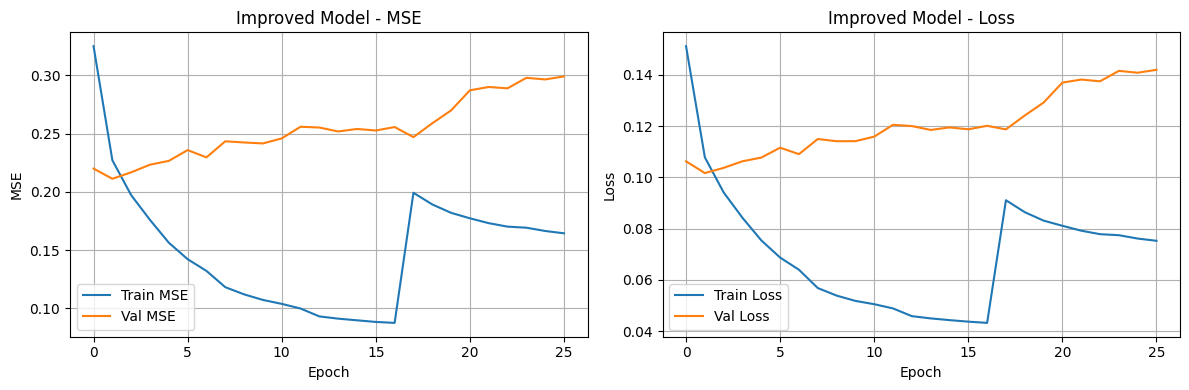


RESULTS
R² for first hour: 0.8557
Training time: 2358.00 seconds

Overall Metrics (scaled):
        MAE     RMSE        R2
0  0.375545  0.49693  0.725277

Overall Metrics (denormalized):
         MAE        RMSE        R2
0  83.445295  110.416615  0.725277

############################################################
Processing city: Ottawa
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Ottawa
Data shape: (78887, 11)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Ottawa_lag1', 'Ottawa_lag2', 'Ottawa_lag3', 'Ottawa_lag4', 'Ottawa_lag5', 'Ottawa_lag6', 'Ottawa_lag7', 'Ottawa_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to feature engin

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 125s 60ms/step - loss: 0.1101 - mse: 0.2342 - val_loss: 0.0594 - val_mse: 0.1220 - learning_rate: 0.0010
Epoch 2/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 136s 57ms/step - loss: 0.0730 - mse: 0.1526 - val_loss: 0.0529 - val_mse: 0.1087 - learning_rate: 0.0010
Epoch 3/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 116s 58ms/step - loss: 0.0633 - mse: 0.1317 - val_loss: 0.0530 - val_mse: 0.1092 - learning_rate: 0.0010
Epoch 4/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 114s 57ms/step - loss: 0.0566 - mse: 0.1177 - val_loss: 0.0506 - val_mse: 0.1037 - learning_rate: 0.0010
Epoch 5/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 142s 57ms/step - loss: 0.0520 - mse: 0.1077 - val_loss: 0.0509 - val_mse: 0.1043 - learning_rate: 0.0010
Epoch 6/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 115s 57ms/step - loss: 0.0481 - mse: 0.0996 - val_loss: 0.0508 - val_mse: 0.1038 - learning_rate: 0.0010
Epoch 7/40
2014/2014 ━━━━━━━━━━━━━━━━━━━━ 114s 56ms/step - loss: 0.0454 - m

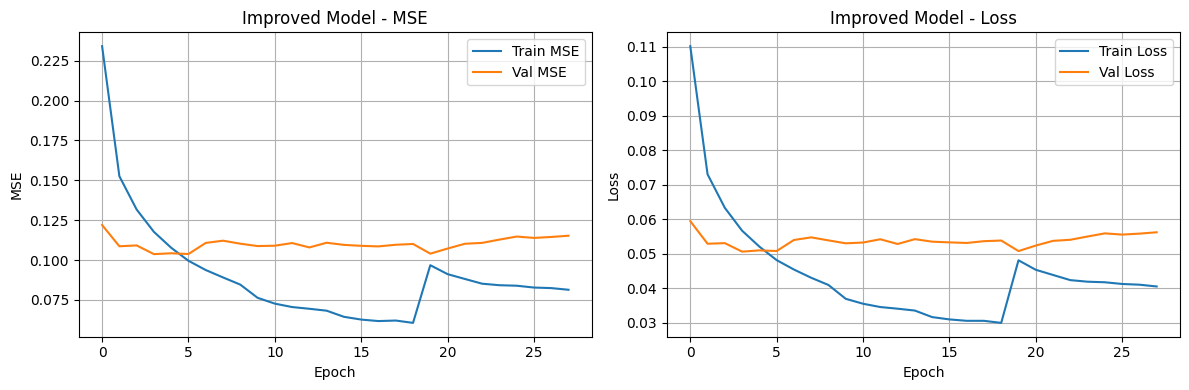


RESULTS
R² for first hour: 0.9388
Training time: 2675.95 seconds

Overall Metrics (scaled):
        MAE      RMSE        R2
0  0.236296  0.322547  0.869728

Overall Metrics (denormalized):
         MAE       RMSE        R2
0  48.997449  66.882033  0.869728

############################################################
Processing city: Toronto
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Toronto
Data shape: (78887, 11)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Toronto_lag1', 'Toronto_lag2', 'Toronto_lag3', 'Toronto_lag4', 'Toronto_lag5', 'Toronto_lag6', 'Toronto_lag7', 'Toronto_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to fea

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 113s 58ms/step - loss: 0.1046 - mse: 0.2547 - val_loss: 0.0431 - val_mse: 0.0877 - learning_rate: 0.0010
Epoch 2/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 111s 59ms/step - loss: 0.0634 - mse: 0.1383 - val_loss: 0.0395 - val_mse: 0.0804 - learning_rate: 0.0010
Epoch 3/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 110s 58ms/step - loss: 0.0544 - mse: 0.1192 - val_loss: 0.0426 - val_mse: 0.0866 - learning_rate: 0.0010
Epoch 4/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 141s 58ms/step - loss: 0.0492 - mse: 0.1084 - val_loss: 0.0398 - val_mse: 0.0810 - learning_rate: 0.0010
Epoch 5/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 110s 58ms/step - loss: 0.0444 - mse: 0.0980 - val_loss: 0.0395 - val_mse: 0.0803 - learning_rate: 0.0010
Epoch 6/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 110s 59ms/step - loss: 0.0415 - mse: 0.0921 - val_loss: 0.0412 - val_mse: 0.0839 - learning_rate: 0.0010
Epoch 7/40
1884/1884 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0394 - mse

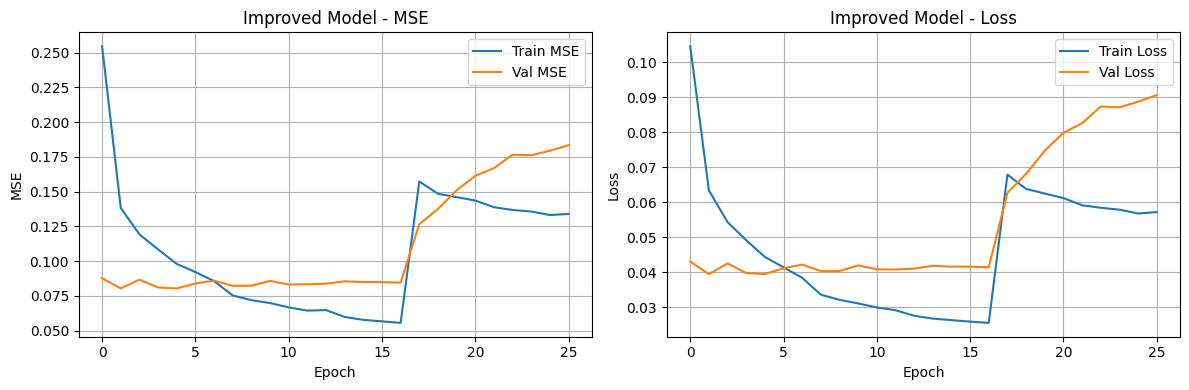


RESULTS
R² for first hour: 0.9327
Training time: 2346.62 seconds

Overall Metrics (scaled):
       MAE      RMSE      R2
0  0.27153  0.355856  0.8544

Overall Metrics (denormalized):
          MAE        RMSE      R2
0  278.267956  364.686155  0.8544

############################################################
Processing city: Essa
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Essa
Data shape: (78887, 11)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Essa_lag1', 'Essa_lag2', 'Essa_lag3', 'Essa_lag4', 'Essa_lag5', 'Essa_lag6', 'Essa_lag7', 'Essa_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to feature engineering)

Train size: 52552

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 127s 62ms/step - loss: 0.1212 - mse: 0.2585 - val_loss: 0.0692 - val_mse: 0.1397 - learning_rate: 0.0010
Epoch 2/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 115s 58ms/step - loss: 0.0789 - mse: 0.1632 - val_loss: 0.0635 - val_mse: 0.1282 - learning_rate: 0.0010
Epoch 3/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 143s 59ms/step - loss: 0.0696 - mse: 0.1439 - val_loss: 0.0659 - val_mse: 0.1332 - learning_rate: 0.0010
Epoch 4/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 116s 59ms/step - loss: 0.0628 - mse: 0.1296 - val_loss: 0.0662 - val_mse: 0.1341 - learning_rate: 0.0010
Epoch 5/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 116s 59ms/step - loss: 0.0576 - mse: 0.1188 - val_loss: 0.0687 - val_mse: 0.1393 - learning_rate: 0.0010
Epoch 6/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 115s 58ms/step - loss: 0.0534 - mse: 0.1102 - val_loss: 0.0697 - val_mse: 0.1417 - learning_rate: 0.0010
Epoch 7/40
1974/1974 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0502 - mse

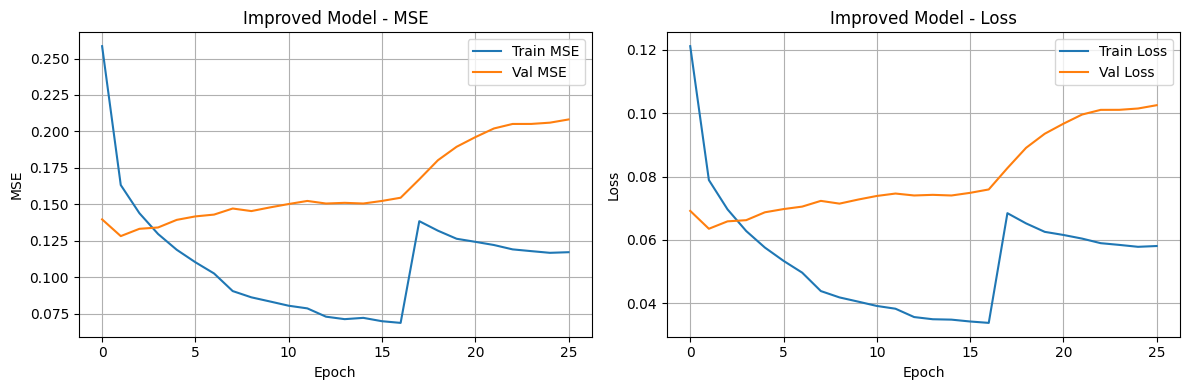


RESULTS
R² for first hour: 0.9110
Training time: 2486.61 seconds

Overall Metrics (scaled):
        MAE      RMSE        R2
0  0.312824  0.408818  0.828837

Overall Metrics (denormalized):
         MAE      RMSE        R2
0  68.666954  89.73821  0.828837

############################################################
Processing city: Southwest
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Southwest
Data shape: (78887, 10)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Southwest_lag1', 'Southwest_lag2', 'Southwest_lag3', 'Southwest_lag4', 'Southwest_lag5', 'Southwest_lag6', 'Southwest_lag7', 'Southwest_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 117s 60ms/step - loss: 0.1081 - mse: 0.2414 - val_loss: 0.0582 - val_mse: 0.1184 - learning_rate: 0.0010
Epoch 2/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 115s 61ms/step - loss: 0.0701 - mse: 0.1536 - val_loss: 0.0545 - val_mse: 0.1114 - learning_rate: 0.0010
Epoch 3/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 114s 60ms/step - loss: 0.0615 - mse: 0.1355 - val_loss: 0.0529 - val_mse: 0.1081 - learning_rate: 0.0010
Epoch 4/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 115s 61ms/step - loss: 0.0555 - mse: 0.1229 - val_loss: 0.0518 - val_mse: 0.1058 - learning_rate: 0.0010
Epoch 5/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 141s 60ms/step - loss: 0.0508 - mse: 0.1127 - val_loss: 0.0531 - val_mse: 0.1084 - learning_rate: 0.0010
Epoch 6/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 144s 61ms/step - loss: 0.0470 - mse: 0.1047 - val_loss: 0.0551 - val_mse: 0.1128 - learning_rate: 0.0010
Epoch 7/40
1898/1898 ━━━━━━━━━━━━━━━━━━━━ 114s 60ms/step - loss: 0.0442 - m

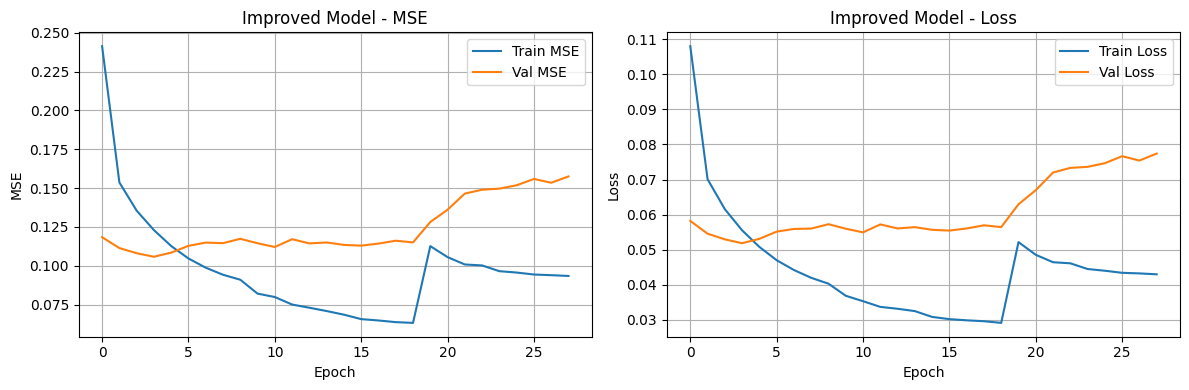


RESULTS
R² for first hour: 0.9282
Training time: 2646.07 seconds

Overall Metrics (scaled):
       MAE      RMSE        R2
0  0.26792  0.357963  0.852439

Overall Metrics (denormalized):
          MAE        RMSE        R2
0  132.322232  176.793249  0.852439

############################################################
Processing city: West
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: West
Data shape: (78887, 10)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['West_lag1', 'West_lag2', 'West_lag3', 'West_lag4', 'West_lag5', 'West_lag6', 'West_lag7', 'West_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to feature engineering)

Train siz

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 122s 60ms/step - loss: 0.1394 - mse: 0.3197 - val_loss: 0.1564 - val_mse: 0.3280 - learning_rate: 0.0010
Epoch 2/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 118s 61ms/step - loss: 0.0945 - mse: 0.2031 - val_loss: 0.1368 - val_mse: 0.2855 - learning_rate: 0.0010
Epoch 3/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 116s 60ms/step - loss: 0.0816 - mse: 0.1753 - val_loss: 0.1385 - val_mse: 0.2886 - learning_rate: 0.0010
Epoch 4/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 126s 65ms/step - loss: 0.0724 - mse: 0.1551 - val_loss: 0.1423 - val_mse: 0.2970 - learning_rate: 0.0010
Epoch 5/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 118s 61ms/step - loss: 0.0653 - mse: 0.1394 - val_loss: 0.1402 - val_mse: 0.2928 - learning_rate: 0.0010
Epoch 6/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 116s 59ms/step - loss: 0.0596 - mse: 0.1281 - val_loss: 0.1482 - val_mse: 0.3109 - learning_rate: 0.0010
Epoch 7/40
1947/1947 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0563 - mse

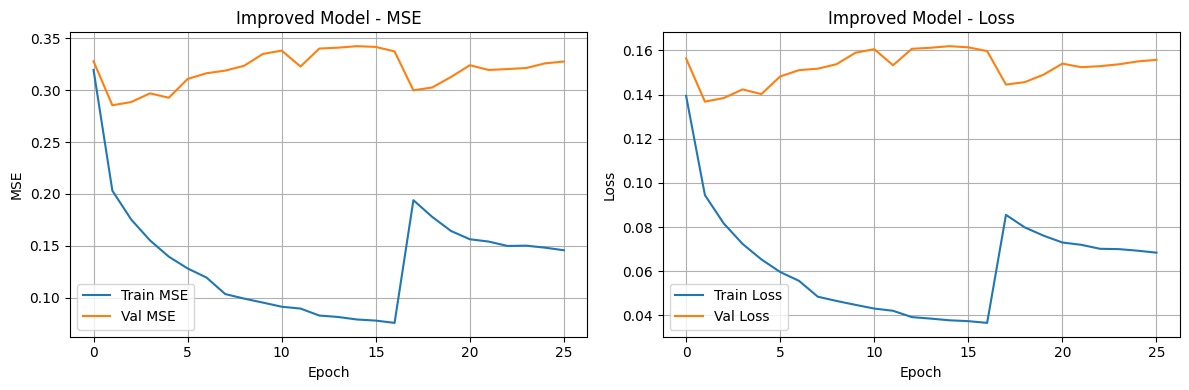


RESULTS
R² for first hour: 0.8091
Training time: 2403.82 seconds

Overall Metrics (scaled):
        MAE      RMSE        R2
0  0.419597  0.547664  0.731746

Overall Metrics (denormalized):
          MAE        RMSE        R2
0  105.946091  138.282502  0.731746

############################################################
Processing city: Northwest
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Northwest
Data shape: (78887, 10)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Northwest_lag1', 'Northwest_lag2', 'Northwest_lag3', 'Northwest_lag4', 'Northwest_lag5', 'Northwest_lag6', 'Northwest_lag7', 'Northwest_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 5

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 129s 66ms/step - loss: 0.1416 - mse: 0.3060 - val_loss: 0.1075 - val_mse: 0.2179 - learning_rate: 0.0010
Epoch 2/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 117s 61ms/step - loss: 0.1100 - mse: 0.2322 - val_loss: 0.1069 - val_mse: 0.2167 - learning_rate: 0.0010
Epoch 3/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 117s 61ms/step - loss: 0.0957 - mse: 0.2019 - val_loss: 0.1141 - val_mse: 0.2313 - learning_rate: 0.0010
Epoch 4/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 117s 61ms/step - loss: 0.0853 - mse: 0.1802 - val_loss: 0.1107 - val_mse: 0.2248 - learning_rate: 0.0010
Epoch 5/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 142s 61ms/step - loss: 0.0766 - mse: 0.1612 - val_loss: 0.1163 - val_mse: 0.2367 - learning_rate: 0.0010
Epoch 6/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 140s 60ms/step - loss: 0.0697 - mse: 0.1471 - val_loss: 0.1162 - val_mse: 0.2366 - learning_rate: 0.0010
Epoch 7/40
1912/1912 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0653 - mse

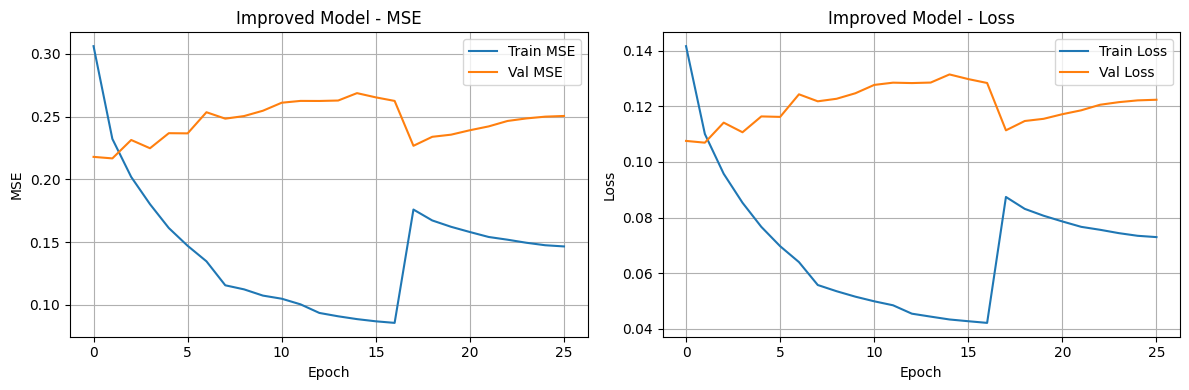


RESULTS
R² for first hour: 0.8530
Training time: 2513.04 seconds

Overall Metrics (scaled):
        MAE      RMSE        R2
0  0.369082  0.476138  0.754641

Overall Metrics (denormalized):
         MAE       RMSE        R2
0  28.703476  37.029199  0.754641

############################################################
Processing city: Northeast
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Northeast
Data shape: (78887, 10)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Northeast_lag1', 'Northeast_lag2', 'Northeast_lag3', 'Northeast_lag4', 'Northeast_lag5', 'Northeast_lag6', 'Northeast_lag7', 'Northeast_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 118s 63ms/step - loss: 0.1049 - mse: 0.2444 - val_loss: 0.0687 - val_mse: 0.1381 - learning_rate: 0.0010
Epoch 2/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 123s 68ms/step - loss: 0.0764 - mse: 0.1779 - val_loss: 0.0642 - val_mse: 0.1288 - learning_rate: 0.0010
Epoch 3/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 117s 65ms/step - loss: 0.0691 - mse: 0.1613 - val_loss: 0.0639 - val_mse: 0.1282 - learning_rate: 0.0010
Epoch 4/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 118s 65ms/step - loss: 0.0641 - mse: 0.1507 - val_loss: 0.0650 - val_mse: 0.1304 - learning_rate: 0.0010
Epoch 5/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 114s 63ms/step - loss: 0.0586 - mse: 0.1377 - val_loss: 0.0675 - val_mse: 0.1355 - learning_rate: 0.0010
Epoch 6/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 121s 67ms/step - loss: 0.0541 - mse: 0.1281 - val_loss: 0.0668 - val_mse: 0.1342 - learning_rate: 0.0010
Epoch 7/40
1804/1804 ━━━━━━━━━━━━━━━━━━━━ 115s 64ms/step - loss: 0.0510 - m

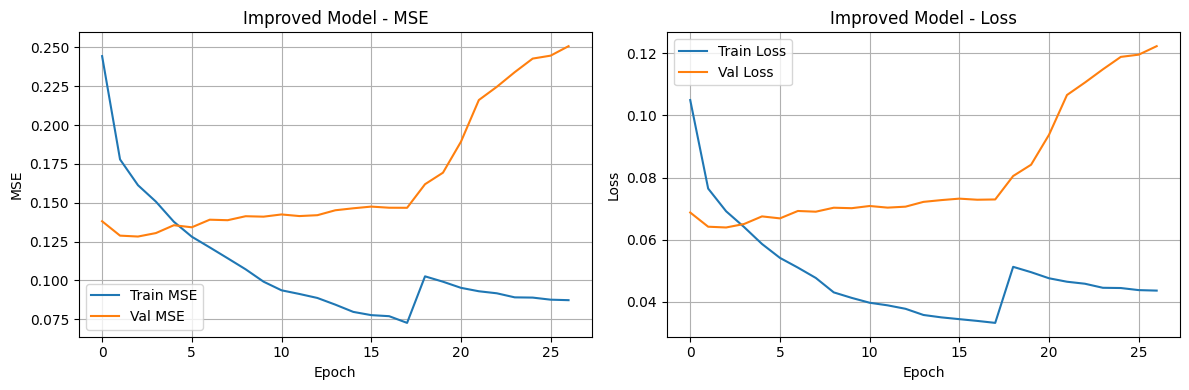


RESULTS
R² for first hour: 0.8870
Training time: 2616.55 seconds

Overall Metrics (scaled):
        MAE      RMSE        R2
0  0.315141  0.402375  0.819239

Overall Metrics (denormalized):
         MAE       RMSE        R2
0  49.236081  62.865001  0.819239

############################################################
Processing city: Niagara
############################################################
Improved Multistep Ahead Forecasting
Input features: ['temp', 'solarradiation', 'humidity', 'precip', 'windspeed', 'cloudcover', 'hour', 'dayofw']
Target column: Niagara
Data shape: (78887, 11)
Use historical target lags: True
Model type: LSTM

Creating lagged features from historical target values...
Creating lags: ['Niagara_lag1', 'Niagara_lag2', 'Niagara_lag3', 'Niagara_lag4', 'Niagara_lag5', 'Niagara_lag6', 'Niagara_lag7', 'Niagara_lag8']
Updated input features (including lags): 16 features
Note: First 8 rows removed due to lag creation

Adjusted train_size: 52552 (lost 8 rows to fea

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,368 (505.34 KB)

 Trainable params: 129,368 (505.34 KB)

 Non-trainable params: 0 (0.00 B)


STAGE 1: Training on all data (40 epochs)
Epoch 1/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 130s 65ms/step - loss: 0.1219 - mse: 0.3857 - val_loss: 0.0713 - val_mse: 0.1450 - learning_rate: 0.0010
Epoch 2/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 129s 67ms/step - loss: 0.0821 - mse: 0.2175 - val_loss: 0.0694 - val_mse: 0.1415 - learning_rate: 0.0010
Epoch 3/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 126s 65ms/step - loss: 0.0726 - mse: 0.1975 - val_loss: 0.0723 - val_mse: 0.1480 - learning_rate: 0.0010
Epoch 4/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 133s 69ms/step - loss: 0.0647 - mse: 0.1801 - val_loss: 0.0726 - val_mse: 0.1486 - learning_rate: 0.0010
Epoch 5/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 127s 66ms/step - loss: 0.0581 - mse: 0.1660 - val_loss: 0.0752 - val_mse: 0.1538 - learning_rate: 0.0010
Epoch 6/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 127s 66ms/step - loss: 0.0534 - mse: 0.1561 - val_loss: 0.0731 - val_mse: 0.1495 - learning_rate: 0.0010
Epoch 7/40
1932/1932 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0505 - mse

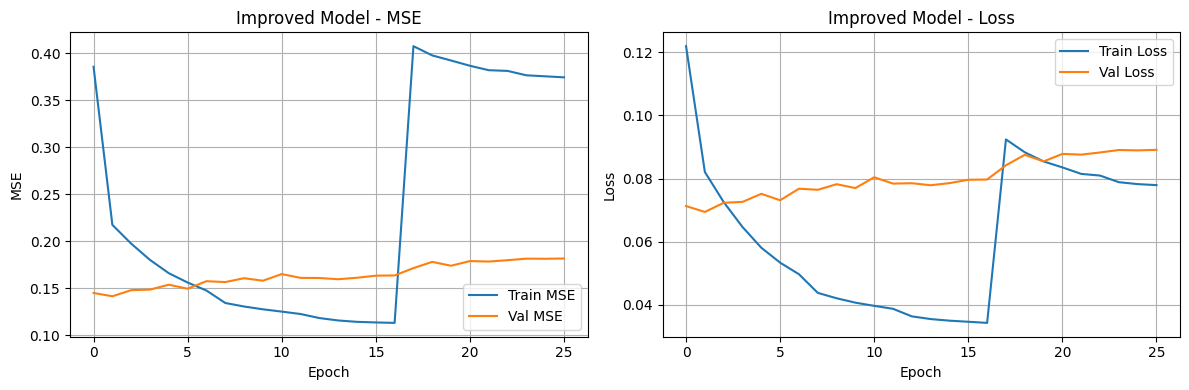


RESULTS
R² for first hour: 0.8720
Training time: 2624.22 seconds

Overall Metrics (scaled):
        MAE      RMSE       R2
0  0.315708  0.414047  0.78994

Overall Metrics (denormalized):
         MAE       RMSE       R2
0  30.109656  39.488463  0.78994


Aggregated Forecast vs Ontario (denormalized metrics):
          MAE        RMSE        R2
0  628.109832  819.998982  0.867408
Aggregated R² for first horizon: 0.9374

First-horizon comparison (Ontario real vs aggregated prediction):
   Ontario_real_t1  Aggregated_pred_t1  difference
0          13677.0        13882.621128 -205.621128
1          13272.0        13371.472845  -99.472845
2          13057.0        13129.373974  -72.373974
3          12864.0        13252.275666 -388.275666
4          12876.0        13770.896975 -894.896975


In [ ]:
# Global defaults (override via kwargs as needed)
TARGET_COLUMN = None
# EPOCHS = 100
N_STEPS_IN = 24
N_STEPS_OUT = 24
TRAIN_SIZE = 52560

USE_NORMALIZATION = True
USE_TARGET_LAGS = True
LAG_WINDOW = 8

USE_LSTM = True
USE_BIDIRECTIONAL = False
USE_GRU = False
DROPOUT_RATE = 0.2
LSTM_UNITS = 128

USE_ADAM = True
LEARNING_RATE = 0.001
USE_LEARNING_RATE_SCHEDULER = True

USE_CYCLICAL_ENCODING = False
USE_ROLLING_STATS = False

if __name__ == "__main__":
    city_dataframes = {
        'East': East,
        'Ottawa': Ottawa,
        'Toronto': Toronto,
        'Essa': Essa,
        'Southwest': Southwest,
        'West': West,
        'Northwest': Northwest,
        'Northeast': Northeast,
        'Niagara': Niagara
    }

    aggregation_kwargs = {
        'use_target_lags': True,
        'use_lstm': True,
        'use_adam': True,
        'epochs': 50
    }

    aggregated_results = forecast_cities_and_aggregate(
        city_dataframes=city_dataframes,
        forecast_kwargs=aggregation_kwargs,
        validate_with_raw_sum=True
    )

    print("\nAggregated Forecast vs Ontario (denormalized metrics):")
    print(aggregated_results['aggregated_metrics'])
    print(f"Aggregated R² for first horizon: {aggregated_results['aggregated_r2_first_hour']:.4f}")

    print("\nFirst-horizon comparison (Ontario real vs aggregated prediction):")
    print(aggregated_results['comparison_first_hour'].head())

In [ ]:
from google.colab import drive

drive.mount('/content/saj')   # run once per session

import os
import joblib

# CHANGE THIS LINE - use /content/drive instead of /content/saj
SAVE_ROOT = "/content/saj/MyDrive/OntarioPredictionModel/twostagetrainandoversampling"
os.makedirs(SAVE_ROOT, exist_ok=True)

for city_name, result in aggregated_results['city_results'].items():
    model_path = os.path.join(SAVE_ROOT, f"{city_name}_model.keras")
    scaler_path = os.path.join(SAVE_ROOT, f"{city_name}_scaler.pkl")

    result['model'].save(model_path)
    if result['scaler'] is not None:
        joblib.dump(
            {
                'scaler': result['scaler'],
                'target_mean': result['target_mean'],
                'target_scale': result['target_scale']
            },
            scaler_path
        )

print(f"Saved models and scalers to {SAVE_ROOT}")

Drive already mounted at /content/saj; to attempt to forcibly remount, call drive.mount("/content/saj", force_remount=True).
Saved models and scalers to /content/saj/MyDrive/OntarioPredictionModel/twostagetrainandoversampling


In [ ]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- paths/config ------------------------------------------------------------
SAVE_ROOT = "/content/saj/MyDrive/OntarioPredictionModel/twostagetrainandoversampling"  # <-- keep in sync with your save location

INFERENCE_CONFIG = {
    'input_features': INPUT_FEATURES.copy(),
    'train_size': TRAIN_SIZE,
    'n_steps_in': N_STEPS_IN,
    'n_steps_out': N_STEPS_OUT,
    'use_normalization': USE_NORMALIZATION,
    'use_target_lags': USE_TARGET_LAGS,
    'lag_window': LAG_WINDOW,
    'use_cyclical_encoding': USE_CYCLICAL_ENCODING,
    'use_rolling_stats': USE_ROLLING_STATS,
    'rolling_window': 3  # only used if USE_ROLLING_STATS = True
}

# --- helpers -----------------------------------------------------------------
def load_city_bundle(city_name, base_path=SAVE_ROOT):
    model_path = os.path.join(base_path, f"{city_name}_model.keras")
    scaler_path = os.path.join(base_path, f"{city_name}_scaler.pkl")
    model = load_model(model_path)
    scaler_bundle = joblib.load(scaler_path)
    return model, scaler_bundle.get('scaler'), scaler_bundle.get('target_mean'), scaler_bundle.get('target_scale')


def _apply_feature_engineering(df, city_name, cfg):
    df_proc = df.copy()
    input_features = cfg['input_features'].copy()
    rows_lost = 0

    if cfg['use_target_lags']:
        for lag in range(1, cfg['lag_window'] + 1):
            df_proc[f'{city_name}_lag{lag}'] = df_proc[city_name].shift(lag)
        df_proc = df_proc.iloc[cfg['lag_window']:]
        input_features += [f'{city_name}_lag{lag}' for lag in range(1, cfg['lag_window'] + 1)]
        rows_lost += cfg['lag_window']

    if cfg['use_cyclical_encoding']:
        if 'hour' in df_proc.columns:
            df_proc['hour_sin'] = np.sin(2 * np.pi * df_proc['hour'] / 24)
            df_proc['hour_cos'] = np.cos(2 * np.pi * df_proc['hour'] / 24)
            if 'hour' in input_features:
                input_features.remove('hour')
            input_features.extend(['hour_sin', 'hour_cos'])
        if 'dayofw' in df_proc.columns:
            df_proc['dayofw_sin'] = np.sin(2 * np.pi * df_proc['dayofw'] / 7)
            df_proc['dayofw_cos'] = np.cos(2 * np.pi * df_proc['dayofw'] / 7)
            if 'dayofw' in input_features:
                input_features.remove('dayofw')
            input_features.extend(['dayofw_sin', 'dayofw_cos'])

    if cfg['use_rolling_stats']:
        numeric_cols = ['temp', 'humidity', 'windspeed', 'solarradiation', 'cloudcover']
        for col in numeric_cols:
            if col in df_proc.columns:
                df_proc[f'{col}_ma{cfg["rolling_window"]}'] = df_proc[col].rolling(cfg['rolling_window']).mean()
                df_proc[f'{col}_std{cfg["rolling_window"]}'] = df_proc[col].rolling(cfg['rolling_window']).std()
                if f'{col}_ma{cfg["rolling_window"]}' not in input_features:
                    input_features.append(f'{col}_ma{cfg["rolling_window"]}')
                if f'{col}_std{cfg["rolling_window"]}' not in input_features:
                    input_features.append(f'{col}_std{cfg["rolling_window"]}')
        df_proc = df_proc.iloc[cfg['rolling_window']:]

        rows_lost += cfg['rolling_window']

    all_features = input_features + [city_name]
    df_proc = df_proc[all_features].apply(pd.to_numeric, errors='coerce').bfill().ffill()

    return df_proc, input_features, rows_lost


def prepare_city_sequences(df_city,
                           city_name,
                           scaler,
                           cfg,
                           train_size_override=None):
    df_proc, input_features, rows_lost = _apply_feature_engineering(df_city, city_name, cfg)
    effective_index = df_proc.index  # preserve datetime index

    train_size_adj = cfg['train_size'] - rows_lost if train_size_override is None else train_size_override
    train_size_adj = max(train_size_adj, 0)
    if train_size_adj >= len(df_proc):
        raise ValueError(f"Not enough rows for {city_name} after feature engineering.")

    if cfg['use_normalization'] and scaler is not None:
        df_scaled = pd.DataFrame(
            scaler.transform(df_proc.values),
            columns=df_proc.columns,
            index=effective_index
        )
    else:
        df_scaled = df_proc

    test_data = df_scaled.iloc[train_size_adj:]
    feature_blocks = [test_data[feature].values.reshape(-1, 1) for feature in input_features]
    target_block = test_data[city_name].values.reshape(-1, 1)
    dataset_test = np.hstack(feature_blocks + [target_block])

    X_test, y_test = split_sequences(dataset_test, cfg['n_steps_in'], cfg['n_steps_out'])

    test_index = effective_index[train_size_adj:]
    timestamps = np.array([
        test_index[i + cfg['n_steps_in']: i + cfg['n_steps_in'] + cfg['n_steps_out']]
        for i in range(len(y_test))
    ])

    return X_test, y_test, timestamps, input_features


def load_saved_forecasts(city_dataframes,
                         base_path=SAVE_ROOT,
                         cfg=INFERENCE_CONFIG):
    per_city = {}
    aggregated_pred = None
    aggregated_real = None
    timestamps_ref = None

    for city_name, df_city in city_dataframes.items():
        model, scaler, target_mean, target_scale = load_city_bundle(city_name, base_path)
        X_test, y_test, timestamps, _ = prepare_city_sequences(df_city, city_name, scaler, cfg)

        preds = model.predict(X_test, verbose=0)
        if cfg['use_normalization'] and scaler is not None:
            preds_denorm = preds * target_scale + target_mean
            y_denorm = y_test * target_scale + target_mean
        else:
            preds_denorm = preds
            y_denorm = y_test

        per_city[city_name] = {
            'predictions': preds_denorm,
            'actuals': y_denorm,
            'timestamps': timestamps,
            'model': model
        }

        if aggregated_pred is None:
            aggregated_pred = preds_denorm.copy()
            aggregated_real = y_denorm.copy()
            timestamps_ref = timestamps
        else:
            if not np.array_equal(timestamps_ref, timestamps):
                raise ValueError(f"Timestamp mismatch for {city_name}; check raw data alignment.")
            aggregated_pred += preds_denorm
            aggregated_real += y_denorm

    ontario = {
        'predictions': aggregated_pred,
        'actuals': aggregated_real,
        'timestamps': timestamps_ref
    }
    return per_city, ontario


def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    idx = city_result['timestamps'][:, h_idx]
    return pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx]
    }, index=idx).sort_index()


def plot_city_profile(per_city_results, city_name, months=None, horizon=1):
    df_plot = _pred_frame(per_city_results[city_name], horizon=horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)]
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Forecast', alpha=0.7)
    plt.title(f'{city_name} – horizon {horizon} forecast vs actual')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot


def plot_ontario_aggregate(ontario_result, months=None, horizon=1):
    df_plot = _pred_frame(ontario_result, horizon=horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)]
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Ontario Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Ontario Forecast (sum cities)', alpha=0.7)
    plt.title(f'Ontario – horizon {horizon} aggregate comparison')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot


def run_saved_model_on_dataframe(city_name,
                                 df_city,
                                 base_path=SAVE_ROOT,
                                 cfg=INFERENCE_CONFIG,
                                 train_size_override=None):
    """
    Re-run the saved model on any slice of data that includes the
    target column and features. Set `train_size_override=0` to treat
    the entire slice as “test” (no split).
    """
    model, scaler, target_mean, target_scale = load_city_bundle(city_name, base_path)
    X, y, timestamps, _ = prepare_city_sequences(
        df_city,
        city_name,
        scaler,
        cfg,
        train_size_override=train_size_override
    )
    preds = model.predict(X, verbose=0)
    if cfg['use_normalization'] and scaler is not None:
        preds_denorm = preds * target_scale + target_mean
        y_denorm = y * target_scale + target_mean
    else:
        preds_denorm = preds
        y_denorm = y

    df_out = []
    for horizon in range(cfg['n_steps_out']):
        df_out.append(pd.DataFrame({
            'timestamp': timestamps[:, horizon],
            'horizon': horizon + 1,
            'actual': y_denorm[:, horizon],
            'forecast': preds_denorm[:, horizon],
            'absolute_error': np.abs(y_denorm[:, horizon] - preds_denorm[:, horizon])
        }))
    return pd.concat(df_out).set_index(['timestamp', 'horizon'])

In [ ]:
def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    idx = city_result['timestamps'][:, h_idx]
    # ensure pandas DatetimeIndex so .month works
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.to_datetime(idx, errors='coerce')
    df = pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx]
    }, index=idx).dropna().sort_index()
    return df

In [ ]:
def predict_city_steps(city_name,
                       df_window,
                       horizons=None,
                       include_actual=True,
                       base_path=SAVE_ROOT,
                       cfg=INFERENCE_CONFIG):
    """
    Use a saved city model on a window of data and optionally compare with real values.

    Parameters
    ----------
    city_name : str
        City key (e.g. 'Toronto'); must match the saved model/scaler naming.
    df_window : pd.DataFrame
        Slice containing at least the required past rows plus the forecast horizon,
        with the city target column and the same feature columns used in training.
    horizons : int or list[int], optional
        Specific horizons (1-based) to return. Default: all horizons.
    include_actual : bool
        If True, expects df_window to already contain the target values for the forecast
        horizon so they can be compared. Set False for “future-only” inference.
    base_path : str
        Directory that holds `{city_name}_model.keras` and `{city_name}_scaler.pkl`.
    cfg : dict
        Should match the training configuration (lags, rolling stats, steps-in/out).

    Returns
    -------
    pd.DataFrame
        Table with forecast, optional actual, absolute error, and timestamp per horizon.
    """
    horizons = (list(np.atleast_1d(horizons))
                if horizons is not None
                else list(range(1, cfg['n_steps_out'] + 1)))

    min_rows = cfg['n_steps_in'] +\
               (cfg['lag_window'] if cfg['use_target_lags'] else 0) +\
               ((cfg['rolling_window'] if cfg['use_rolling_stats'] else 0)) +\
               (cfg['n_steps_out'] if include_actual else 0)

    if len(df_window) < min_rows:
        raise ValueError(
            f"{city_name}: need at least {min_rows} consecutive rows; got {len(df_window)}."
        )

    model, scaler, target_mean, target_scale = load_city_bundle(city_name, base_path)

    X_test, y_test, timestamps, _ = prepare_city_sequences(
        df_window,
        city_name,
        scaler,
        cfg,
        train_size_override=len(df_window) - cfg['n_steps_out'] if include_actual else 0
    )
    if len(X_test) == 0:
        raise ValueError(f"{city_name}: not enough rows after preprocessing; extend df_window.")

    preds = model.predict(X_test, verbose=0)
    if cfg['use_normalization'] and scaler is not None:
        preds = preds * target_scale + target_mean
        y_test = y_test * target_scale + target_mean

    last_pred = preds[-1]
    last_timestamp_seq = timestamps[-1]

    data = []
    for h in horizons:
        if h < 1 or h > cfg['n_steps_out']:
            raise ValueError(f"Horizon {h} out of range (1–{cfg['n_steps_out']}).")
        h_idx = h - 1
        entry = {
            'city': city_name,
            'horizon': h,
            'timestamp': last_timestamp_seq[h_idx],
            'forecast': last_pred[h_idx]
        }
        if include_actual:
            last_actual = y_test[-1][h_idx]
            entry['actual'] = last_actual
            entry['absolute_error'] = abs(last_actual - last_pred[h_idx])
        data.append(entry)

    df_result = pd.DataFrame(data).set_index(['city', 'horizon']).sort_index()
    return df_result

## Load data , top five peaks are based on IESO

In [20]:
# IESO Top 5 Peak Hours Configuration
IESO_TOP5_PEAKS = {
    2021: [
        {'date': '2021-08-24', 'hour_ending': 17, 'rank': 1},
        {'date': '2021-08-26', 'hour_ending': 14, 'rank': 2},
        {'date': '2021-08-23', 'hour_ending': 17, 'rank': 3},
        {'date': '2021-08-09', 'hour_ending': 17, 'rank': 4},
        {'date': '2021-08-25', 'hour_ending': 20, 'rank': 5},
    ],
    2022: [
        {'date': '2022-07-19', 'hour_ending': 17, 'rank': 1},
        {'date': '2022-07-20', 'hour_ending': 15, 'rank': 2},
        {'date': '2022-06-22', 'hour_ending': 17, 'rank': 3},
        {'date': '2022-08-29', 'hour_ending': 17, 'rank': 4},
        {'date': '2022-08-06', 'hour_ending': 18, 'rank': 5},
    ],
    2023: [
        {'date': '2023-09-05', 'hour_ending': 17, 'rank': 1},
        {'date': '2023-09-06', 'hour_ending': 17, 'rank': 2},
        {'date': '2023-07-05', 'hour_ending': 17, 'rank': 3},
        {'date': '2023-07-04', 'hour_ending': 19, 'rank': 4},
        {'date': '2023-07-06', 'hour_ending': 12, 'rank': 5},
    ]
}

Loading saved forecasts and Ontario aggregation
load_city_bundle loads the model, scaler, and target_mean/target_scale per city.
load_saved_forecasts:
Iterates through all cities, prepares test sequences, runs model.predict(X_test) to get multistep forecasts.
Denormalizes predictions and targets using target_mean and target_scale.
Stores per-city results (predictions, actuals, timestamps).
Sums the per-city predictions and actuals to create an Ontario-wide aggregate series (ontario dict).

In [21]:
%pip install tensorflow keras numpy pandas seaborn matplotlib scikit-learn joblib

In [22]:
sns.set(style='whitegrid')

SAVE_ROOT = Path('/content/saj/MyDrive/OntarioPredictionModel/OptimalHyperparametrs')

INPUT_FEATURES = [
    'temp', 'solarradiation', 'humidity', 'precip',
    'windspeed', 'cloudcover', 'hour', 'dayofw'
]
INFERENCE_CFG = {
    'input_features': INPUT_FEATURES.copy(),
    'train_size': 52560,
    'n_steps_in': 24,
    'n_steps_out': 24,
    'use_normalization': True,
    'use_target_lags': True,
    'lag_window': 8,
}

In [23]:
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = [], []
    for i in range(len(sequences)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix:out_end_ix, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

def R_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def load_city_bundle(city_name, base_path=SAVE_ROOT):
    model = load_model(base_path / f'{city_name}_model.keras')
    scaler_bundle = joblib.load(base_path / f'{city_name}_scaler.pkl')
    return (
        model,
        scaler_bundle.get('scaler'),
        scaler_bundle.get('target_mean'),
        scaler_bundle.get('target_scale')
    )

def _apply_feature_engineering(df, city_name, cfg):
    df_proc = df.copy()
    input_features = cfg['input_features'].copy()
    rows_lost = 0

    if cfg['use_target_lags']:
        for lag in range(1, cfg['lag_window'] + 1):
            df_proc[f'{city_name}_lag{lag}'] = df_proc[city_name].shift(lag)
        df_proc = df_proc.iloc[cfg['lag_window']:]
        input_features += [f'{city_name}_lag{lag}' for lag in range(1, cfg['lag_window'] + 1)]
        rows_lost += cfg['lag_window']



    numeric_columns = input_features + [city_name]
    df_proc[numeric_columns] = df_proc[numeric_columns].apply(pd.to_numeric, errors='coerce')
    df_proc = df_proc.bfill().ffill()
    return df_proc, input_features, rows_lost

def prepare_city_sequences(df_city, city_name, scaler, cfg, train_size_override=None):
    df_proc, input_features, rows_lost = _apply_feature_engineering(df_city, city_name, cfg)
    effective_index = df_proc.index

    train_size_adj = cfg['train_size'] - rows_lost if train_size_override is None else train_size_override
    train_size_adj = max(train_size_adj, 0)
    if train_size_adj >= len(df_proc):
        raise ValueError(f"Not enough rows for {city_name} after feature engineering.")

    if cfg['use_normalization'] and scaler is not None:
        df_scaled = pd.DataFrame(
            scaler.transform(df_proc[input_features + [city_name]]),
            columns=input_features + [city_name],
            index=effective_index
        )
    else:
        df_scaled = df_proc[input_features + [city_name]]

    test_data = df_scaled.iloc[train_size_adj:]
    feature_blocks = [test_data[col].values.reshape(-1, 1) for col in input_features]
    target_block = test_data[city_name].values.reshape(-1, 1)
    dataset_test = np.hstack(feature_blocks + [target_block])

    X_test, y_test = split_sequences(dataset_test, cfg['n_steps_in'], cfg['n_steps_out'])

    timestamp_windows = []
    for i in range(len(y_test)):
        idx_slice = test_data.index[i + cfg['n_steps_in']: i + cfg['n_steps_in'] + cfg['n_steps_out']]
        timestamp_windows.append(idx_slice.to_numpy(dtype='datetime64[ns]'))
    timestamps = np.stack(timestamp_windows)

    return X_test, y_test, timestamps, input_features

def load_saved_forecasts(city_dataframes, base_path=SAVE_ROOT, cfg=INFERENCE_CFG):
    per_city = {}
    aggregated_pred = None
    aggregated_real = None
    timestamps_ref = None

    for city_name, df_city in city_dataframes.items():
        model, scaler, target_mean, target_scale = load_city_bundle(city_name, base_path)
        X_test, y_test, timestamps, _ = prepare_city_sequences(df_city, city_name, scaler, cfg)

        preds = model.predict(X_test, verbose=0)

        if cfg['use_normalization'] and scaler is not None:
            preds_denorm = preds * target_scale + target_mean
            y_denorm = y_test * target_scale + target_mean
        else:
            preds_denorm = preds
            y_denorm = y_test

        per_city[city_name] = {
            'predictions': preds_denorm,
            'actuals': y_denorm,
            'timestamps': timestamps,
            'model': model,
            'scaler': scaler,
            'target_mean': target_mean,
            'target_scale': target_scale
        }

        if aggregated_pred is None:
            aggregated_pred = preds_denorm.copy()
            aggregated_real = y_denorm.copy()
            timestamps_ref = timestamps
        else:
            if not np.array_equal(timestamps_ref, timestamps):
                raise ValueError(f"Timestamp mismatch for {city_name}; check input alignment.")
            aggregated_pred += preds_denorm
            aggregated_real += y_denorm

    ontario = {
        'predictions': aggregated_pred,
        'actuals': aggregated_real,
        'timestamps': timestamps_ref
    }
    return per_city, ontario

In [24]:
def load_city_frames():
    drive.mount('/content/saj', force_remount=True)

    folder = Path('/content/saj/MyDrive/DataElecOntario/ISO/Ontario New data /Weather files of Ontario')
    city_map = {
        'Toronto': 'Toronto',
        'Kitchener': 'Kitchener',
        'Niagara': 'Niagara Falls',
        'Ottawa': 'Ottawa',
        'Sudbury': 'Sudbury'
    }

    df_all = {}
    for city, fname in city_map.items():
        df = pd.read_csv(folder / f'{fname}.csv', parse_dates=['datetime'])
        df = df.sort_values('datetime').set_index('datetime')
        df = df.interpolate(method='linear', limit_direction='both')
        df['hour'] = df.index.hour
        df['dayofw'] = df.index.dayofweek
        df['month'] = df.index.month
        df_all[city] = df

    East       = df_all['Ottawa'].drop(columns=['Ottawa']).copy()
    Ottawa     = df_all['Ottawa'].drop(columns=['East']).copy()
    Toronto    = df_all['Toronto'].drop(columns=['Essa']).copy()
    Essa       = df_all['Toronto'].drop(columns=['Toronto']).copy()
    Southwest  = df_all['Kitchener'].drop(columns=['West']).copy()
    West       = df_all['Sudbury'].drop(columns=['Northwest', 'Northeast']).copy()
    Northwest  = df_all['Sudbury'].drop(columns=['Northeast', 'West']).copy()
    Northeast  = df_all['Sudbury'].drop(columns=['Northwest', 'West']).copy()
    Niagara    = df_all['Niagara'].copy()

    return {
        'East': East,
        'Ottawa': Ottawa,
        'Toronto': Toronto,
        'Essa': Essa,
        'Southwest': Southwest,
        'West': West,
        'Northwest': Northwest,
        'Northeast': Northeast,
        'Niagara': Niagara
    }

city_frames = load_city_frames()

Mounted at /content/saj


In [25]:
!pip install joblib
import joblib

In [26]:
start = time.time()
per_city, ontario = load_saved_forecasts(city_frames, base_path=SAVE_ROOT, cfg=INFERENCE_CFG)
print(f'Loaded models and generated forecasts for {len(per_city)} cities in {time.time() - start:.2f}s')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

Loaded models and generated forecasts for 9 cities in 580.45s


In [27]:
def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    timestamps = pd.to_datetime(city_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx],
    }, index=pd.DatetimeIndex(timestamps))
    df = df[~df.index.duplicated(keep='first')].sort_index()
    return df

def plot_city_profile(per_city_results, city_name, months=None, years=None, horizon=1):
    df_plot = _pred_frame(per_city_results[city_name], horizon)

    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)]

    if years is not None:
        years = np.atleast_1d(years)
        df_plot = df_plot[df_plot.index.year.isin(years)]

    df_plot = df_plot.sort_index()

    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Sum of city forecasts', alpha=0.7)
    plt.title(f'{city_name} - horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

def plot_ontario_aggregate(ontario_result, months=None, years=None, horizon=1):
    df_plot = _pred_frame(ontario_result, horizon)

    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)]

    if years is not None:
        years = np.atleast_1d(years)
        df_plot = df_plot[df_plot.index.year.isin(years)]

    df_plot = df_plot.sort_index()

    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Prediction', alpha=0.7)
    plt.title(f'Ontario - horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

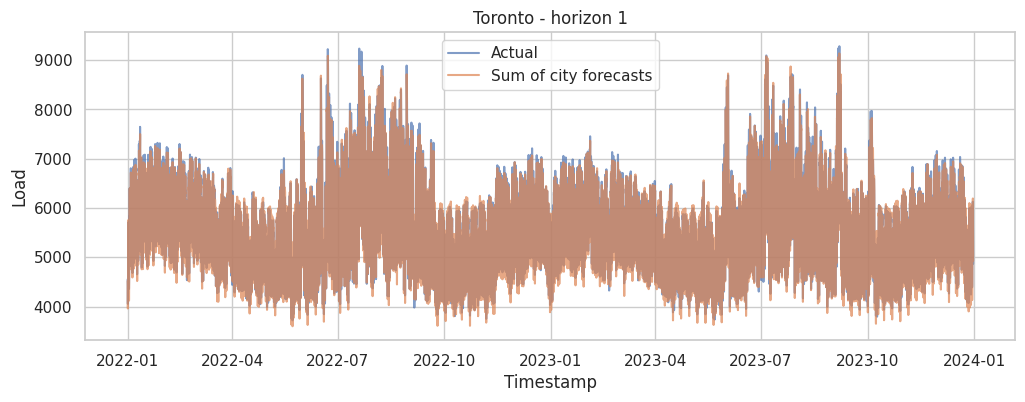

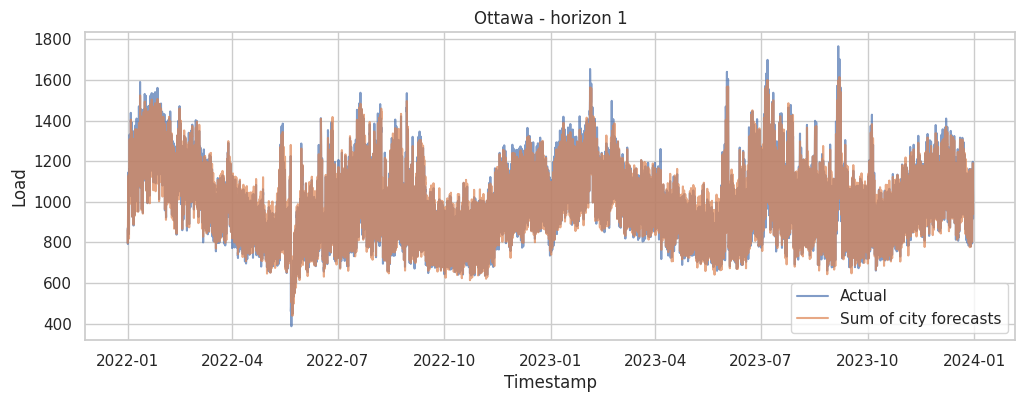

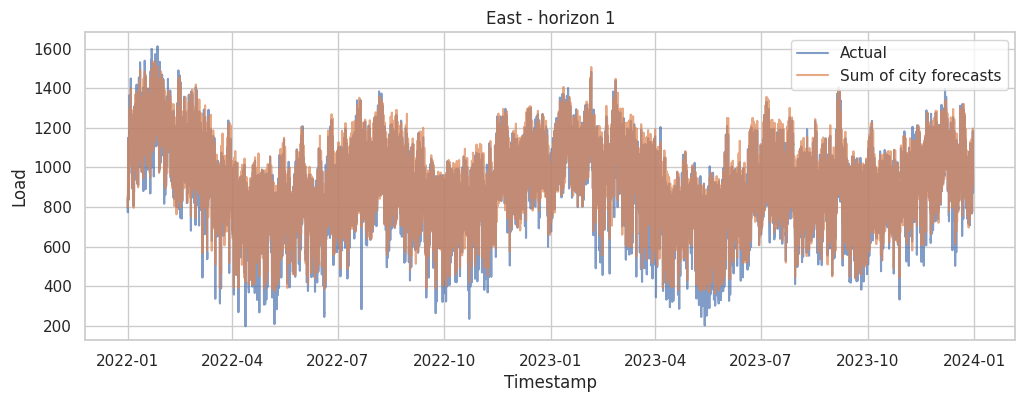

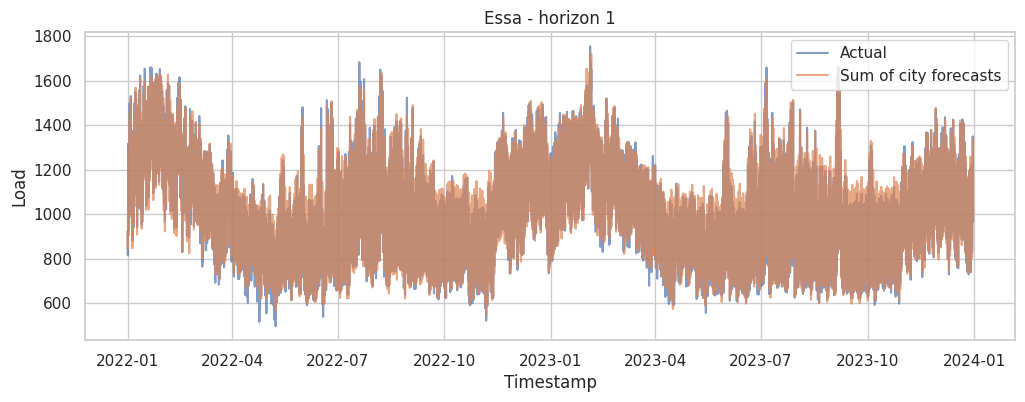

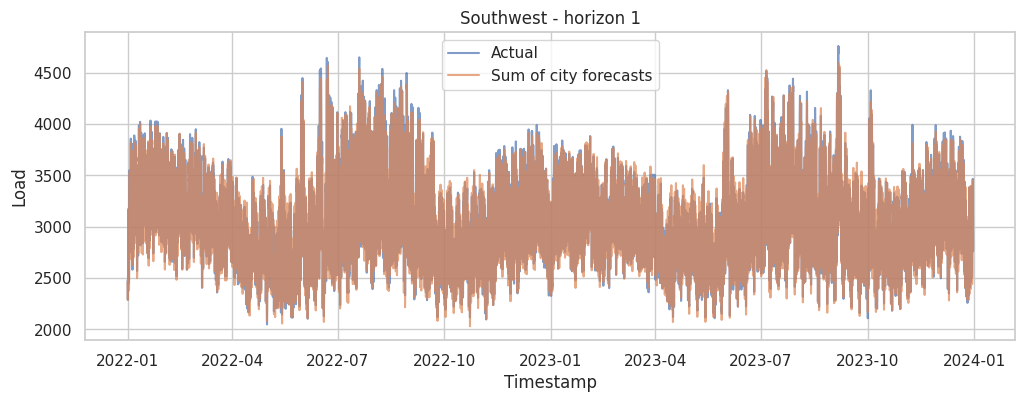

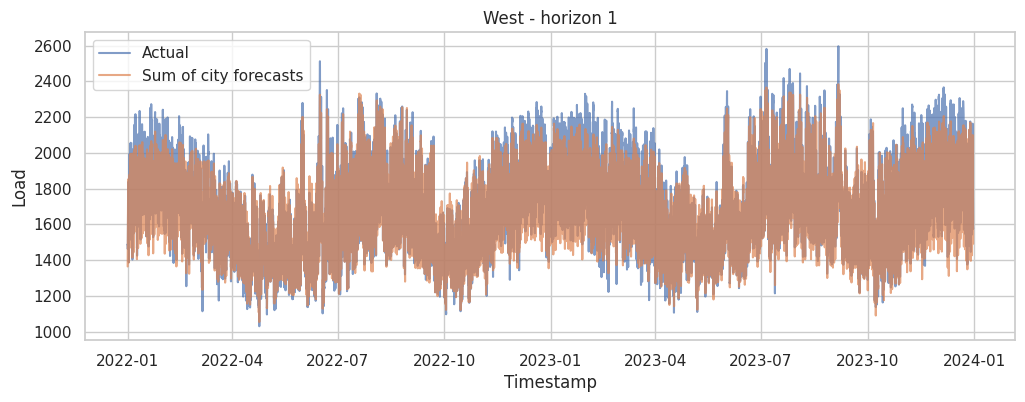

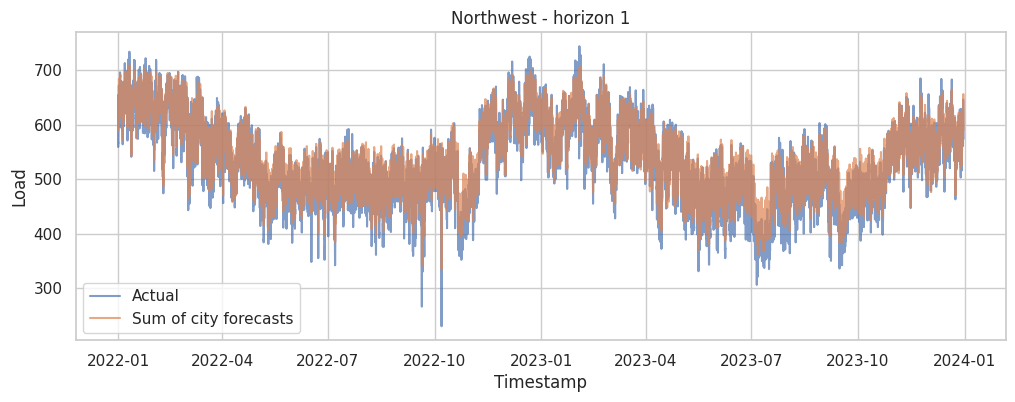

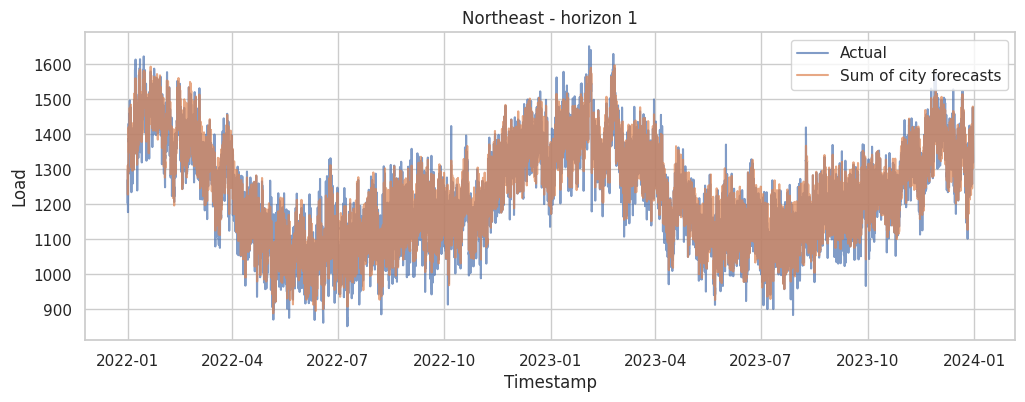

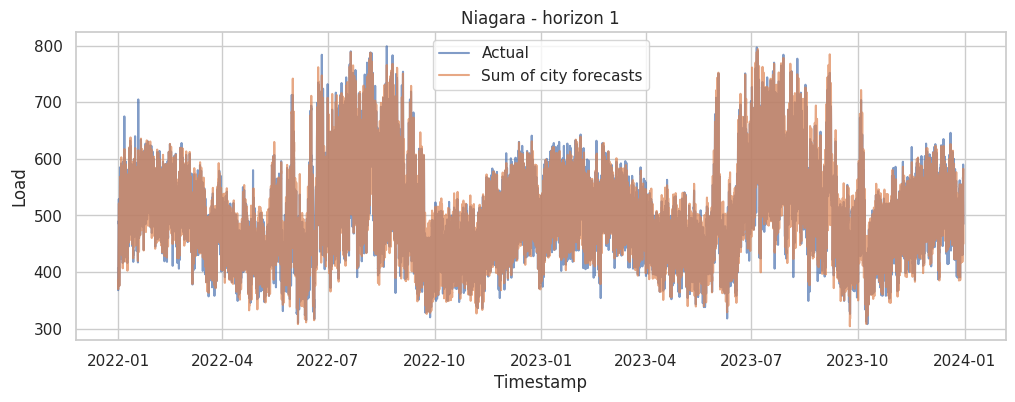

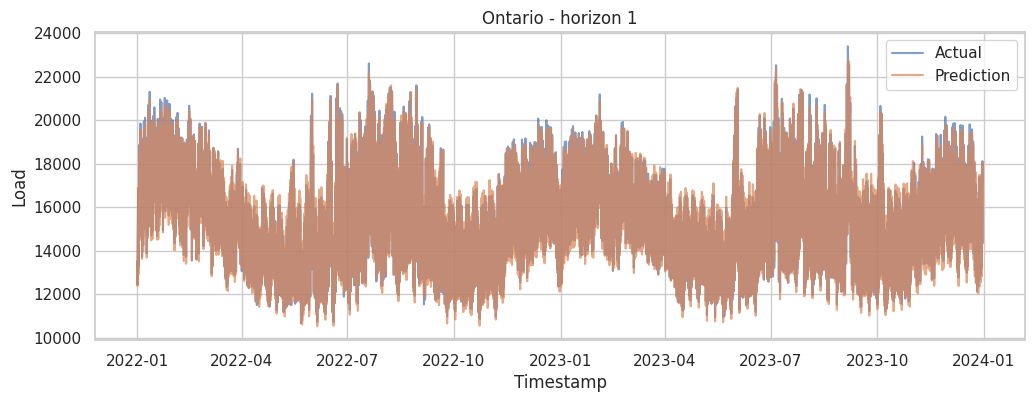

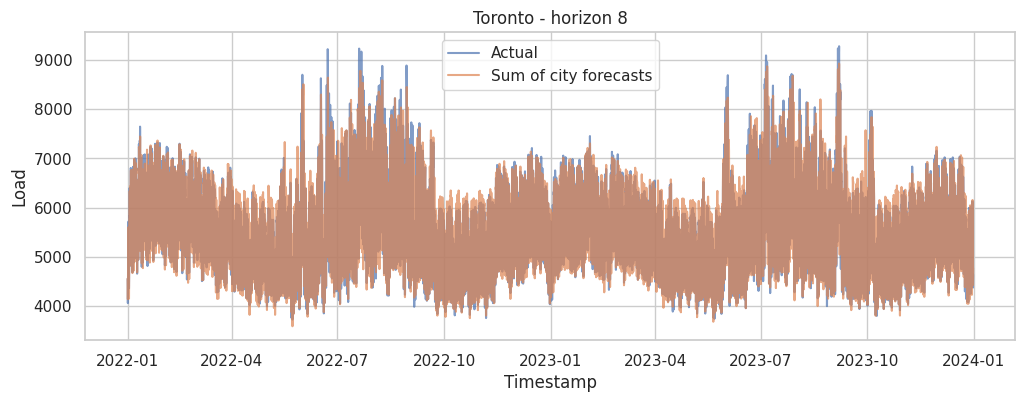

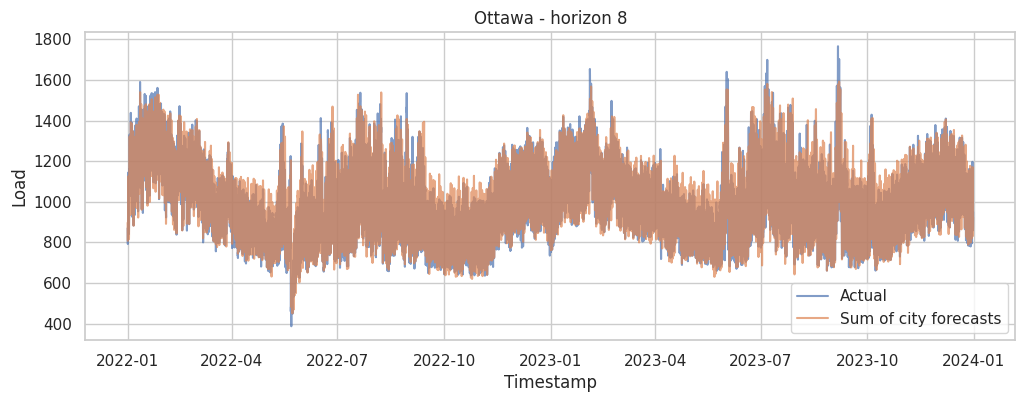

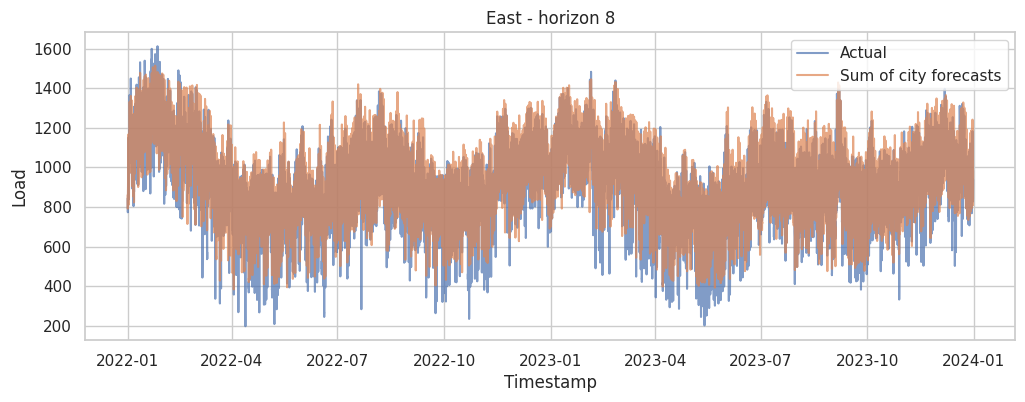

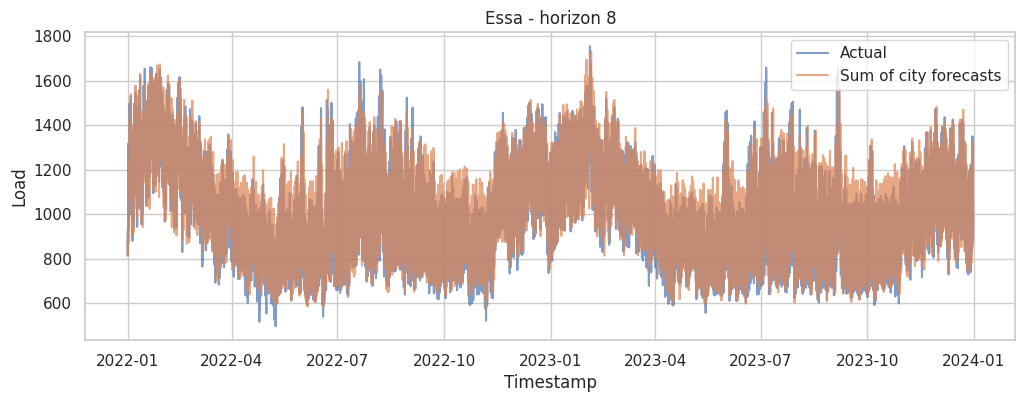

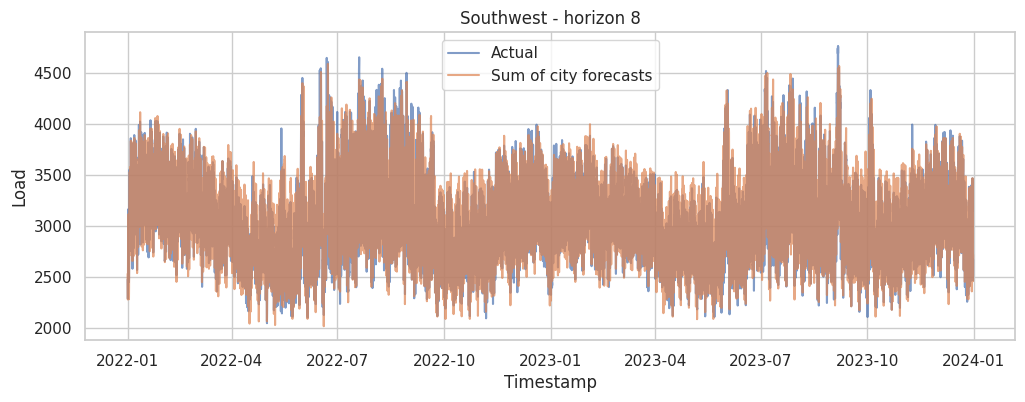

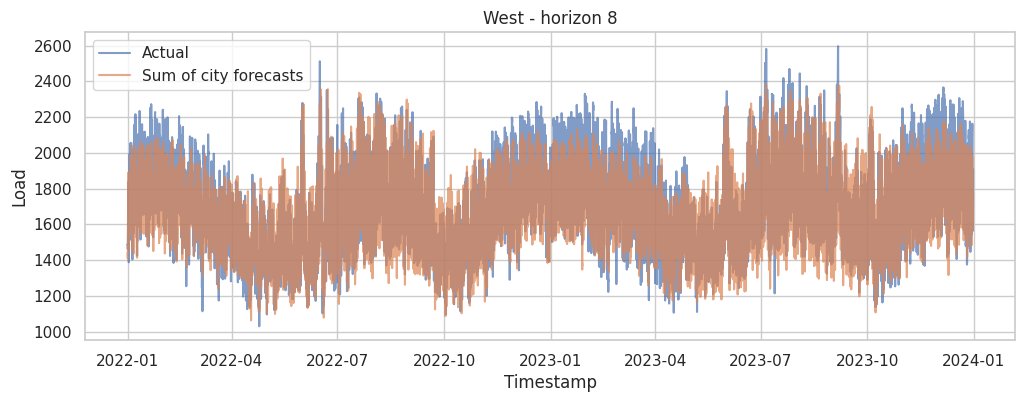

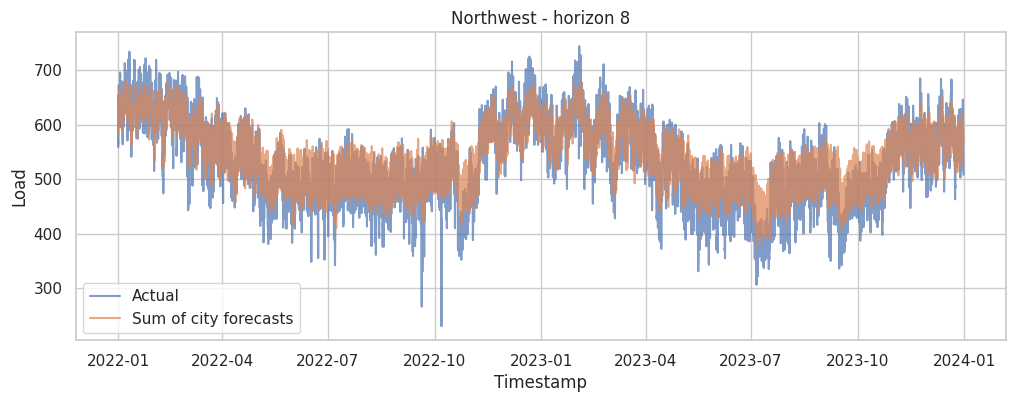

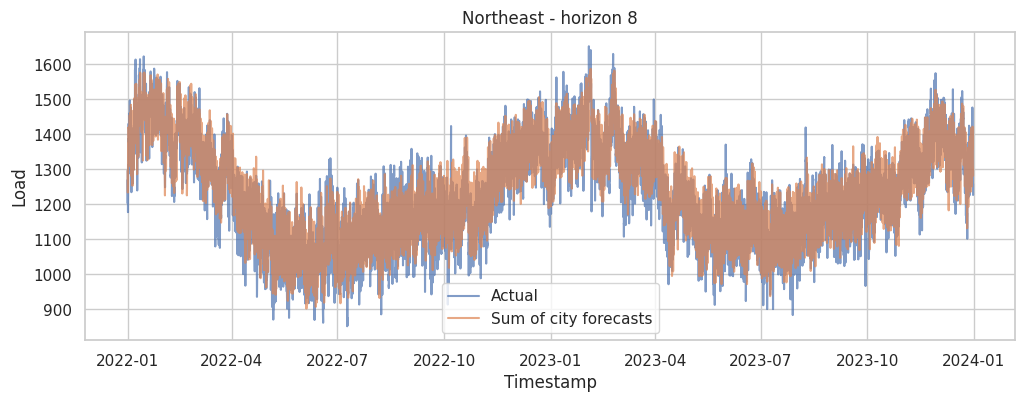

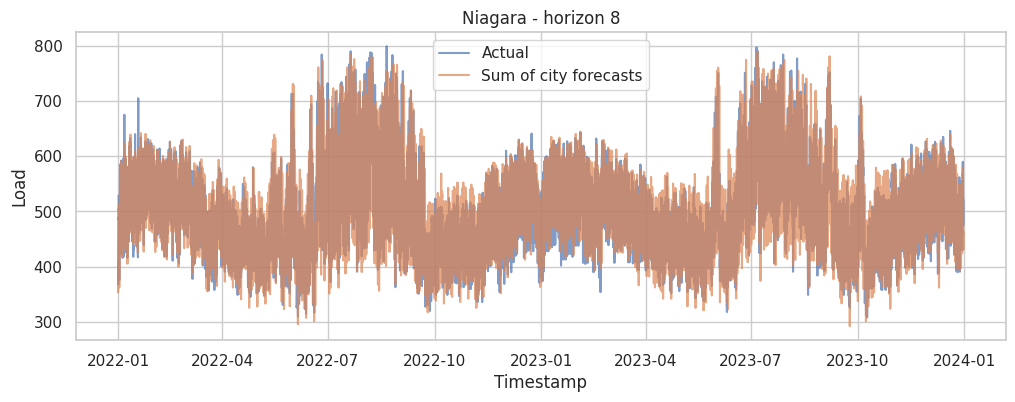

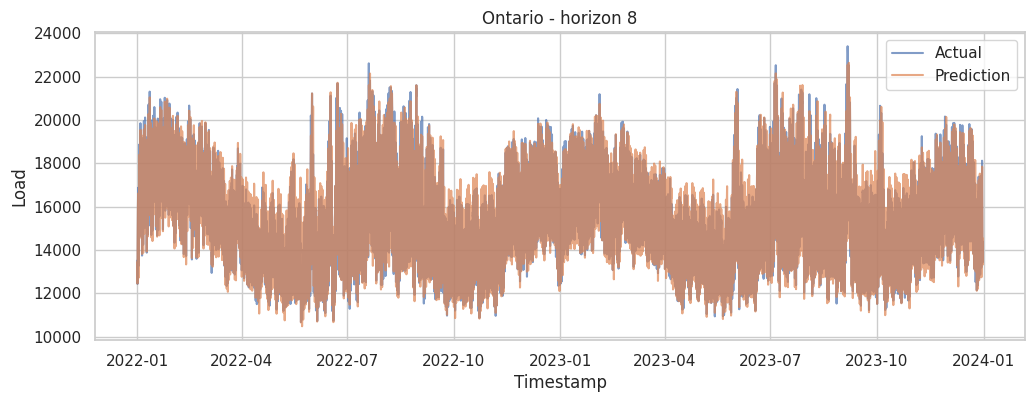

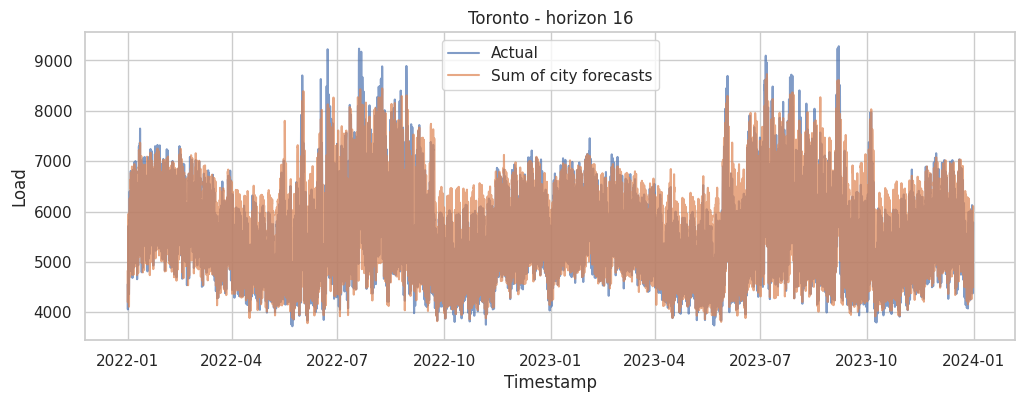

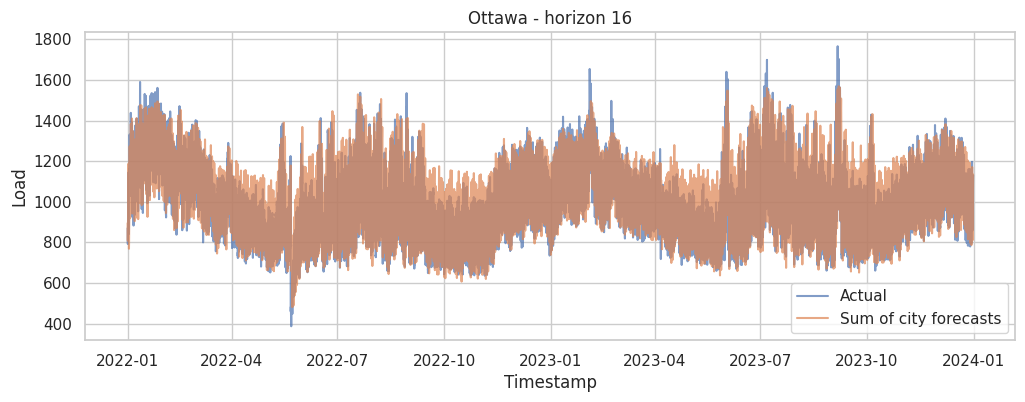

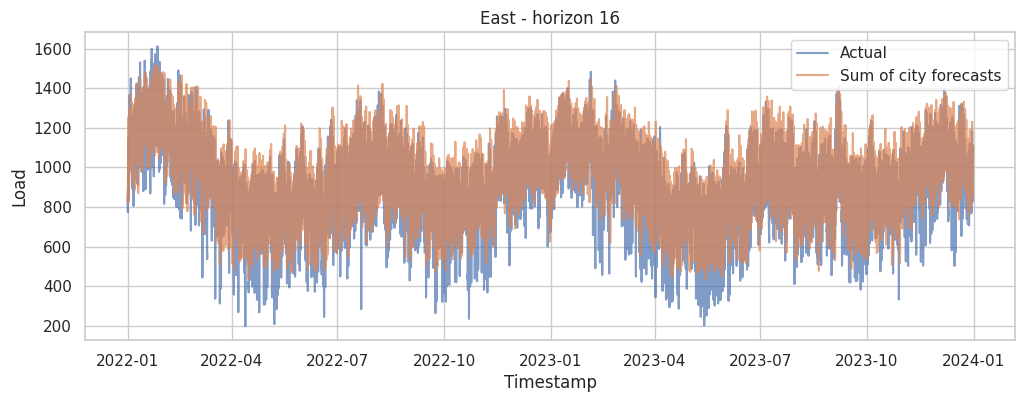

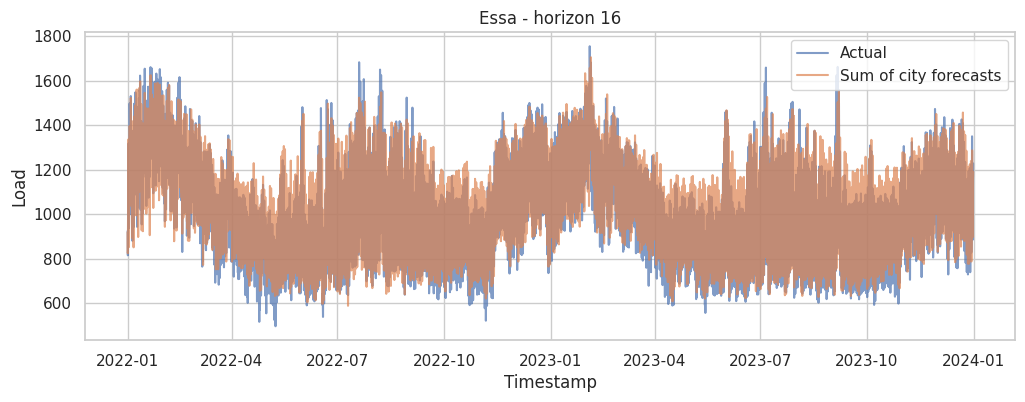

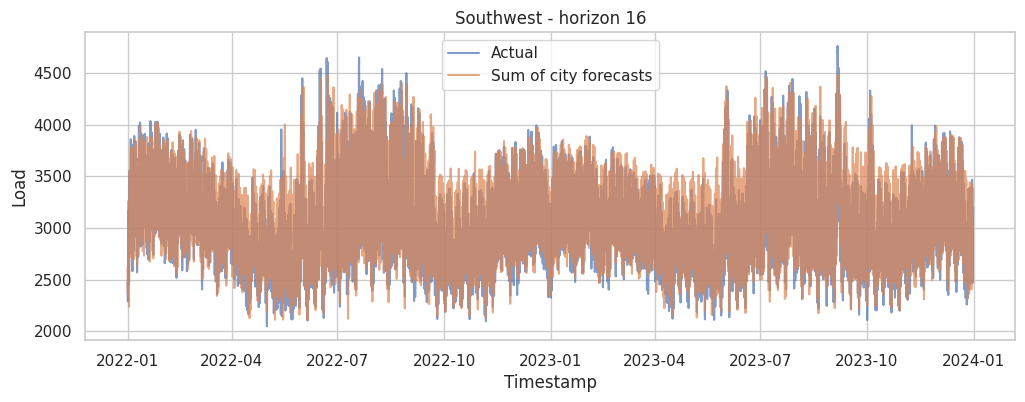

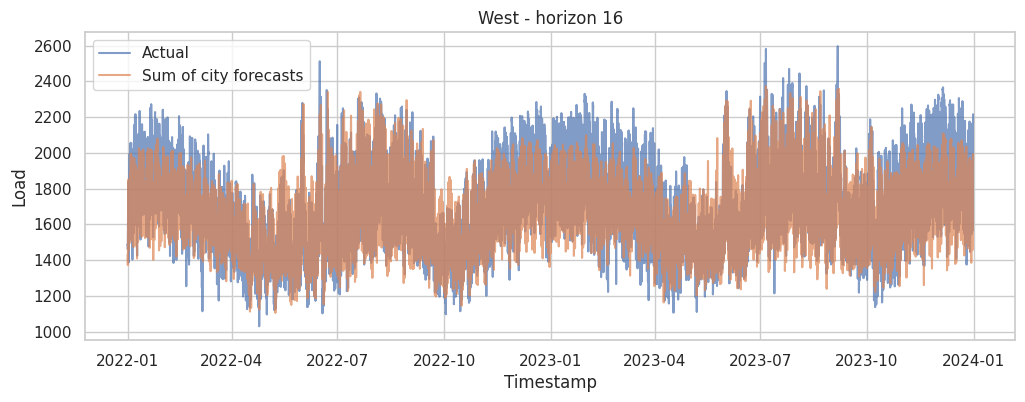

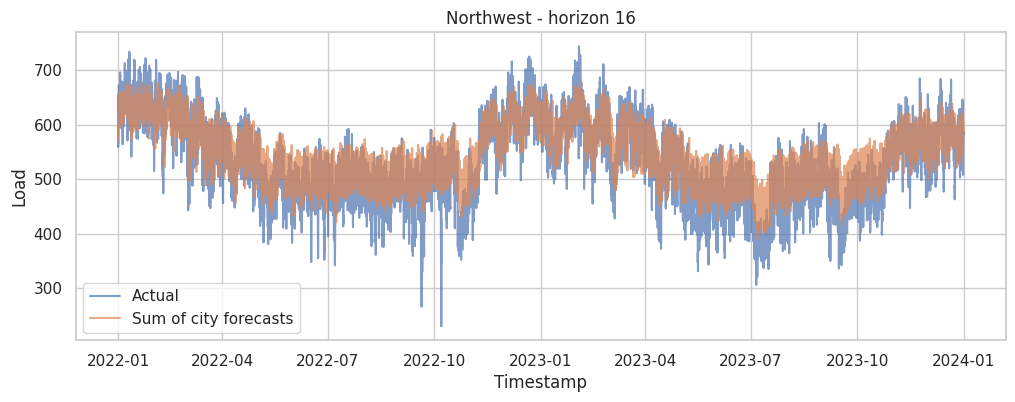

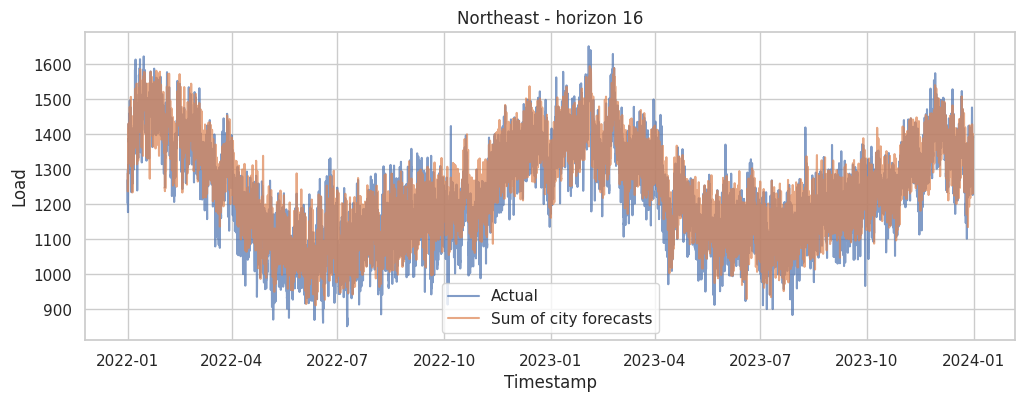

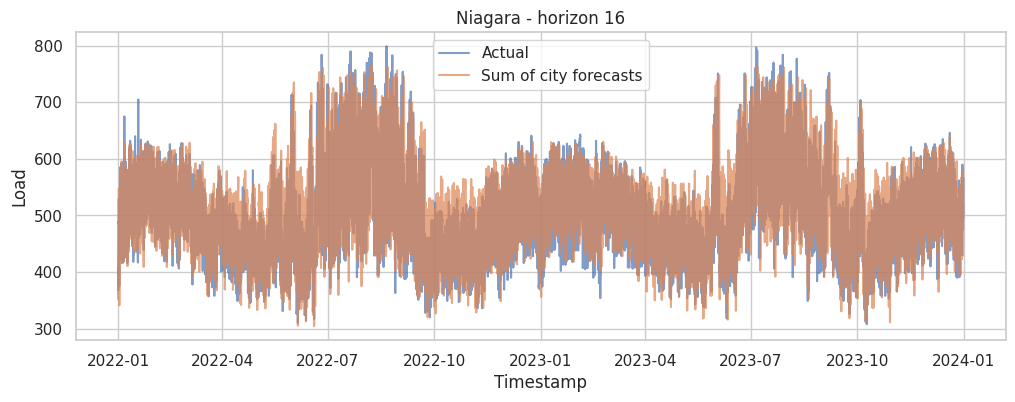

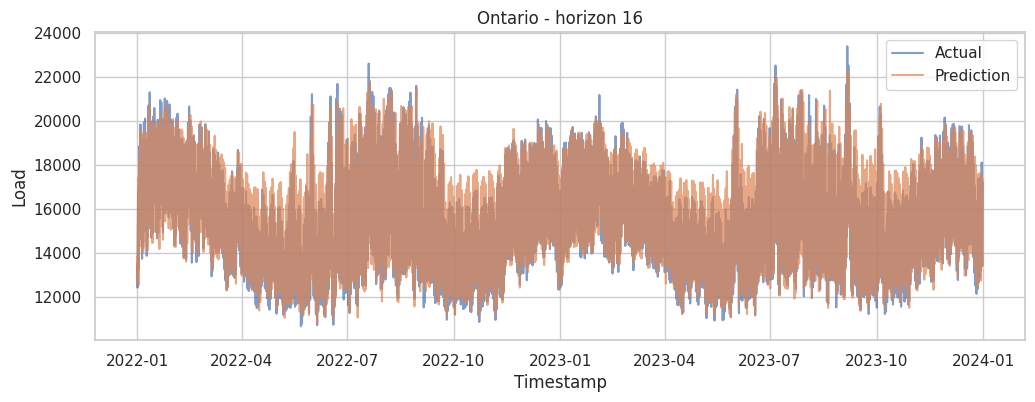

In [28]:
years = [2022, 2023]
cities = ['Toronto', 'Ottawa', 'East', 'Essa', 'Southwest', 'West',
          'Northwest', 'Northeast', 'Niagara']

for h in [1, 8, 16]:
    for city in cities:
        plot_city_profile(per_city, city, years=years, horizon=h)
    plot_ontario_aggregate(ontario, years=years, horizon=h)


=== Confusion Matrix Comparison for All Horizons with Cost/Savings Analysis ===

Processing horizon 1...

Processing horizon 4...

Processing horizon 8...

Processing horizon 12...

Processing horizon 16...

Processing horizon 20...

Processing horizon 24...

Confusion Matrix Results with Cost/Savings (by Year):
 Horizon  Year   TP   TN  FP  FN  Accuracy  Precision   Recall  F1-Score  Total_Savings_($)  Adjusted_Savings_($)
       1  2021 1039 7538 123  62  0.978886   0.894148 0.943688  0.918250         -127282.32            -127282.32
       1  2022  244 8420  28  70  0.988815   0.897059 0.777070  0.832765          176336.96             176336.96
       1  2023  143 8564  14  17  0.996452   0.910828 0.893750  0.902208          258874.24             258874.24
       4  2021  955 7534 188  85  0.968843   0.835521 0.918269  0.874943         -124334.56            -124334.56
       4  2022  212 8414  34 102  0.984478   0.861789 0.675159  0.757143          188128.00             188128.00
 

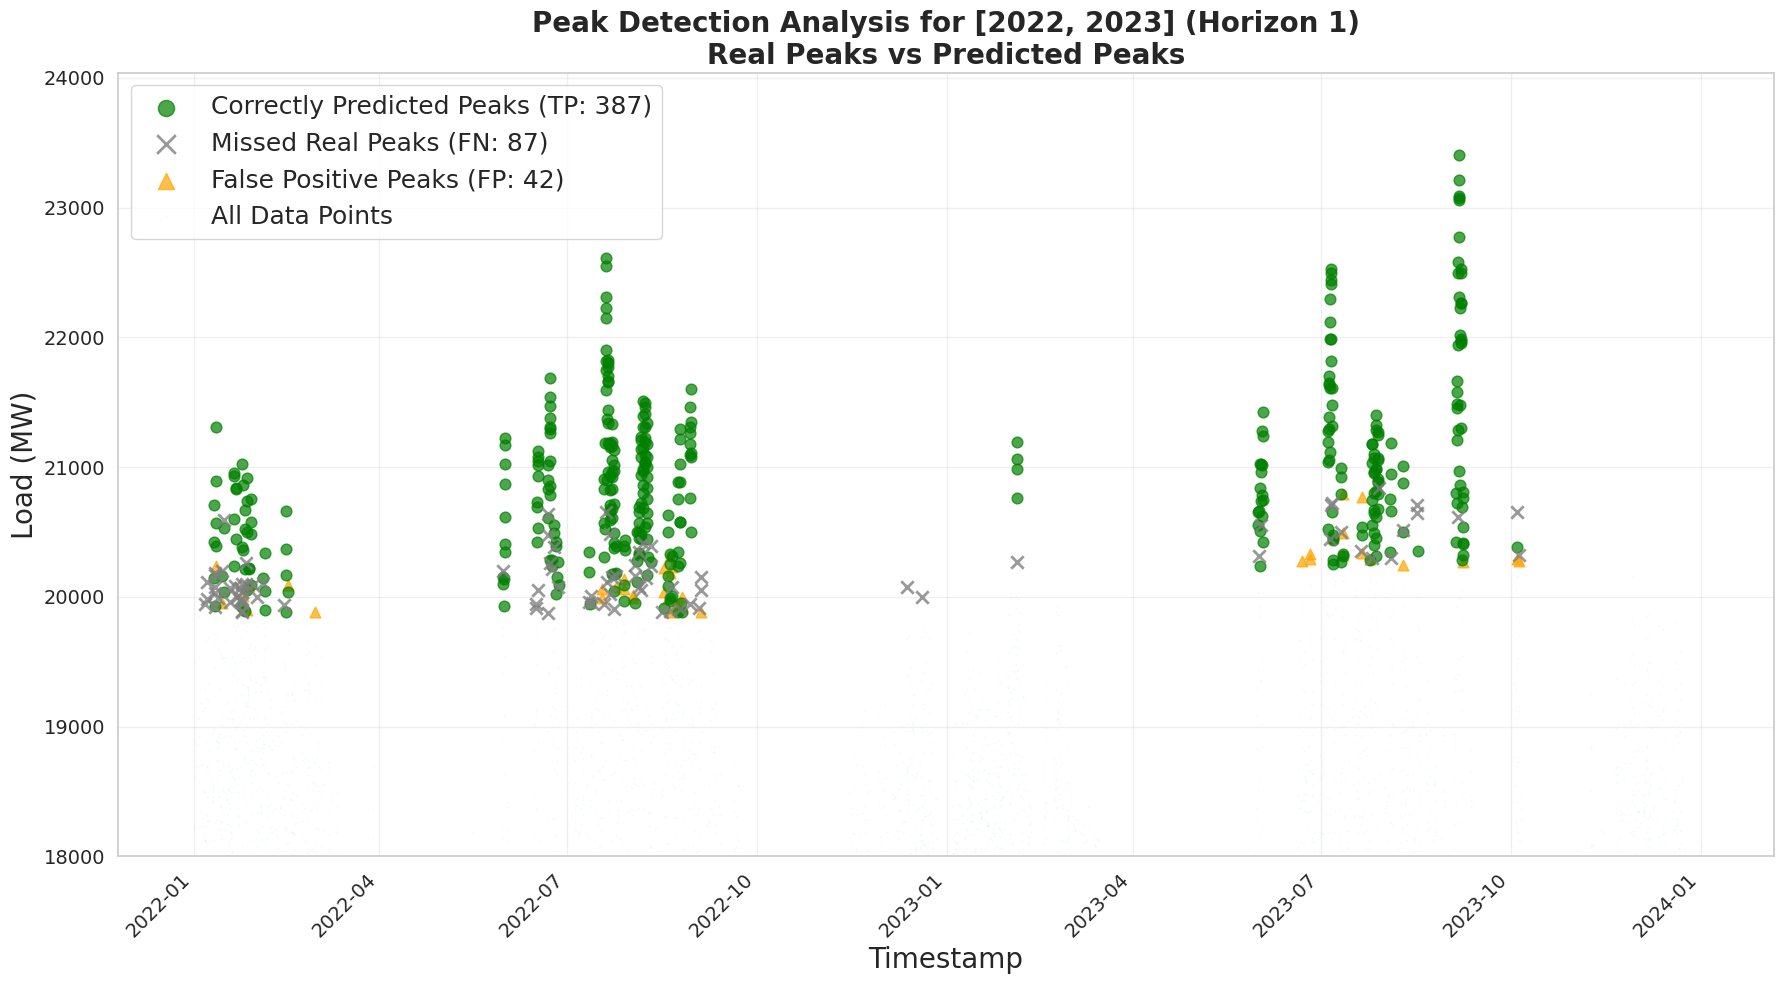


=== Peak Detection Summary for [2022, 2023] (Horizon 1) ===
Total actual peaks: 474
Total predicted peaks: 429
True Positives (correctly predicted): 387
False Negatives (missed real peaks): 87
False Positives (predicted but not actual): 42
Recall (of actual peaks, how many were caught): 0.8165 (81.65%)


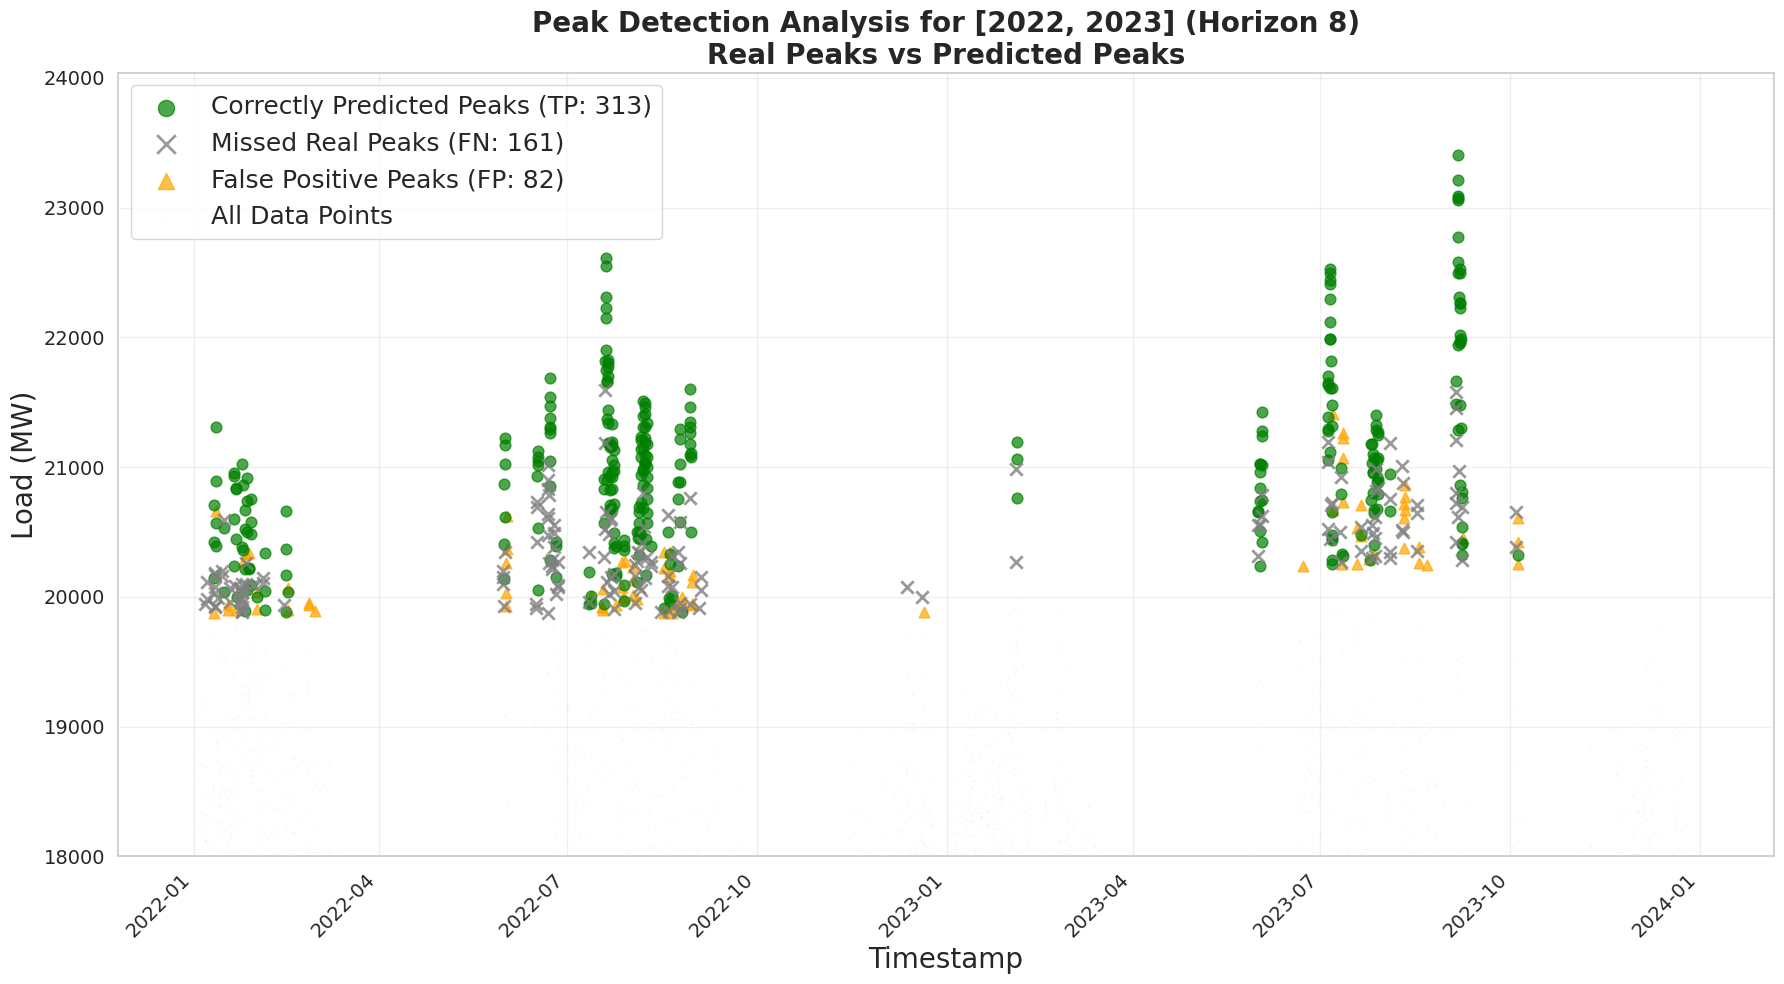


=== Peak Detection Summary for [2022, 2023] (Horizon 8) ===
Total actual peaks: 474
Total predicted peaks: 395
True Positives (correctly predicted): 313
False Negatives (missed real peaks): 161
False Positives (predicted but not actual): 82
Recall (of actual peaks, how many were caught): 0.6603 (66.03%)

=== Filtering: Rows where peak_forecast OR peak_actual == 1 ===
Total rows with peaks: 1740
Percentage of total: 6.62%

Breakdown:
  Rows with peak_actual == 1: 1575
  Rows with peak_forecast == 1: 1591
  Rows with both peaks: 1426
  Rows with only actual peak: 149
  Rows with only forecast peak: 165

✓ Filtered DataFrame saved as 'Ontario_peaks_only'

=== Days with Multiple Peak Hours (2022-2023) ===
Days with multiple peak hours: 235


,date,num_actual_peaks,num_forecast_peaks
3,2021-01-04,4,4
4,2021-01-05,4,6
5,2021-01-06,4,5
6,2021-01-07,4,5
7,2021-01-08,7,5
...,...,...,...
976,2023-09-04,8,8
977,2023-09-05,13,12
978,2023-09-06,12,12
979,2023-09-07,8,9



=== Updated Peak Detection Logic ===

Running updated peak detection...
Z-score threshold: 2.0
Window size: 8 hours

✓ Peak detection complete
Total days analyzed: 1095

=== Classification Summary (Overall) ===
classification
TN    836
TP    226
FN     22
FP     11
Name: count, dtype: int64

=== Performance Metrics (Overall) ===
True Positives (TP):  226
False Positives (FP): 11
False Negatives (FN): 22
True Negatives (TN):  836

Precision:  0.9536 (95.36%)
Recall:     0.9113 (91.13%)
F1-Score:   0.9320
False Positive Rate: 0.0130 (1.30%)

=== Year-by-Year Breakdown ===

YEAR 2020
Total days: 1

Classification counts:
  True Positives (TP):  0
  False Positives (FP): 0
  False Negatives (FN): 0
  True Negatives (TN):  1

Performance metrics:
  Precision:  0.0000 (0.00%)
  Recall:     0.0000 (0.00%)
  F1-Score:   0.0000
  False Positive Rate: 0.0000 (0.00%)

Classification distribution:
  TN:    1 (100.00%)

YEAR 2021
Total days: 365

Classification counts:
  True Positives (TP):  152


,date,has_true_peak,has_predicted_peak,true_peak_timestamp,predicted_window_start
0,2020-12-31,False,False,NaT,NaT



=== YEAR 2021 - Days with True Peaks ===
Total days with true peaks in 2021: 160


...

,date,has_true_peak,has_predicted_peak,true_peak_timestamp,predicted_window_start
731,2023-01-01,False,False,NaT,NaT
732,2023-01-02,False,False,NaT,NaT
733,2023-01-03,False,False,NaT,NaT
734,2023-01-04,False,False,NaT,NaT
735,2023-01-05,False,False,NaT,NaT
736,2023-01-06,False,False,NaT,NaT
737,2023-01-07,False,False,NaT,NaT
738,2023-01-08,False,False,NaT,NaT
739,2023-01-09,False,False,NaT,NaT
740,2023-01-10,False,False,NaT,NaT



=== Overall - Days with True Peaks ===
Total days with true peaks: 248


,date,year,true_peak_timestamp,true_peak_demand,classification
3,2021-01-03,2021,2021-01-03 17:00:00,18042.0,FN
4,2021-01-04,2021,2021-01-04 17:00:00,19048.0,TP
5,2021-01-05,2021,2021-01-05 17:00:00,19137.0,TP
6,2021-01-06,2021,2021-01-06 17:00:00,19131.0,TP
7,2021-01-07,2021,2021-01-07 17:00:00,19144.0,TP
8,2021-01-08,2021,2021-01-08 17:00:00,19177.0,TP
9,2021-01-09,2021,2021-01-09 17:00:00,18068.0,FN
10,2021-01-10,2021,2021-01-10 17:00:00,18376.0,TP
11,2021-01-11,2021,2021-01-11 17:00:00,19135.0,TP
12,2021-01-12,2021,2021-01-12 17:00:00,19311.0,TP



=== Overall - Days with Predicted Peaks ===
Total days with predicted peaks: 237


,date,year,predicted_window_start,predicted_window_end,predicted_window_sum,classification
4,2021-01-04,2021,2021-01-04 13:00:00,2021-01-04 20:00:00,145053.588404,TP
5,2021-01-05,2021,2021-01-05 13:00:00,2021-01-05 20:00:00,146098.204931,TP
6,2021-01-06,2021,2021-01-06 13:00:00,2021-01-06 20:00:00,145197.778508,TP
7,2021-01-07,2021,2021-01-07 14:00:00,2021-01-07 21:00:00,144946.530113,TP
8,2021-01-08,2021,2021-01-08 14:00:00,2021-01-08 21:00:00,145218.994879,TP
10,2021-01-10,2021,2021-01-10 14:00:00,2021-01-10 21:00:00,139054.922091,TP
11,2021-01-11,2021,2021-01-11 13:00:00,2021-01-11 20:00:00,146315.820024,TP
12,2021-01-12,2021,2021-01-12 13:00:00,2021-01-12 20:00:00,147914.335850,TP
13,2021-01-13,2021,2021-01-13 13:00:00,2021-01-13 20:00:00,143811.357139,TP
14,2021-01-14,2021,2021-01-14 13:00:00,2021-01-14 20:00:00,141284.178741,TP


In [29]:
## Ontario Post-Processing with Configurable Horizon

import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Configuration
ZSCORE_THRESHOLD = 2.0  # Z-score threshold for peak detection (can be adjusted)
PEAK_QUANTILE = 0.98  # Alternative: use quantile-based threshold per year
WINDOW_HOURS =8  # Window size for prediction (for detect_peaks_updated)
SAVINGS_SLOPE = -368.47  # Savings formula slope
SAVINGS_INTERCEPT = 335516  # Savings formula intercept
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT / 5  # 335,516 / 5 = $67,103.20

def extract_ontario_horizon(ontario_result, horizon=1):
    """
    Extract Ontario data for a specific forecast horizon.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps' keys
    horizon : int
        Forecast horizon (1-24)

    Returns:
    --------
    pd.DataFrame with columns: timestamp, actual, forecast
    """
    h_idx = horizon - 1
    if h_idx >= ontario_result['timestamps'].shape[1]:
        raise ValueError(f"Horizon {horizon} exceeds maximum forecast steps ({ontario_result['timestamps'].shape[1]})")

    timestamps = pd.to_datetime(ontario_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual': ontario_result['actuals'][:, h_idx],
        'forecast': ontario_result['predictions'][:, h_idx],
    })
    df = df[~df.index.duplicated(keep='first')].sort_values('timestamp').reset_index(drop=True)
    df.set_index('timestamp', inplace=True)
    return df

def aggregate_ontario_features(city_frames):
    """
    Aggregate weather features across all cities to create Ontario-level features.
    Uses mean aggregation for most features.

    Parameters:
    -----------
    city_frames : dict
        Dictionary of city dataframes with weather features

    Returns:
    --------
    pd.DataFrame with aggregated Ontario features
    """
    # List of feature columns to aggregate (excluding city-specific load columns)
    feature_cols = ['temp', 'solarradiation', 'humidity', 'precip',
                    'windspeed', 'cloudcover', 'hour', 'dayofw', 'month']

    # Start with first city's index
    first_city = list(city_frames.keys())[0]
    ontario_features = pd.DataFrame(index=city_frames[first_city].index)

    # Aggregate each feature across all cities
    for col in feature_cols:
        if col in city_frames[first_city].columns:
            # Collect the column from all cities that have it
            city_values = []
            for city_name, df_city in city_frames.items():
                if col in df_city.columns:
                    city_values.append(df_city[col])

            if city_values:
                # Align all series to the same index and take mean
                aligned = pd.concat(city_values, axis=1)
                aligned.columns = range(len(city_values))
                ontario_features[col] = aligned.mean(axis=1)

    return ontario_features

def detect_peaks_zscore(demand_series, threshold=2.0):
    """
    Detect peak hours using Z-score threshold.

    Parameters:
    -----------
    demand_series : pd.Series
        Series of demand values
    threshold : float
        Z-score threshold (default: 2.0)

    Returns:
    --------
    pd.Series with 1 for peaks, 0 for non-peaks
    """
    # Calculate z-scores, handling NaN values
    valid_mask = ~demand_series.isna()
    peak_status = pd.Series(0, index=demand_series.index, dtype=int)

    if valid_mask.sum() > 0:
        z_scores = zscore(demand_series[valid_mask])
        peak_status.loc[valid_mask] = (z_scores >= threshold).astype(int)

    return peak_status

def detect_peaks_quantile_per_year(demand_series, timestamps, quantile=0.98):
    """
    Detect peaks using year-specific quantile thresholds.
    Uses previous year's quantile for current year (except first year).

    Parameters:
    -----------
    demand_series : pd.Series
        Series of demand values
    timestamps : pd.DatetimeIndex
        Timestamps corresponding to demand_series
    quantile : float
        Quantile threshold (default: 0.98)

    Returns:
    --------
    pd.Series with 1 for peaks, 0 for non-peaks
    """
    df_temp = pd.DataFrame({
        'demand': demand_series.values,
        'year': pd.to_datetime(timestamps).year
    }, index=timestamps)

    peak_status = pd.Series(0, index=timestamps)
    years = sorted(df_temp['year'].unique())

    for i, year in enumerate(years):
        year_mask = df_temp['year'] == year

        if i == 0:
            # For first year, use its own quantile
            year_data = df_temp.loc[year_mask, 'demand']
            threshold = zscore(year_data).quantile(quantile)
        else:
            # For subsequent years, use previous year's quantile
            prev_year = years[i-1]
            prev_year_data = df_temp[df_temp['year'] == prev_year]['demand']
            threshold = zscore(prev_year_data).quantile(quantile)

        # Apply threshold to current year
        year_z_scores = zscore(df_temp.loc[year_mask, 'demand'])
        peak_status.loc[year_mask] = (year_z_scores >= threshold).astype(int)

    return peak_status

def prev_year_baseline_stats(actual_series, years):
    baseline = {}
    for y in years:
        prev = y - 1
        prev_data = actual_series[actual_series.index.year == prev].dropna()
        if len(prev_data) == 0:
            baseline[y] = (np.nan, np.nan)
            continue
        mu = float(prev_data.mean())
        sd = float(prev_data.std(ddof=0))
        baseline[y] = (mu, sd if sd > 0 else np.nan)
    return baseline

def zscore_with_baseline(series, baseline_by_year):
    out = pd.Series(index=series.index, dtype=float)
    for y, (mu, sd) in baseline_by_year.items():
        mask = series.index.year == y
        if not np.isfinite(mu) or not np.isfinite(sd):
            out.loc[mask] = np.nan
        else:
            out.loc[mask] = (series.loc[mask] - mu) / (sd + 1e-8)
    return out

def add_walkforward_zscores(df_horizon, years_eval):
    baseline = prev_year_baseline_stats(df_horizon["actual"], years_eval)
    df = df_horizon.copy()
    df["zscore_actual_prevyear"] = zscore_with_baseline(df["actual"], baseline)
    df["zscore_forecast_prevyear"] = zscore_with_baseline(df["forecast"], baseline)
    return df


### new section added
def create_ontario_peak_dataframe(ontario_result, city_frames, horizon=1,
                                  peak_method='zscore_prevyear',
                                  threshold=2.0, quantile=0.98,
                                  years_eval=(2021, 2022, 2023)):
    # 1) Extract horizon-specific actual/forecast
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon).sort_index()

    # 2) Join Ontario-level features (same as before)
    ontario_features = aggregate_ontario_features(city_frames)
    df = df_horizon.join(ontario_features, how='left')

    # 3) Peak labeling
    if peak_method == 'zscore_prevyear':
        df = add_walkforward_zscores(df, years_eval)

        df['peak_actual'] = (df['zscore_actual_prevyear'] >= threshold).astype(int)
        df['peak_forecast'] = (df['zscore_forecast_prevyear'] >= threshold).astype(int)

    elif peak_method == 'quantile':
        # keep your quantile method if you still want it
        df['peak_actual'] = detect_peaks_quantile_per_year(df['actual'], df.index, quantile=quantile)
        df['peak_forecast'] = detect_peaks_quantile_per_year(df['forecast'], df.index, quantile=quantile)

    else:
        raise ValueError("peak_method must be 'zscore_prevyear' or 'quantile'")

    df['year'] = df.index.year

    # keep your column ordering idea (works even if zscore cols exist)
    feature_cols = [c for c in ontario_features.columns if c not in ['actual', 'forecast']]
    z_cols = [c for c in ['zscore_actual_prevyear', 'zscore_forecast_prevyear'] if c in df.columns]
    column_order = ['actual', 'forecast'] + z_cols + feature_cols + ['peak_actual', 'peak_forecast', 'year']
    df = df[[c for c in column_order if c in df.columns]]

    return df


def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=8,
                        z_actual_col='zscore_actual_prevyear',
                        z_forecast_col='zscore_forecast_prevyear'):
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    if z_actual_col not in df.columns or z_forecast_col not in df.columns:
        raise ValueError(
            f"Missing z-score columns. Expected '{z_actual_col}' and '{z_forecast_col}'. "
            "Make sure you created df_ontario via create_ontario_peak_dataframe(..., peak_method='zscore_prevyear')."
        )

    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        above_threshold = day_data[day_data[z_actual_col] >= zscore_threshold]
        if len(above_threshold) > 0:
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            if (window_data[z_forecast_col] >= zscore_threshold).any():
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            classification = 'TP' if (best_window['start'] <= true_peak_idx <= best_window['end']) else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif (not has_true_peak) and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour[z_actual_col]
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year
    return results_df



def calculate_savings(num_peak_hours):
    """
    Calculate savings based on the formula: y = -368.47x + 335516

    Parameters:
    -----------
    num_peak_hours : int or float
        Number of hours that the peak shaving system is activated

    Returns:
    --------
    float
        Total savings (can be negative, indicating a cost)
    """
    if num_peak_hours <= 0:
        return 0.0
    savings = SAVINGS_SLOPE * num_peak_hours + SAVINGS_INTERCEPT
    return savings


def analyze_top_peaks_by_year(df_ontario_peak, year, top_n=5, peaks_updated_df=None):
    """
    Analyze top N peaks in real data for a given year using IESO-specified peak hours.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' column and datetime index
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup

    Returns:
    --------
    pd.DataFrame
        DataFrame with top N peaks and their classification
    """
    # Get IESO-specified top peaks for this year
    if year not in IESO_TOP5_PEAKS:
        # Fallback to old method if year not in IESO data
        df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
        top_peaks = df_year.nlargest(top_n, 'actual')[['actual', 'forecast']].copy()
    else:
        # Use IESO-specified peaks
        top_peaks_list = []
        for peak_info in IESO_TOP5_PEAKS[year][:top_n]:
            peak_date = pd.to_datetime(peak_info['date'])
            hour_ending = peak_info['hour_ending']

            # Hour ending means the hour that ends at that time
            # So hour ending 17 means 16:00-17:00, which is hour 16 in 0-indexed
            # But we need to check what hour index corresponds to hour_ending
            # If data is hourly starting at 00:00, hour_ending 17 means index 16 (16:00-17:00)
            # Let's find the timestamp for that hour
            target_hour = hour_ending - 1  # Convert to 0-indexed hour

            # Filter for that date and hour
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            day_data = df_year[df_year.index.normalize() == peak_date]

            # Find the hour that matches (check both hour_ending-1 and hour_ending)
            # Hour ending 17 could be hour 16 (16:00-17:00) or hour 17 (17:00-18:00)
            # Let's try hour_ending - 1 first (more common convention)
            matching_hours = day_data[day_data.index.hour == target_hour]

            if len(matching_hours) == 0:
                # Try hour_ending directly
                matching_hours = day_data[day_data.index.hour == hour_ending]

            if len(matching_hours) > 0:
                peak_row = matching_hours.iloc[0]
                top_peaks_list.append({
                    'timestamp': peak_row.name,
                    'actual': peak_row['actual'],
                    'forecast': peak_row['forecast'],
                    'rank': peak_info['rank']
                })

        if len(top_peaks_list) == 0:
            # Fallback if no matches found
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            top_peaks = df_year.nlargest(top_n, 'actual')[['actual', 'forecast']].copy()
            top_peaks['timestamp'] = top_peaks.index
            top_peaks['date'] = top_peaks.index.normalize()
        else:
            top_peaks = pd.DataFrame(top_peaks_list)
            top_peaks.set_index('timestamp', inplace=True)
            top_peaks['date'] = top_peaks.index.normalize()
            top_peaks = top_peaks.sort_values('rank')

    # Get daily peak classification from peaks_updated_df
    top_peaks_classification = []

    for idx, row in top_peaks.iterrows():
        date = row['date'] if 'date' in row else idx.normalize()

        # Find the classification for this date
        if peaks_updated_df is not None:
            day_classification = peaks_updated_df[
                peaks_updated_df['date'] == date
            ]

            if len(day_classification) > 0:
                classification = day_classification.iloc[0]['classification']
                has_predicted_peak = day_classification.iloc[0]['has_predicted_peak']

                top_peaks_classification.append({
                    'timestamp': idx,
                    'actual_demand': row['actual'],
                    'forecast_demand': row['forecast'],
                    'date': date,
                    'classification': classification,
                    'has_predicted_peak': has_predicted_peak,
                    'rank': row.get('rank', len(top_peaks_classification) + 1)
                })
            else:
                top_peaks_classification.append({
                    'timestamp': idx,
                    'actual_demand': row['actual'],
                    'forecast_demand': row['forecast'],
                    'date': date,
                    'classification': 'Unknown',
                    'has_predicted_peak': False,
                    'rank': row.get('rank', len(top_peaks_classification) + 1)
                })
        else:
            top_peaks_classification.append({
                'timestamp': idx,
                'actual_demand': row['actual'],
                'forecast_demand': row['forecast'],
                'date': date,
                'classification': 'Unknown',
                'has_predicted_peak': False,
                'rank': row.get('rank', len(top_peaks_classification) + 1)
            })

    top_peaks_df = pd.DataFrame(top_peaks_classification)
    return top_peaks_df




# ============================================================================
# STEP 1: CONFUSION MATRIX FOR ALL HORIZONS + COST/SAVINGS ANALYSIS (BY YEAR)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Confusion Matrix Comparison for All Horizons with Cost/Savings Analysis ===")
print(f"{'='*70}")

horizons_to_test = [1, 4, 8 , 12,16,20, 24]
years_to_analyze = [2021, 2022, 2023]
confusion_results = []

for horizon in horizons_to_test:
    print(f"\nProcessing horizon {horizon}...")

    # Create peak dataframe for this horizon
    df_horizon = create_ontario_peak_dataframe(
        ontario,
        city_frames,
        horizon=horizon,
        peak_method='zscore_prevyear',
        threshold=ZSCORE_THRESHOLD, years_eval=(2021, 2022, 2023)
    )

    # Calculate savings using updated peak detection logic (for overall)
    peaks_updated_horizon = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    # Process each year separately
    for year in years_to_analyze:
        # Filter data for this year
        df_year = df_horizon[df_horizon['year'] == year].copy()

        if len(df_year) == 0:
            continue

        # Calculate confusion matrix for this year
        y_true = df_year['peak_actual']
        y_pred = df_year['peak_forecast']
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
        total = TN + FP + FN + TP

        # Calculate metrics
        accuracy = (TP + TN) / total if total > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Calculate savings for this year using updated peak detection
        peaks_updated_year = peaks_updated_horizon[peaks_updated_horizon['year'] == year]

        TP_days = (peaks_updated_year['classification'] == 'TP').sum()
        FP_days = (peaks_updated_year['classification'] == 'FP').sum()
        total_days_active = TP_days + FP_days
        total_hours_active = total_days_active * WINDOW_HOURS
        total_savings = calculate_savings(total_hours_active)

        # Calculate top-5 penalty for this year
        try:
            top_peaks_df = analyze_top_peaks_by_year(df_year, year, top_n=5, peaks_updated_df=peaks_updated_year)
            fn_in_top5 = (top_peaks_df['classification'] == 'FN').sum()
            penalty = fn_in_top5 * PENALTY_PER_TOP5_MISSED
        except:
            penalty = 0

        adjusted_savings = total_savings - penalty

        confusion_results.append({
            'Horizon': horizon,
            'Year': year,
            'TP': TP,
            'TN': TN,
            'FP': FP,
            'FN': FN,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1_score,
            'Total_Savings_($)': total_savings,
            'Adjusted_Savings_($)': adjusted_savings
        })

# Display results as a table
results_df = pd.DataFrame(confusion_results)
print(f"\nConfusion Matrix Results with Cost/Savings (by Year):")
print(results_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"Summary (by Year):")
print(f"{'='*70}")
for result in confusion_results:
    print(f"Horizon {result['Horizon']:2d} | Year {result['Year']}: TP={result['TP']:5d}, TN={result['TN']:5d}, "
          f"FP={result['FP']:5d}, FN={result['FN']:5d} | "
          f"Acc={result['Accuracy']:.4f}, Prec={result['Precision']:.4f}, "
          f"Rec={result['Recall']:.4f}, F1={result['F1-Score']:.4f} | "
          f"Savings=${result['Total_Savings_($)']:,.2f}, Adj=${result['Adjusted_Savings_($)']:,.2f}")

# Also show overall summary (aggregated across all years)
print(f"\n{'='*70}")
print(f"Overall Summary (Aggregated Across All Years):")
print(f"{'='*70}")

overall_results = []
for horizon in horizons_to_test:
    horizon_data = results_df[results_df['Horizon'] == horizon]

    if len(horizon_data) == 0:
        continue

    # Aggregate metrics across all years
    TP_total = horizon_data['TP'].sum()
    TN_total = horizon_data['TN'].sum()
    FP_total = horizon_data['FP'].sum()
    FN_total = horizon_data['FN'].sum()
    total_all = TP_total + TN_total + FP_total + FN_total

    accuracy_overall = (TP_total + TN_total) / total_all if total_all > 0 else 0
    precision_overall = TP_total / (TP_total + FP_total) if (TP_total + FP_total) > 0 else 0
    recall_overall = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0
    f1_score_overall = 2 * (precision_overall * recall_overall) / (precision_overall + recall_overall) if (precision_overall + recall_overall) > 0 else 0

    # Aggregate savings
    total_savings_overall = horizon_data['Total_Savings_($)'].sum()
    adjusted_savings_overall = horizon_data['Adjusted_Savings_($)'].sum()

    overall_results.append({
        'Horizon': horizon,
        'TP': TP_total,
        'TN': TN_total,
        'FP': FP_total,
        'FN': FN_total,
        'Accuracy': accuracy_overall,
        'Precision': precision_overall,
        'Recall': recall_overall,
        'F1-Score': f1_score_overall,
        'Total_Savings_($)': total_savings_overall,
        'Adjusted_Savings_($)': adjusted_savings_overall
    })

    print(f"Horizon {horizon:2d}: TP={TP_total:5d}, TN={TN_total:5d}, "
          f"FP={FP_total:5d}, FN={FN_total:5d} | "
          f"Acc={accuracy_overall:.4f}, Prec={precision_overall:.4f}, "
          f"Rec={recall_overall:.4f}, F1={f1_score_overall:.4f} | "
          f"Savings=${total_savings_overall:,.2f}, Adj=${adjusted_savings_overall:,.2f}")

overall_df = pd.DataFrame(overall_results)
print(f"\nOverall Summary Table:")
print(overall_df.to_string(index=False))

# ============================================================================
# STEP 2: DETAILED ANALYSIS FOR HORIZONS 1, 8, 16, 24
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Detailed Analysis for Horizons 1, 8, 16, 24 ===")
print(f"{'='*70}")

horizons_detailed = [1, 8, 16, 24]
detailed_dataframes = {}

for horizon in horizons_detailed:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    # Create the Ontario peak DataFrame for this horizon
    df_horizon = create_ontario_peak_dataframe(
        ontario,
        city_frames,
        horizon=horizon,
        peak_method='zscore_prevyear',
        threshold=ZSCORE_THRESHOLD,years_eval=(2021, 2022, 2023)
    )

    detailed_dataframes[horizon] = df_horizon

    print(f"\nCreated Ontario_peak_{horizon} DataFrame")
    print(f"Shape: {df_horizon.shape}")
    print(f"\nColumn names: {list(df_horizon.columns)}")

    # Summary statistics
    print(f"\n=== Peak Statistics (Horizon {horizon}) ===")
    print(f"\nActual Peaks:")
    print(f"  Total peak hours: {df_horizon['peak_actual'].sum()}")
    print(f"  Percentage: {100 * df_horizon['peak_actual'].mean():.2f}%")

    print(f"\nForecast Peaks:")
    print(f"  Total peak hours: {df_horizon['peak_forecast'].sum()}")
    print(f"  Percentage: {100 * df_horizon['peak_forecast'].mean():.2f}%")

    print(f"\nPeak counts per year (Actual):")
    peak_counts_actual = df_horizon.groupby('year')['peak_actual'].sum().reset_index(name='Count')
    print(peak_counts_actual)

    print(f"\nPeak counts per year (Forecast):")
    peak_counts_forecast = df_horizon.groupby('year')['peak_forecast'].sum().reset_index(name='Count')
    print(peak_counts_forecast)

# Store main dataframes for later use
Ontario_peak_1 = detailed_dataframes[1]
Ontario_peak_8 = detailed_dataframes[8]




# ============================================================================
# STEP 3: PEAK DETECTION SCATTER PLOTS
# ============================================================================

def plot_peak_scatter(df_ontario, years=[ 2022, 2023], ylim_min=18000, ylim_max=None, horizon=1):
    """
    Create scatter plot showing real peaks and predicted peaks for specified years.
    Shows missed peaks (false negatives) in grey.

    Parameters:
    -----------
    df_ontario : pd.DataFrame
        Ontario peak DataFrame
    years : list
        List of years to plot
    ylim_min : float
        Lower limit for y-axis
    ylim_max : float, optional
        Upper limit for y-axis
    horizon : int
        Forecast horizon for title
    """
    # Filter for specified years
    df_plot = df_ontario[df_ontario['year'].isin(years)].copy()

    # Classify each point
    tp = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 1)]
    fn = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 0)]
    fp = df_plot[(df_plot['peak_actual'] == 0) & (df_plot['peak_forecast'] == 1)]

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(18, 10))

    # Plot True Positives
    if len(tp) > 0:
        ax.scatter(
            tp.index, tp['actual'],
            color='green', marker='o', s=60, alpha=0.7,
            label=f'Correctly Predicted Peaks (TP: {len(tp)})', zorder=4
        )

    # Plot False Negatives
    if len(fn) > 0:
        ax.scatter(
            fn.index, fn['actual'],
            color='grey', marker='x', s=80, alpha=0.8, linewidths=2,
            label=f'Missed Real Peaks (FN: {len(fn)})', zorder=5
        )

    # Plot False Positives
    if len(fp) > 0:
        ax.scatter(
            fp.index, fp['forecast'],
            color='orange', marker='^', s=60, alpha=0.7,
            label=f'False Positive Peaks (FP: {len(fp)})', zorder=3
        )

    # Plot all actual values as background
    ax.scatter(
        df_plot.index, df_plot['actual'],
        color='lightblue', marker='.', s=1, alpha=0.1, zorder=1,
        label='All Data Points'
    )

    # Set y-axis limits
    if ylim_max is not None:
        ax.set_ylim(ylim_min, ylim_max)
    else:
        ax.set_ylim(bottom=ylim_min)

    # Labels and title
    ax.set_xlabel('Timestamp', fontsize=20)
    ax.set_ylabel('Load (MW)', fontsize=20)
    ax.set_title(
        f'Peak Detection Analysis for {years} (Horizon {horizon})\nReal Peaks vs Predicted Peaks',
        fontsize=20,
        fontweight='bold'
    )

    # Bigger legend text
    ax.legend(loc='upper left', fontsize=18, markerscale=1.5)

    # Grid and ticks
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    # Format x-axis dates
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n=== Peak Detection Summary for {years} (Horizon {horizon}) ===")
    print(f"Total actual peaks: {(df_plot['peak_actual'] == 1).sum()}")
    print(f"Total predicted peaks: {(df_plot['peak_forecast'] == 1).sum()}")
    print(f"True Positives (correctly predicted): {len(tp)}")
    print(f"False Negatives (missed real peaks): {len(fn)}")
    print(f"False Positives (predicted but not actual): {len(fp)}")

    if len(tp) + len(fn) > 0:
        recall = len(tp) / (len(tp) + len(fn))
        print(f"Recall (of actual peaks, how many were caught): {recall:.4f} ({recall*100:.2f}%)")

# Plot scatter visualization for 2022 and 2023
plot_peak_scatter(Ontario_peak_1, years=[ 2022, 2023], ylim_min=18000, horizon=1)
plot_peak_scatter(Ontario_peak_8, years=[ 2022, 2023], ylim_min=18000, horizon=8)

# ============================================================================
# STEP 4: PEAK ROWS FILTERING
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Filtering: Rows where peak_forecast OR peak_actual == 1 ===")
print(f"{'='*70}")

peak_rows = Ontario_peak_1[(Ontario_peak_1['peak_forecast'] == 1) | (Ontario_peak_1['peak_actual'] == 1)]
print(f"Total rows with peaks: {len(peak_rows)}")
print(f"Percentage of total: {100 * len(peak_rows) / len(Ontario_peak_1):.2f}%")

print(f"\nBreakdown:")
print(f"  Rows with peak_actual == 1: {(Ontario_peak_1['peak_actual'] == 1).sum()}")
print(f"  Rows with peak_forecast == 1: {(Ontario_peak_1['peak_forecast'] == 1).sum()}")
print(f"  Rows with both peaks: {((Ontario_peak_1['peak_actual'] == 1) & (Ontario_peak_1['peak_forecast'] == 1)).sum()}")
print(f"  Rows with only actual peak: {((Ontario_peak_1['peak_actual'] == 1) & (Ontario_peak_1['peak_forecast'] == 0)).sum()}")
print(f"  Rows with only forecast peak: {((Ontario_peak_1['peak_actual'] == 0) & (Ontario_peak_1['peak_forecast'] == 1)).sum()}")

# Optional: Save filtered data to a variable for further analysis
Ontario_peaks_only = peak_rows.copy()
print(f"\n✓ Filtered DataFrame saved as 'Ontario_peaks_only'")

# ============================================================================
# STEP 5: MULTIPLE PEAK HOURS ANALYSIS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Days with Multiple Peak Hours (2022-2023) ===")
print(f"{'='*70}")

# Using existing Ontario_peak_1 DataFrame
df_filtered = Ontario_peak_1[Ontario_peak_1['year'].isin([2021, 2022, 2023])].copy()
df_filtered['date'] = df_filtered.index.normalize()

# Count peak hours per day
daily_peak_counts = df_filtered.groupby('date').agg({
    'peak_actual': 'sum',
    'peak_forecast': 'sum'
}).reset_index()
daily_peak_counts.columns = ['date', 'num_actual_peaks', 'num_forecast_peaks']

# Filter days with more than 1 peak hour
days_multiple_peaks = daily_peak_counts[
    (daily_peak_counts['num_actual_peaks'] > 1) |
    (daily_peak_counts['num_forecast_peaks'] > 1)
]

print(f"Days with multiple peak hours: {len(days_multiple_peaks)}")
display(days_multiple_peaks)

# Note: code comment indicates need to fix to allow only 1 peak per day

# ============================================================================
# STEP 6: UPDATED PEAK DETECTION (ONE PEAK PER DAY)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Updated Peak Detection Logic ===")
print(f"{'='*70}")

# Run updated peak detection
print(f"\nRunning updated peak detection...")
print(f"Z-score threshold: {ZSCORE_THRESHOLD}")
print(f"Window size: {WINDOW_HOURS} hours")

Ontario_peaks_updated = detect_peaks_updated(
    Ontario_peak_1,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS
)

print(f"\n✓ Peak detection complete")
print(f"Total days analyzed: {len(Ontario_peaks_updated)}")

# Display classification summary (Overall)
print(f"\n=== Classification Summary (Overall) ===")
classification_counts = Ontario_peaks_updated['classification'].value_counts()
print(classification_counts)

# Calculate overall metrics
TP = (Ontario_peaks_updated['classification'] == 'TP').sum()
FP = (Ontario_peaks_updated['classification'] == 'FP').sum()
FN = (Ontario_peaks_updated['classification'] == 'FN').sum()
TN = (Ontario_peaks_updated['classification'] == 'TN').sum()

total = TP + FP + FN + TN
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"\n=== Performance Metrics (Overall) ===")
print(f"True Positives (TP):  {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN):  {TN}")
print(f"\nPrecision:  {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:     {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:   {f1_score:.4f}")
print(f"False Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")

# Year-by-year breakdown
print(f"\n{'='*70}")
print(f"=== Year-by-Year Breakdown ===")
print(f"{'='*70}")

years_to_analyze = sorted(Ontario_peaks_updated['year'].unique())

for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]

    if len(year_data) == 0:
        print(f"\nNo data for {year}")
        continue

    TP_y = (year_data['classification'] == 'TP').sum()
    FP_y = (year_data['classification'] == 'FP').sum()
    FN_y = (year_data['classification'] == 'FN').sum()
    TN_y = (year_data['classification'] == 'TN').sum()

    total_y = TP_y + FP_y + FN_y + TN_y
    precision_y = TP_y / (TP_y + FP_y) if (TP_y + FP_y) > 0 else 0
    recall_y = TP_y / (TP_y + FN_y) if (TP_y + FN_y) > 0 else 0
    f1_score_y = 2 * (precision_y * recall_y) / (precision_y + recall_y) if (precision_y + recall_y) > 0 else 0
    fpr_y = FP_y / (FP_y + TN_y) if (FP_y + TN_y) > 0 else 0

    print(f"\n{'='*70}")
    print(f"YEAR {year}")
    print(f"{'='*70}")
    print(f"Total days: {total_y}")
    print(f"\nClassification counts:")
    print(f"  True Positives (TP):  {TP_y}")
    print(f"  False Positives (FP): {FP_y}")
    print(f"  False Negatives (FN): {FN_y}")
    print(f"  True Negatives (TN):  {TN_y}")

    print(f"\nPerformance metrics:")
    print(f"  Precision:  {precision_y:.4f} ({precision_y*100:.2f}%)")
    print(f"  Recall:     {recall_y:.4f} ({recall_y*100:.2f}%)")
    print(f"  F1-Score:   {f1_score_y:.4f}")
    print(f"  False Positive Rate: {fpr_y:.4f} ({fpr_y*100:.2f}%)")

    # Classification distribution
    print(f"\nClassification distribution:")
    year_classification = year_data['classification'].value_counts().sort_index()
    for cls, count in year_classification.items():
        pct = (count / total_y) * 100
        print(f"  {cls}: {count:4d} ({pct:5.2f}%)")

# Summary comparison table
print(f"\n{'='*70}")
print(f"=== Summary Comparison Table ===")
print(f"{'='*70}")

summary_data = []
for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]
    if len(year_data) == 0:
        continue

    TP_y = (year_data['classification'] == 'TP').sum()
    FP_y = (year_data['classification'] == 'FP').sum()
    FN_y = (year_data['classification'] == 'FN').sum()
    TN_y = (year_data['classification'] == 'TN').sum()

    total_y = TP_y + FP_y + FN_y + TN_y
    precision_y = TP_y / (TP_y + FP_y) if (TP_y + FP_y) > 0 else 0
    recall_y = TP_y / (TP_y + FN_y) if (TP_y + FN_y) > 0 else 0
    f1_score_y = 2 * (precision_y * recall_y) / (precision_y + recall_y) if (precision_y + recall_y) > 0 else 0
    fpr_y = FP_y / (FP_y + TN_y) if (FP_y + TN_y) > 0 else 0

    summary_data.append({
        'Year': year,
        'Total Days': total_y,
        'TP': TP_y,
        'FP': FP_y,
        'FN': FN_y,
        'TN': TN_y,
        'Precision': f"{precision_y:.4f}",
        'Recall': f"{recall_y:.4f}",
        'F1-Score': f"{f1_score_y:.4f}",
        'FPR': f"{fpr_y:.4f}"
    })

# Add overall row
summary_data.append({
    'Year': 'Overall',
    'Total Days': total,
    'TP': TP,
    'FP': FP,
    'FN': FN,
    'TN': TN,
    'Precision': f"{precision:.4f}",
    'Recall': f"{recall:.4f}",
    'F1-Score': f"{f1_score:.4f}",
    'FPR': f"{fpr:.4f}"
})

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Display days with peaks (by year)
for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]

    print(f"\n{'='*70}")
    print(f"=== YEAR {year} - Days with True Peaks ===")
    days_with_true_peaks_y = year_data[year_data['has_true_peak'] == True]
    print(f"Total days with true peaks in {year}: {len(days_with_true_peaks_y)}")
    if len(days_with_true_peaks_y) > 0:
        display(days_with_true_peaks_y[['date', 'true_peak_timestamp', 'true_peak_demand',
                                       'classification']].head(20))

    print(f"\n=== YEAR {year} - Days with Predicted Peaks ===")
    days_with_predicted_peaks_y = year_data[year_data['has_predicted_peak'] == True]
    print(f"Total days with predicted peaks in {year}: {len(days_with_predicted_peaks_y)}")
    if len(days_with_predicted_peaks_y) > 0:
        display(days_with_predicted_peaks_y[['date', 'predicted_window_start', 'predicted_window_end',
                                            'predicted_window_sum', 'classification']].head(20))

    # Show classification breakdown by type
    print(f"\n=== YEAR {year} - Classification Breakdown ===")
    for cls in ['TP', 'FP', 'FN', 'TN']:
        cls_data = year_data[year_data['classification'] == cls]
        if len(cls_data) > 0:
            print(f"\n{cls} ({len(cls_data)} days):")
            display(cls_data[['date', 'has_true_peak', 'has_predicted_peak',
                            'true_peak_timestamp', 'predicted_window_start']].head(10))

# Overall summary (all years)
print(f"\n{'='*70}")
print(f"=== Overall - Days with True Peaks ===")
days_with_true_peaks = Ontario_peaks_updated[Ontario_peaks_updated['has_true_peak'] == True]
print(f"Total days with true peaks: {len(days_with_true_peaks)}")
display(days_with_true_peaks[['date', 'year', 'true_peak_timestamp', 'true_peak_demand',
                               'classification']].head(30))

print(f"\n=== Overall - Days with Predicted Peaks ===")
days_with_predicted_peaks = Ontario_peaks_updated[Ontario_peaks_updated['has_predicted_peak'] == True]
print(f"Total days with predicted peaks: {len(days_with_predicted_peaks)}")
display(days_with_predicted_peaks[['date', 'year', 'predicted_window_start', 'predicted_window_end',
                                    'predicted_window_sum', 'classification']].head(30))

print(f"\n{'='*70}")






In [30]:
def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    timestamps = pd.to_datetime(city_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx],
    }, index=pd.DatetimeIndex(timestamps))
    df = df[~df.index.duplicated(keep='first')].sort_index()
    return df

def plot_city_profile(per_city_results, city_name, months=None, horizon=1):
    df_plot = _pred_frame(per_city_results[city_name], horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Sum of city forecasts', alpha=0.7)
    plt.title(f'{city_name}  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

def plot_ontario_aggregate(ontario_result, months=None, horizon=1):
    df_plot = _pred_frame(ontario_result, horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Prediction', alpha=0.7)
    plt.title(f'Ontario  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

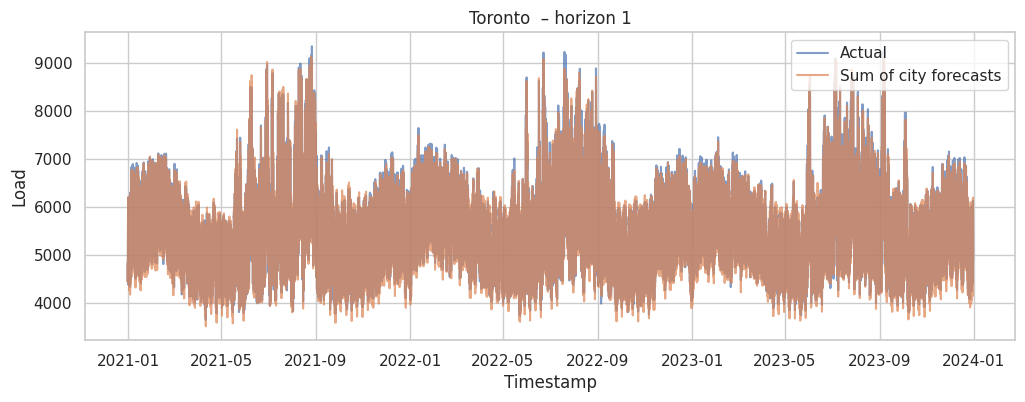

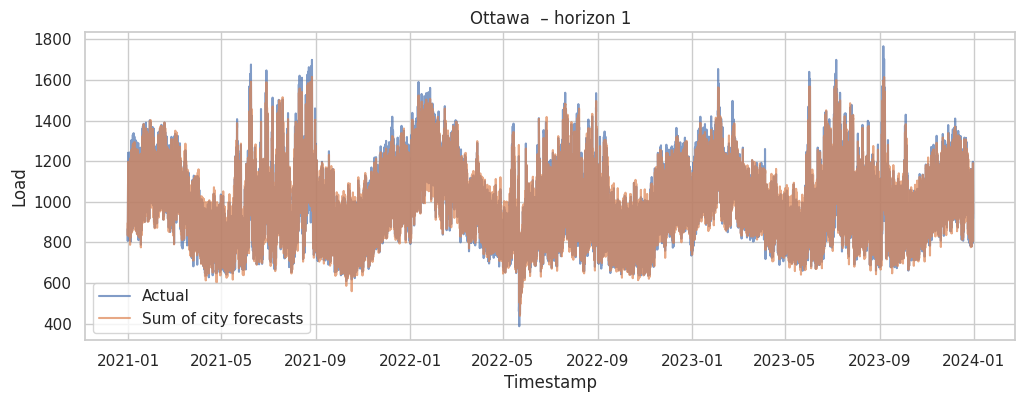

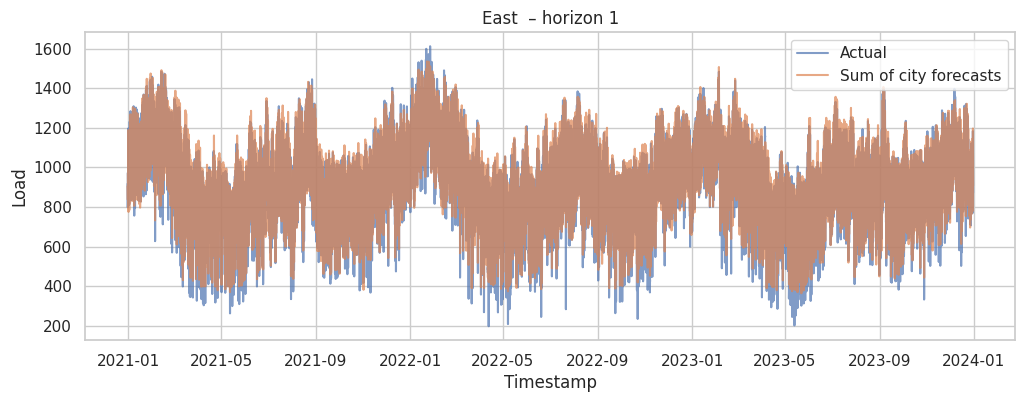

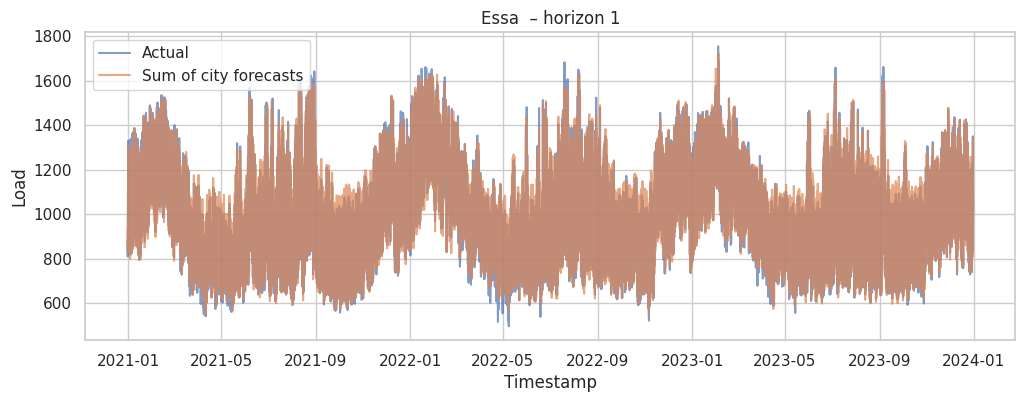

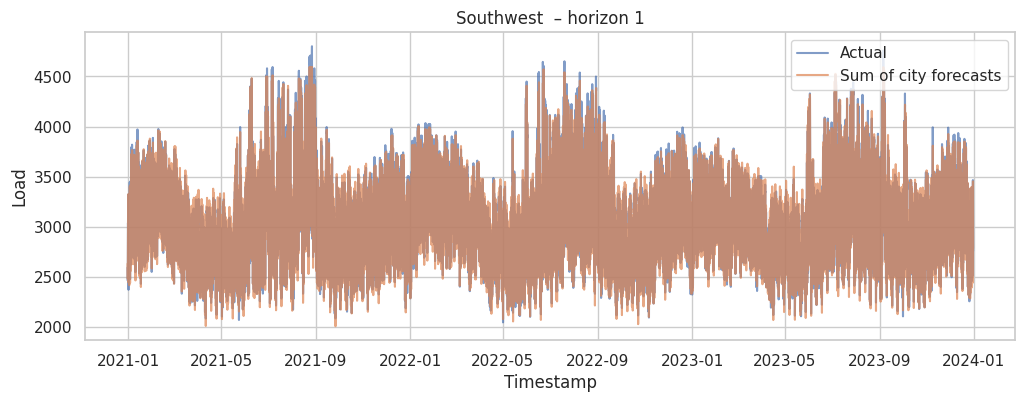

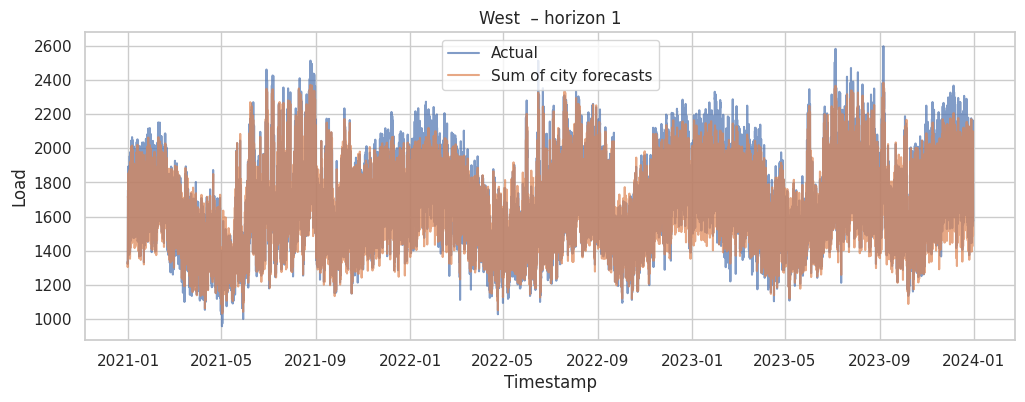

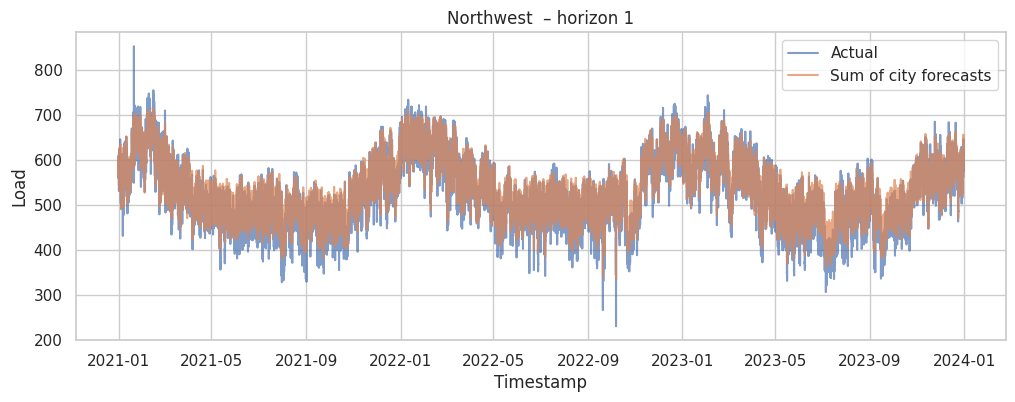

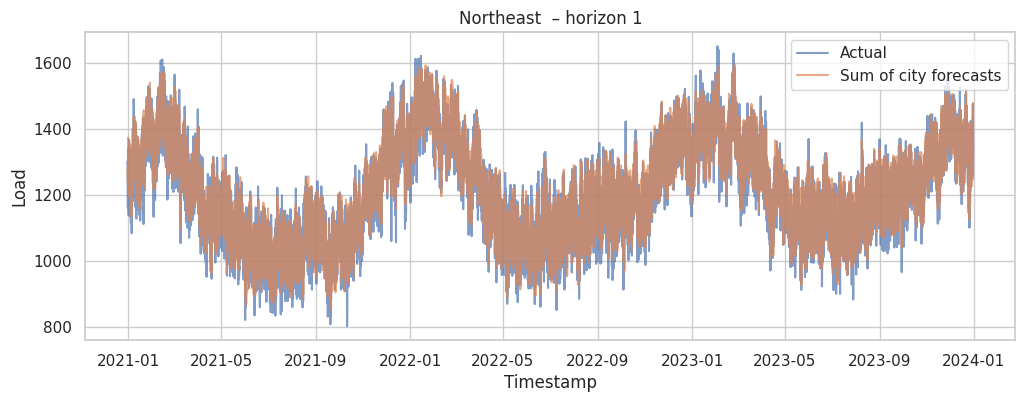

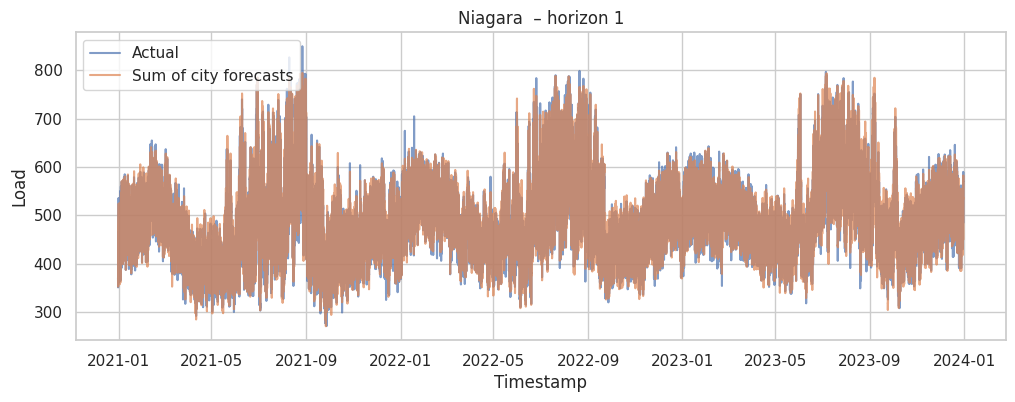

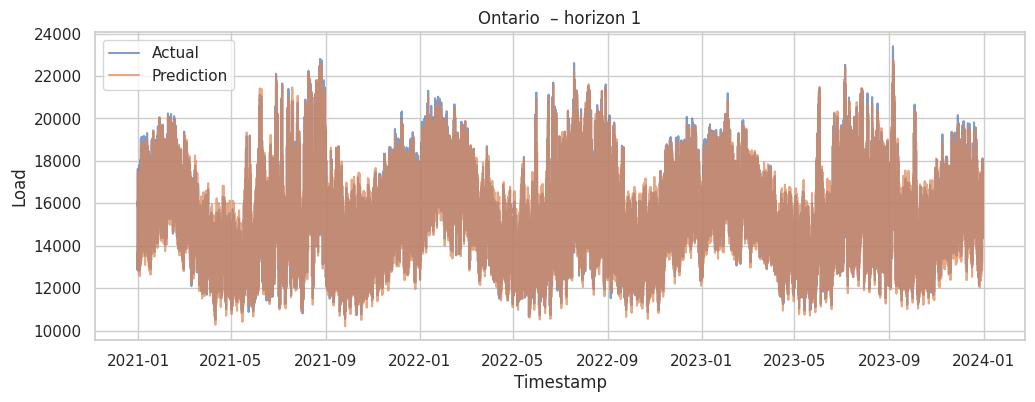

,Actual,Forecast
2020-12-31 00:00:00,13677.0,13738.649381
2020-12-31 01:00:00,13272.0,13314.412484
2020-12-31 02:00:00,13057.0,13050.886411
2020-12-31 03:00:00,12864.0,12940.986993
2020-12-31 04:00:00,12876.0,13178.889704
...,...,...
2023-12-30 19:00:00,16992.0,17379.779731
2023-12-30 20:00:00,16428.0,16784.473518
2023-12-30 21:00:00,15642.0,16181.032304
2023-12-30 22:00:00,14910.0,15338.947544


In [31]:
plot_city_profile(per_city, 'Toronto', horizon=1)
plot_city_profile(per_city, 'Ottawa', horizon=1)
plot_city_profile(per_city, 'East', horizon=1)
plot_city_profile(per_city, 'Essa', horizon=1)
plot_city_profile(per_city, 'Southwest', horizon=1)
plot_city_profile(per_city, 'West', horizon=1)
plot_city_profile(per_city, 'Northwest', horizon=1)
plot_city_profile(per_city, 'Northeast', horizon=1)
plot_city_profile(per_city, 'Niagara', horizon=1)
plot_ontario_aggregate(ontario, horizon=1)

In [32]:
per_city['Toronto']

{'predictions': array([[4807.36055108, 4607.61109176, 4481.22877639, ..., 6082.6093403 ,
         5711.89861888, 5306.08704865],
        [4629.3599252 , 4481.1719686 , 4426.88253118, ..., 5736.20625404,
         5357.17466441, 5013.29863927],
        [4496.73034066, 4438.17323297, 4501.99904977, ..., 5391.85399022,
         5064.46700762, 4810.66224451],
        ...,
        [5602.88010209, 5318.66301151, 5019.17873464, ..., 6375.7234477 ,
         6309.19406857, 6158.26125709],
        [5301.16107989, 4991.04757606, 4728.13572946, ..., 6250.48803894,
         6107.20387773, 5874.23001351],
        [4932.9035771 , 4659.37520894, 4471.93441044, ..., 6027.56765773,
         5812.64303463, 5516.16949449]]),
 'actuals': array([[4841., 4656., 4516., ..., 5527., 5301., 5094.],
        [4656., 4516., 4444., ..., 5301., 5094., 4869.],
        [4516., 4444., 4442., ..., 5094., 4869., 4666.],
        ...,
        [5444., 5127., 4872., ..., 5852., 5685., 5504.],
        [5127., 4872., 4670., ...,

In [33]:
from sklearn.metrics import confusion_matrix

ZSCORE_THRESHOLD = 2.0

def build_ontario_actual_history(city_frames):
    """
    Build full Ontario actual history from the regional actual load columns.
    """
    parts = []

    for city_name, df_city in city_frames.items():
        if city_name not in df_city.columns:
            raise ValueError(
                f"Target column '{city_name}' not found in city_frames['{city_name}']."
            )

        s = df_city[city_name].copy()
        s.name = city_name
        parts.append(s)

    ontario_actual = pd.concat(parts, axis=1).sort_index().sum(axis=1, min_count=1)
    ontario_actual.name = 'ontario_actual'
    return ontario_actual


def extract_ontario_horizon(ontario_result, horizon=1):
    """
    Extract one forecast horizon from the Ontario multistep output.
    """
    h_idx = horizon - 1

    if h_idx >= ontario_result['timestamps'].shape[1]:
        raise ValueError(
            f"Horizon {horizon} exceeds maximum forecast steps "
            f"({ontario_result['timestamps'].shape[1]})."
        )

    timestamps = pd.to_datetime(ontario_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'actual': ontario_result['actuals'][:, h_idx],
        'forecast': ontario_result['predictions'][:, h_idx],
    }, index=pd.DatetimeIndex(timestamps))

    df = df[~df.index.duplicated(keep='first')].sort_index()
    return df


def apply_previous_year_zscore_labels(df_eval, ontario_actual_history, threshold=2.0):
    """
    Label each evaluation year using the previous year's Ontario actual demand statistics.

    For year Y:
        z_actual   = (actual_Y   - mean(actual_{Y-1})) / std(actual_{Y-1})
        z_forecast = (forecast_Y - mean(actual_{Y-1})) / std(actual_{Y-1})
    """
    df = df_eval.copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    hist = ontario_actual_history.copy().dropna()
    if not isinstance(hist.index, pd.DatetimeIndex):
        hist.index = pd.to_datetime(hist.index)

    df['year'] = df.index.year
    df['benchmark_year'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
    df['benchmark_mean'] = np.nan
    df['benchmark_std'] = np.nan
    df['zscore_actual'] = np.nan
    df['zscore_forecast'] = np.nan
    df['peak_actual'] = pd.Series(pd.NA, index=df.index, dtype='Int64')
    df['peak_forecast'] = pd.Series(pd.NA, index=df.index, dtype='Int64')

    for year in sorted(df['year'].dropna().unique()):
        mask = df['year'] == year
        prev_year = year - 1

        prev_actual = hist[hist.index.year == prev_year]
        if prev_actual.empty:
            print(f"Skipping {year}: no previous-year actual data found for {prev_year}.")
            continue

        mean_val = prev_actual.mean()
        std_val = prev_actual.std(ddof=0)

        if pd.isna(std_val) or std_val == 0:
            print(f"Skipping {year}: invalid std for benchmark year {prev_year}.")
            continue

        df.loc[mask, 'benchmark_year'] = prev_year
        df.loc[mask, 'benchmark_mean'] = mean_val
        df.loc[mask, 'benchmark_std'] = std_val

        df.loc[mask, 'zscore_actual'] = (
            (df.loc[mask, 'actual'] - mean_val) / std_val
        )
        df.loc[mask, 'zscore_forecast'] = (
            (df.loc[mask, 'forecast'] - mean_val) / std_val
        )

        df.loc[mask, 'peak_actual'] = (
            df.loc[mask, 'zscore_actual'] >= threshold
        ).astype(int)
        df.loc[mask, 'peak_forecast'] = (
            df.loc[mask, 'zscore_forecast'] >= threshold
        ).astype(int)

    return df


def create_ontario_peak_dataframe_prev_year(ontario_result, city_frames, horizon=1, threshold=2.0):
    """
    Create labeled Ontario evaluation dataframe for one horizon using previous-year z-score logic.
    """
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)
    ontario_actual_history = build_ontario_actual_history(city_frames)

    df_labeled = apply_previous_year_zscore_labels(
        df_eval=df_horizon,
        ontario_actual_history=ontario_actual_history,
        threshold=threshold
    )

    return df_labeled

In [34]:
Ontario_peak_1 = create_ontario_peak_dataframe_prev_year(
    ontario, city_frames, horizon=1, threshold=ZSCORE_THRESHOLD
)

Ontario_peak_8 = create_ontario_peak_dataframe_prev_year(
    ontario, city_frames, horizon=8, threshold=ZSCORE_THRESHOLD
)

Ontario_peak_16 = create_ontario_peak_dataframe_prev_year(
    ontario, city_frames, horizon=16, threshold=ZSCORE_THRESHOLD
)


Ontario_peak_24 = create_ontario_peak_dataframe_prev_year(
    ontario, city_frames, horizon=24, threshold=ZSCORE_THRESHOLD
)

In [35]:
print(
    Ontario_peak_8.groupby('year')['benchmark_year']
    .agg(lambda x: x.dropna().unique().tolist())
)

year
2020    [2019]
2021    [2020]
2022    [2021]
2023    [2022]
Name: benchmark_year, dtype: object


In [36]:
def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    timestamps = pd.to_datetime(city_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx],
    }, index=pd.DatetimeIndex(timestamps))
    df = df[~df.index.duplicated(keep='first')].sort_index()
    return df

def plot_city_profile(per_city_results, city_name, months=None, horizon=1):
    df_plot = _pred_frame(per_city_results[city_name], horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Sum of city forecasts', alpha=0.7)
    plt.title(f'{city_name}  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

def plot_ontario_aggregate(ontario_result, months=None, horizon=1):
    df_plot = _pred_frame(ontario_result, horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Prediction', alpha=0.7)
    plt.title(f'Ontario  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

## running for warmest days

In [ ]:
import numpy as np
import pandas as pd

YEARS_OF_INTEREST = range(2020, 2024)
N_EXTREME_DAYS = 15
TEMP_COLUMN = 'temp'  # change if your temperature column has a different name

def _forecast_flat(info):
    """Flatten saved predictions for easier filtering."""
    num_windows, n_steps_out = info['timestamps'].shape[:2]
    timestamps = pd.to_datetime(info['timestamps'].reshape(-1))
    horizons = np.tile(np.arange(1, n_steps_out + 1), num_windows)
    df = pd.DataFrame({
        'timestamp': timestamps,
        'horizon': horizons,
        'actual': info['actuals'].reshape(-1),
        'forecast': info['predictions'].reshape(-1),
    })
    df['date'] = df['timestamp'].dt.normalize()
    return df

def _cold_warm_day_frames(df_city, years, n_days, temp_col):
    """Return dataframes listing coldest/warmest days with mean temperature."""
    df_period = df_city.loc[df_city.index.year.isin(years)]
    daily_temp = df_period[temp_col].resample('D').mean().dropna()
    cold = daily_temp.nsmallest(n_days).to_frame('mean_temp').reset_index(names='date')
    warm = daily_temp.nlargest(n_days).to_frame('mean_temp').reset_index(names='date')
    cold['date'] = cold['date'].dt.normalize()
    warm['date'] = warm['date'].dt.normalize()
    return cold, warm

def _compress_daily(table):
    """Collapse hourly rows to one row per date (mean actual/forecast)."""
    if table.empty:
        return table
    grouped = table.groupby('date').agg({
        'timestamp': 'min',       # representative timestamp (earliest)
        'mean_temp': 'first',
        'actual': 'mean',
        'forecast': 'mean',
        'absolute_error': 'mean'
    }).reset_index().rename(columns={
        'actual': 'actual_mean',
        'forecast': 'forecast_mean',
        'absolute_error': 'absolute_error_mean',
        'timestamp': 'representative_timestamp'
    })
    return grouped[['date', 'representative_timestamp', 'mean_temp',
                    'actual_mean', 'forecast_mean', 'absolute_error_mean']]

def extreme_daily_tables(per_city_results, city_frames,
                         years=YEARS_OF_INTEREST,
                         n_days=N_EXTREME_DAYS,
                         temp_col=TEMP_COLUMN):
    outputs = {}
    for city, info in per_city_results.items():
        df_city = city_frames[city]
        cold_days, warm_days = _cold_warm_day_frames(df_city, years, n_days, temp_col)
        flat = _forecast_flat(info)

        table_cold = (
            flat.merge(cold_days, on='date', how='inner')
                .assign(absolute_error=lambda d: np.abs(d['actual'] - d['forecast']))
                .sort_values(['date', 'timestamp', 'horizon'])
        )
        table_warm = (
            flat.merge(warm_days, on='date', how='inner')
                .assign(absolute_error=lambda d: np.abs(d['actual'] - d['forecast']))
                .sort_values(['date', 'timestamp', 'horizon'])
        )

        outputs[city] = {
            'cold_table': _compress_daily(table_cold),
            'warm_table': _compress_daily(table_warm),
        }
    return outputs

extreme_daily_tables_by_city = extreme_daily_tables(per_city, city_frames)

In [ ]:
city = 'Toronto'
print("Coldest days (mean temp + mean actual/forecast):")
display(extreme_daily_tables_by_city[city]['cold_table'])

Coldest days (mean temp + mean actual/forecast):


,date,representative_timestamp,mean_temp,actual_mean,forecast_mean,absolute_error_mean
0,2021-02-12,2021-02-12,-10.383333,6345.041667,6257.494823,167.673816
1,2022-01-11,2022-01-11,-12.741667,6650.208333,6447.647596,262.007824
2,2022-01-15,2022-01-15,-16.404167,6222.291667,6029.643762,231.784190
3,2022-01-20,2022-01-20,-12.583333,6347.916667,6243.630783,142.425750
4,2022-01-21,2022-01-21,-12.962500,6480.833333,6362.950424,130.895270
5,2022-01-26,2022-01-26,-10.829167,6485.875000,6463.708169,90.384304
6,2022-01-28,2022-01-28,-11.645833,6470.333333,6348.157673,137.970310
7,2022-01-29,2022-01-29,-13.716667,6189.125000,6144.385927,95.766491
8,2022-02-04,2022-02-04,-10.141667,6453.250000,6364.269343,109.782423
9,2022-02-05,2022-02-05,-10.204167,6034.333333,6074.588776,93.663447


In [ ]:
print("Warmest days (mean temp + mean actual/forecast):")
display(extreme_daily_tables_by_city[city]['warm_table'])

Warmest days (mean temp + mean actual/forecast):


,date,representative_timestamp,mean_temp,actual_mean,forecast_mean,absolute_error_mean
0,2021-07-06,2021-07-06,27.912500,7329.958333,6979.986146,361.887302
1,2021-08-23,2021-08-23,26.904167,7506.500000,7283.037050,252.507422
2,2022-06-22,2022-06-22,26.366667,7541.875000,6932.493820,628.183100
3,2022-07-19,2022-07-19,26.912500,7488.375000,6770.359139,723.122398
4,2022-07-20,2022-07-20,27.037500,7836.125000,7265.583623,574.258229
5,2022-08-07,2022-08-07,26.475000,7378.250000,6900.593080,490.239701
6,2023-07-05,2023-07-05,26.691667,7688.458333,7317.798145,379.556800


## FORECAST ACCURACY METRICS
common metrics and metric in literature

In [ ]:
# ============================================================================
# FORECAST ACCURACY METRICS (R², MAE, MAPE, Displacement Score)
# ============================================================================
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_r2(y_true, y_pred):
    """Calculate R² (Coefficient of Determination)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])

def calculate_mae(y_true, y_pred):
    """Calculate MAE (Mean Absolute Error)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(y_true[mask], y_pred[mask])

def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    # Avoid division by zero
    mask_nonzero = y_true_clean != 0
    if mask_nonzero.sum() == 0:
        return np.nan

    percentage_errors = np.abs((y_true_clean[mask_nonzero] - y_pred_clean[mask_nonzero]) / y_true_clean[mask_nonzero]) * 100
    return np.mean(percentage_errors)

def extract_ontario_horizon(ontario_result, horizon=1):
    """
    Extract Ontario data for a specific forecast horizon.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps' keys
    horizon : int
        Forecast horizon (1-24)

    Returns:
    --------
    pd.DataFrame with columns: timestamp, actual, forecast
    """
    h_idx = horizon - 1
    if h_idx >= ontario_result['timestamps'].shape[1]:
        raise ValueError(f"Horizon {horizon} exceeds maximum forecast steps ({ontario_result['timestamps'].shape[1]})")

    timestamps = pd.to_datetime(ontario_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual': ontario_result['actuals'][:, h_idx],
        'forecast': ontario_result['predictions'][:, h_idx],
    })
    df = df[~df.index.duplicated(keep='first')].sort_values('timestamp').reset_index(drop=True)
    df.set_index('timestamp', inplace=True)
    return df



def detect_peaks_zscore_previous_year(demand_series, threshold=2.0, reference_series=None):
    """
    Label each year's peaks using only the previous year's ACTUAL data.
    """
    demand_series = demand_series.copy()
    if reference_series is None:
        reference_series = demand_series

    peak_status = pd.Series(0, index=demand_series.index, dtype=int)
    year_stats = _build_previous_year_stats(reference_series)

    for year in sorted(demand_series.index.year.unique()):
        year_mask = demand_series.index.year == year
        stats = year_stats.get(year)

        if stats is None:
            continue

        mean_val = stats['mean']
        std_val = stats['std']

        z_scores = (demand_series.loc[year_mask] - mean_val) / std_val
        peak_status.loc[year_mask] = (z_scores >= threshold).astype(int)

    return peak_status


def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=4):
    """
    Detect peaks using updated logic:
    - Real data: One peak hour per day (highest demand among hours exceeding threshold)
    - Forecast: One peak window per day (rolling window with highest sum)

    Parameters:
    -----------
    df_ontario : pd.DataFrame
        Ontario DataFrame with 'actual' and 'forecast' columns
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    pd.DataFrame with daily peak information and classification
    """
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    # Calculate Z-scores for actual and forecast (handle NaN values)
    valid_actual = df['actual'].dropna()
    valid_forecast = df['forecast'].dropna()

    zscore_actual_values = zscore(valid_actual)
    zscore_forecast_values = zscore(valid_forecast)

    # Create aligned z-score series
    df['zscore_actual'] = pd.Series(zscore_actual_values, index=valid_actual.index)
    df['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    # Initialize results list
    results = []

    # Process each day
    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        # Find hours exceeding threshold
        above_threshold = day_data[day_data['zscore_actual'] >= zscore_threshold]

        if len(above_threshold) > 0:
            # Select hour with highest demand
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        # Generate rolling windows
        eligible_windows = []

        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            # Check if window is eligible (at least one hour above threshold)
            if (window_data['zscore_forecast'] >= zscore_threshold).any():
                # Sum all values in window
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            # Select window with highest sum
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            # Check if true peak hour falls within predicted window
            if best_window['start'] <= true_peak_idx <= best_window['end']:
                classification = 'TP'  # True Positive
            else:
                classification = 'FN'  # False Negative
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'  # False Negative
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'  # False Positive
        else:
            classification = 'TN'  # True Negative

        # Store results
        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        # Add true peak information
        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour['zscore_actual']
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        # Add predicted peak window information
        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)

    # Add year column
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year

    return results_df

def calculate_displacement_score(peaks_updated_df):
    """
    Calculate Displacement Score (DS): Average absolute difference between
    actual peak hour and predicted peak hour.

    Parameters:
    -----------
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated with true_peak_timestamp and
        predicted_window_start columns

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour|)
    """
    # Filter to days where both actual and predicted peaks exist
    valid_days = peaks_updated_df[
        (peaks_updated_df['has_true_peak'] == True) &
        (peaks_updated_df['has_predicted_peak'] == True)
    ].copy()

    if len(valid_days) == 0:
        return np.nan

    # Extract hour of day for actual peak
    valid_days['actual_peak_hour'] = pd.to_datetime(valid_days['true_peak_timestamp']).dt.hour

    # Extract hour of day for predicted peak window (use start of window)
    valid_days['predicted_peak_hour'] = pd.to_datetime(valid_days['predicted_window_start']).dt.hour

    # Calculate absolute difference in hours
    valid_days['hour_difference'] = np.abs(valid_days['actual_peak_hour'] - valid_days['predicted_peak_hour'])

    # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
    # If difference > 12, it means we should go the other way around the clock
    valid_days['hour_difference'] = valid_days['hour_difference'].apply(
        lambda x: min(x, 24 - x) if x > 12 else x
    )

    # Calculate average
    ds = valid_days['hour_difference'].mean()

    return ds

# ============================================================================
# EVALUATE METRICS AT STEPS 1, 4, 8, 12, 16, 24
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Forecast Accuracy Metrics Evaluation ===")
print(f"=== R², MAE, MAPE, and Displacement Score (DS) ===")
print(f"{'='*70}")

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 4
horizons_to_evaluate = [1, 4, 8, 12, 16, 24]

metrics_results = []

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

    # Calculate forecast accuracy metrics (R², MAE, MAPE)
    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    # Calculate Displacement Score using peak detection
    peaks_updated = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    ds = calculate_displacement_score(peaks_updated)

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (hours)': ds
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS = {ds:.2f} hours")

# Display results as a table
metrics_df = pd.DataFrame(metrics_results)
print(f"\n{'='*70}")
print(f"Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))

# Also create a formatted summary
print(f"\n{'='*70}")
print(f"Formatted Summary:")
print(f"{'='*70}")
print(f"{'Step':<6} {'R²':<10} {'MAE (MW)':<12} {'MAPE (%)':<12} {'DS (hours)':<12}")
print(f"{'-'*70}")
for result in metrics_results:
    print(f"{result['Step']:<6} {result['R²']:<10.4f} {result['MAE']:<12.2f} {result['MAPE (%)']:<12.2f} {result['DS (hours)']:<12.2f}")

# Year-by-year breakdown (optional - if you want to see metrics per year)
print(f"\n{'='*70}")
print(f"Year-by-Year Breakdown:")
print(f"{'='*70}")

years_to_analyze = [2021, 2022, 2023]
yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    df_horizon['year'] = df_horizon.index.year

    peaks_updated = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]

        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_year = calculate_displacement_score(peaks_year)

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (hours)': ds_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(f"\nYear-by-Year Metrics:")
print(yearly_metrics_df.to_string(index=False))

print(f"\n{'='*70}")






=== Forecast Accuracy Metrics Evaluation ===
=== R², MAE, MAPE, and Displacement Score (DS) ===

Processing horizon 1...
  R² = 0.9807
  MAE = 240.31 MW
  MAPE = 1.57%
  DS = 1.13 hours

Processing horizon 4...
  R² = 0.9577
  MAE = 344.51 MW
  MAPE = 2.24%
  DS = 1.16 hours

Processing horizon 8...
  R² = 0.9222
  MAE = 466.31 MW
  MAPE = 3.04%
  DS = 0.98 hours

Processing horizon 12...
  R² = 0.8896
  MAE = 565.38 MW
  MAPE = 3.70%
  DS = 1.23 hours

Processing horizon 16...
  R² = 0.8573
  MAE = 651.43 MW
  MAPE = 4.29%
  DS = 1.24 hours

Processing horizon 24...
  R² = 0.8315
  MAE = 714.33 MW
  MAPE = 4.71%
  DS = 1.12 hours

Summary Table - Forecast Accuracy Metrics by Step:
 Step       R²        MAE  MAPE (%)  DS (hours)
    1 0.980713 240.312639  1.570064    1.126214
    4 0.957682 344.505897  2.238414    1.156250
    8 0.922242 466.310021  3.036462    0.975610
   12 0.889565 565.375945  3.700365    1.228916
   16 0.857265 651.430462  4.288410    1.236842
   24 0.831482 714.3

/tmp/ipykernel_29795/789153441.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=peaks_all_df, x="classification", order=class_order, palette="Set2")


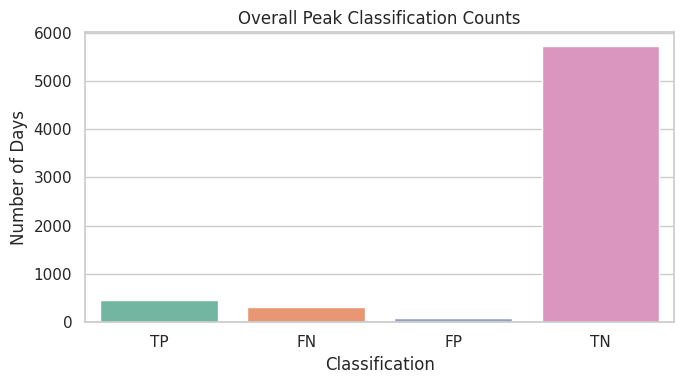

/tmp/ipykernel_29795/789153441.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peaks_all_df.groupby(["Step", "classification"])


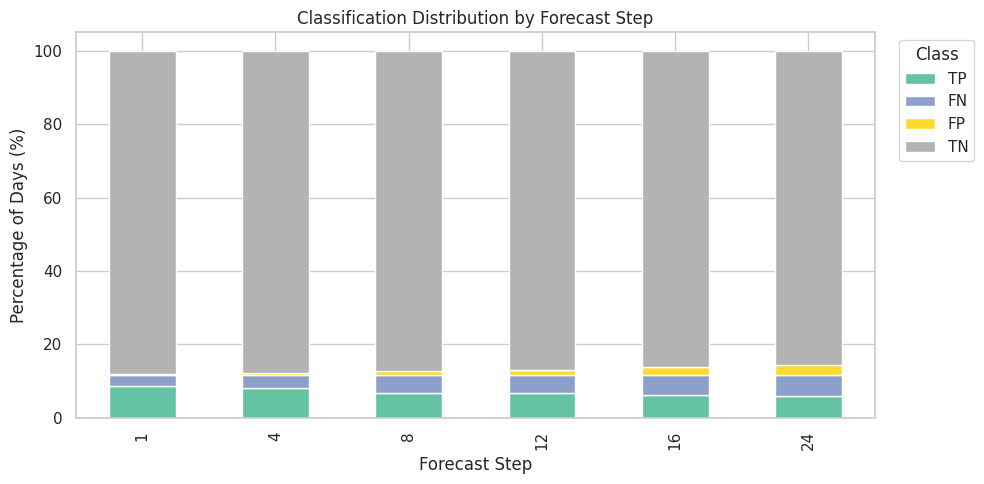

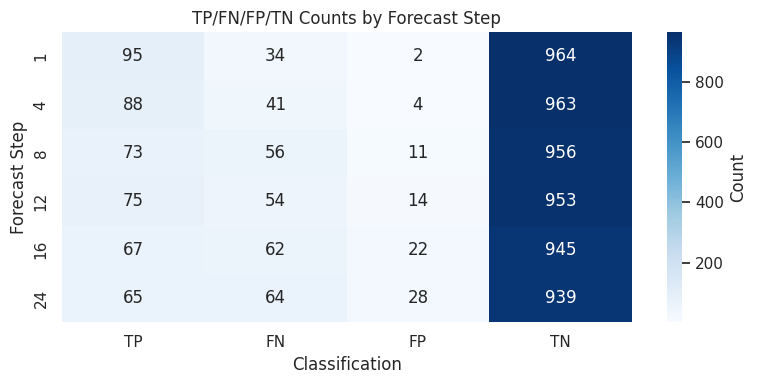

In [ ]:
# ============================================================================
# VISUALIZE TP/FN/FP/TN CLASSIFICATIONS
# ============================================================================
all_peaks = []

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    peaks_updated = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )
    peaks_updated["Step"] = horizon
    all_peaks.append(peaks_updated)

peaks_all_df = pd.concat(all_peaks, ignore_index=True)

class_order = ["TP", "FN", "FP", "TN"]
peaks_all_df["classification"] = pd.Categorical(
    peaks_all_df["classification"], categories=class_order, ordered=True
)

# 1) Overall counts
plt.figure(figsize=(7, 4))
sns.countplot(data=peaks_all_df, x="classification", order=class_order, palette="Set2")
plt.title("Overall Peak Classification Counts")
plt.xlabel("Classification")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

# 2) Stacked percentage by step
step_class_counts = (
    peaks_all_df.groupby(["Step", "classification"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=class_order)
)

step_class_pct = step_class_counts.div(step_class_counts.sum(axis=1), axis=0) * 100

ax = step_class_pct.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="Set2")
plt.title("Classification Distribution by Forecast Step")
plt.xlabel("Forecast Step")
plt.ylabel("Percentage of Days (%)")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3) Heatmap of counts
plt.figure(figsize=(8, 4))
sns.heatmap(
    step_class_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar_kws={"label": "Count"}
)
plt.title("TP/FN/FP/TN Counts by Forecast Step")
plt.xlabel("Classification")
plt.ylabel("Forecast Step")
plt.tight_layout()
plt.show()

## top five ieso for 8 hours ahead

In [ ]:
# ============================================================================
# DETAILED CSV EXPORT FOR HORIZON 8
# Previous-year z-score labeling + IESO top-5 + windows 4/8/12/16
# ============================================================================

from sklearn.metrics import r2_score

HORIZON_TO_EXPORT = 8
WINDOW_SIZES = [4, 8, 12, 16]
YEARS_TO_ANALYZE = [2021, 2022, 2023]
ZSCORE_THRESHOLD = 2.0


# ----------------------------------------------------------------------------
# BASIC METRICS
# ----------------------------------------------------------------------------
def calculate_r2(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() < 2:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])


def calculate_mae(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]))


def calculate_mape(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    nonzero_mask = y_true_clean != 0
    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true_clean[nonzero_mask] - y_pred_clean[nonzero_mask]) / y_true_clean[nonzero_mask])
    ) * 100


def wrapped_hour_diff(h1, h2):
    diff = abs(int(h1) - int(h2))
    return min(diff, 24 - diff)


# ----------------------------------------------------------------------------
# IESO TOP-5 TABLE
# ----------------------------------------------------------------------------
def build_ieso_top5_table(ieso_top5_peaks):
    rows = []

    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            hour_ending = int(peak_info['hour_ending'])
            hour_start = hour_ending - 1
            timestamp = peak_date + pd.Timedelta(hours=hour_start)

            rows.append({
                'ieso_year': year,
                'date': peak_date,
                'ieso_timestamp': timestamp,
                'ieso_rank': int(peak_info['rank']),
                'ieso_hour_ending': hour_ending,
                'ieso_hour_start': hour_start
            })

    return pd.DataFrame(rows).sort_values(['ieso_year', 'ieso_rank']).reset_index(drop=True)


# ----------------------------------------------------------------------------
# DAILY WINDOW EVALUATION USING ALREADY-LABELED HOURLY DATA
# ----------------------------------------------------------------------------
def detect_peaks_daily(df_hourly_labeled, window_hours=8):
    """
    df_hourly_labeled must already contain:
    - actual, forecast
    - zscore_actual, zscore_forecast
    - peak_actual, peak_forecast
    - year, benchmark_year
    """
    df = df_hourly_labeled.copy()
    df['date'] = df.index.normalize()

    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        actual_peak_hours = day_data[day_data['peak_actual'] == 1]
        if len(actual_peak_hours) > 0:
            true_peak_idx = actual_peak_hours['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = pd.NaT
            true_peak_hour = None
            has_true_peak = False

        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i + window_hours]

            if (window_data['peak_forecast'] == 1).any():
                eligible_windows.append({
                    'start': window_data.index[0],
                    'end': window_data.index[-1],
                    'sum': window_data['forecast'].sum()
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        if has_true_peak and has_predicted_peak:
            classification = 'TP' if best_window['start'] <= true_peak_idx <= best_window['end'] else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        results.append({
            'date': date,
            'year': int(day_data['year'].iloc[0]),
            'benchmark_year': int(day_data['benchmark_year'].dropna().iloc[0]) if day_data['benchmark_year'].notna().any() else np.nan,
            'window_hours': window_hours,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
            'true_peak_timestamp': true_peak_idx if has_true_peak else pd.NaT,
            'true_peak_hour': true_peak_idx.hour if has_true_peak else np.nan,
            'true_peak_demand': true_peak_hour['actual'] if has_true_peak else np.nan,
            'true_peak_zscore': true_peak_hour['zscore_actual'] if has_true_peak else np.nan,
            'predicted_window_start': best_window['start'] if has_predicted_peak else pd.NaT,
            'predicted_window_end': best_window['end'] if has_predicted_peak else pd.NaT,
            'predicted_window_start_hour': best_window['start'].hour if has_predicted_peak else np.nan,
            'predicted_window_end_hour': best_window['end'].hour if has_predicted_peak else np.nan,
            'predicted_window_sum': best_window['sum'] if has_predicted_peak else np.nan,
        })

    return pd.DataFrame(results)


def calculate_displacement_score(daily_df):
    valid = daily_df[
        daily_df['true_peak_timestamp'].notna() &
        daily_df['predicted_window_start'].notna()
    ].copy()

    if len(valid) == 0:
        return np.nan

    valid['hour_difference'] = valid.apply(
        lambda row: wrapped_hour_diff(
            pd.to_datetime(row['true_peak_timestamp']).hour,
            pd.to_datetime(row['predicted_window_start']).hour
        ),
        axis=1
    )

    return valid['hour_difference'].mean()


def calculate_confusion_metrics(daily_df):
    TP = (daily_df['classification'] == 'TP').sum()
    FP = (daily_df['classification'] == 'FP').sum()
    FN = (daily_df['classification'] == 'FN').sum()
    TN = (daily_df['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1_score = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0
        else np.nan
    )

    return {
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    }


# ----------------------------------------------------------------------------
# TOP-5 EVENT DETAIL
# ----------------------------------------------------------------------------
def build_top5_window_detail(df_hourly, daily_df, top5_table):
    """
    One row per IESO top-5 event, merged with:
    - exact hourly actual/forecast/zscores at the IESO timestamp
    - daily predicted window result for the selected window size
    """
    hourly_exact = (
        df_hourly.reset_index()
        .rename(columns={'index': 'timestamp'})
        .rename(columns={'timestamp': 'ieso_timestamp'})
    )

    cols_from_hourly = [
        'ieso_timestamp', 'actual', 'forecast',
        'zscore_actual', 'zscore_forecast',
        'peak_actual', 'peak_forecast',
        'year', 'benchmark_year', 'benchmark_mean', 'benchmark_std'
    ]
    cols_from_hourly = [c for c in cols_from_hourly if c in hourly_exact.columns]

    top5_detail = top5_table.merge(
        hourly_exact[cols_from_hourly],
        on='ieso_timestamp',
        how='left'
    )

    daily_cols = [
        'date', 'window_hours', 'classification',
        'has_true_peak', 'has_predicted_peak',
        'true_peak_timestamp', 'true_peak_hour',
        'predicted_window_start', 'predicted_window_end',
        'predicted_window_start_hour', 'predicted_window_end_hour',
        'predicted_window_sum'
    ]

    top5_detail = top5_detail.merge(
        daily_df[daily_cols],
        on='date',
        how='left'
    )

    top5_detail['ieso_in_predicted_window'] = (
        top5_detail['predicted_window_start'].notna() &
        (top5_detail['ieso_timestamp'] >= top5_detail['predicted_window_start']) &
        (top5_detail['ieso_timestamp'] <= top5_detail['predicted_window_end'])
    )

    top5_detail['top5_hour_difference_from_window_start'] = top5_detail.apply(
        lambda row: wrapped_hour_diff(row['ieso_hour_start'], row['predicted_window_start_hour'])
        if pd.notna(row['predicted_window_start_hour']) else np.nan,
        axis=1
    )

    top5_detail['true_peak_matches_ieso_timestamp'] = (
        pd.to_datetime(top5_detail['true_peak_timestamp']) == pd.to_datetime(top5_detail['ieso_timestamp'])
    )

    top5_detail = top5_detail.rename(columns={
        'actual': 'actual_at_ieso_top5',
        'forecast': 'forecast_at_ieso_top5',
        'zscore_actual': 'zscore_actual_at_ieso_top5',
        'zscore_forecast': 'zscore_forecast_at_ieso_top5',
        'peak_actual': 'peak_actual_at_ieso_top5',
        'peak_forecast': 'peak_forecast_at_ieso_top5',
        'year': 'data_year'
    })

    return top5_detail


# ----------------------------------------------------------------------------
# SUMMARY METRICS
# ----------------------------------------------------------------------------
def build_metrics_row(df_hourly, daily_df, top5_detail, scope='overall', year=None):
    if year is not None:
        df_hourly = df_hourly[df_hourly['year'] == year].copy()
        daily_df = daily_df[daily_df['year'] == year].copy()
        top5_detail = top5_detail[top5_detail['ieso_year'] == year].copy()

    y_true = df_hourly['actual'].values
    y_pred = df_hourly['forecast'].values

    confusion = calculate_confusion_metrics(daily_df)
    ds_all = calculate_displacement_score(daily_df)

    top5_pred = top5_detail[top5_detail['predicted_window_start'].notna()].copy()
    ds_top5 = (
        top5_pred['top5_hour_difference_from_window_start'].mean()
        if len(top5_pred) > 0 else np.nan
    )
    top5_hit_rate = (
        top5_detail['ieso_in_predicted_window'].mean()
        if len(top5_detail) > 0 else np.nan
    )

    return {
        'scope': scope,
        'year': year if year is not None else 'all',
        'window_hours': int(daily_df['window_hours'].iloc[0]) if len(daily_df) > 0 else np.nan,
        'R²': calculate_r2(y_true, y_pred),
        'MAE': calculate_mae(y_true, y_pred),
        'MAPE (%)': calculate_mape(y_true, y_pred),
        'DS (All Peak Days)': ds_all,
        'DS (IESO Top5)': ds_top5,
        'Top5 Hit Rate': top5_hit_rate,
        'Top5 Count': len(top5_detail),
        **confusion
    }


# ----------------------------------------------------------------------------
# BUILD HOURLY DATA FOR HORIZON 8
# ----------------------------------------------------------------------------
df_h8 = create_ontario_peak_dataframe_prev_year(
    ontario,
    city_frames,
    horizon=HORIZON_TO_EXPORT,
    threshold=ZSCORE_THRESHOLD
).copy()

df_h8['date'] = df_h8.index.normalize()
df_h8['hour'] = df_h8.index.hour
df_h8['month'] = df_h8.index.month
df_h8['day'] = df_h8.index.day
df_h8['dayofweek'] = df_h8.index.dayofweek
df_h8['horizon'] = HORIZON_TO_EXPORT

top5_table = build_ieso_top5_table(IESO_TOP5_PEAKS)

# Add exact Top-5 markers to hourly data
top5_exact = top5_table[['ieso_timestamp', 'ieso_year', 'ieso_rank', 'ieso_hour_ending', 'ieso_hour_start']].copy()
top5_exact = top5_exact.rename(columns={'ieso_timestamp': 'timestamp'})

hourly_export = df_h8.reset_index().rename(columns={'index': 'timestamp'})
hourly_export = hourly_export.merge(top5_exact, on='timestamp', how='left')

hourly_export['is_ieso_top5_exact_hour'] = hourly_export['ieso_rank'].notna()
hourly_export['is_ieso_top5_day'] = hourly_export['date'].isin(top5_table['date'])


# ----------------------------------------------------------------------------
# BUILD DAILY + TOP5 DETAIL FOR EACH WINDOW
# ----------------------------------------------------------------------------
daily_exports = []
top5_exports = []
metrics_rows = []

for window_hours in WINDOW_SIZES:
    daily_df = detect_peaks_daily(df_h8, window_hours=window_hours)
    top5_detail = build_top5_window_detail(df_h8, daily_df, top5_table)

    daily_exports.append(daily_df.assign(horizon=HORIZON_TO_EXPORT))
    top5_exports.append(top5_detail.assign(horizon=HORIZON_TO_EXPORT))

    metrics_rows.append(
        build_metrics_row(df_h8, daily_df, top5_detail, scope='overall', year=None)
    )

    for year in YEARS_TO_ANALYZE:
        metrics_rows.append(
            build_metrics_row(df_h8, daily_df, top5_detail, scope='year', year=year)
        )

    # Merge daily window outputs back onto hourly rows for easier Excel filtering
    merge_cols = [
        'date', 'window_hours', 'classification',
        'has_true_peak', 'has_predicted_peak',
        'true_peak_timestamp', 'true_peak_hour', 'true_peak_demand', 'true_peak_zscore',
        'predicted_window_start', 'predicted_window_end',
        'predicted_window_start_hour', 'predicted_window_end_hour',
        'predicted_window_sum'
    ]
    daily_for_merge = daily_df[merge_cols].copy()

    rename_map = {
        'classification': f'classification_w{window_hours}',
        'has_true_peak': f'has_true_peak_w{window_hours}',
        'has_predicted_peak': f'has_predicted_peak_w{window_hours}',
        'true_peak_timestamp': f'true_peak_timestamp_w{window_hours}',
        'true_peak_hour': f'true_peak_hour_w{window_hours}',
        'true_peak_demand': f'true_peak_demand_w{window_hours}',
        'true_peak_zscore': f'true_peak_zscore_w{window_hours}',
        'predicted_window_start': f'predicted_window_start_w{window_hours}',
        'predicted_window_end': f'predicted_window_end_w{window_hours}',
        'predicted_window_start_hour': f'predicted_window_start_hour_w{window_hours}',
        'predicted_window_end_hour': f'predicted_window_end_hour_w{window_hours}',
        'predicted_window_sum': f'predicted_window_sum_w{window_hours}',
    }
    daily_for_merge = daily_for_merge.rename(columns=rename_map).drop(columns=['window_hours'])

    hourly_export = hourly_export.merge(daily_for_merge, on='date', how='left')


# ----------------------------------------------------------------------------
# FINAL EXPORT TABLES
# ----------------------------------------------------------------------------
daily_export = pd.concat(daily_exports, ignore_index=True)
top5_export = pd.concat(top5_exports, ignore_index=True)
metrics_export = pd.DataFrame(metrics_rows)

# Nice column order for hourly export
preferred_hourly_cols = [
    'timestamp', 'date', 'year', 'month', 'day', 'dayofweek', 'hour', 'horizon',
    'actual', 'forecast',
    'benchmark_year', 'benchmark_mean', 'benchmark_std',
    'zscore_actual', 'zscore_forecast',
    'peak_actual', 'peak_forecast',
    'is_ieso_top5_exact_hour', 'is_ieso_top5_day',
    'ieso_year', 'ieso_rank', 'ieso_hour_ending', 'ieso_hour_start'
]
other_hourly_cols = [c for c in hourly_export.columns if c not in preferred_hourly_cols]
hourly_export = hourly_export[[c for c in preferred_hourly_cols if c in hourly_export.columns] + other_hourly_cols]

# Nice column order for daily export
preferred_daily_cols = [
    'horizon', 'window_hours', 'date', 'year', 'benchmark_year',
    'has_true_peak', 'has_predicted_peak', 'classification',
    'true_peak_timestamp', 'true_peak_hour', 'true_peak_demand', 'true_peak_zscore',
    'predicted_window_start', 'predicted_window_end',
    'predicted_window_start_hour', 'predicted_window_end_hour',
    'predicted_window_sum'
]
other_daily_cols = [c for c in daily_export.columns if c not in preferred_daily_cols]
daily_export = daily_export[[c for c in preferred_daily_cols if c in daily_export.columns] + other_daily_cols]

# Nice column order for top5 export
preferred_top5_cols = [
    'horizon', 'window_hours',
    'ieso_year', 'date', 'ieso_timestamp', 'ieso_rank', 'ieso_hour_ending', 'ieso_hour_start',
    'actual_at_ieso_top5', 'forecast_at_ieso_top5',
    'zscore_actual_at_ieso_top5', 'zscore_forecast_at_ieso_top5',
    'peak_actual_at_ieso_top5', 'peak_forecast_at_ieso_top5',
    'benchmark_year', 'benchmark_mean', 'benchmark_std',
    'classification', 'has_true_peak', 'has_predicted_peak',
    'true_peak_timestamp', 'true_peak_hour',
    'predicted_window_start', 'predicted_window_end',
    'predicted_window_start_hour', 'predicted_window_end_hour',
    'predicted_window_sum',
    'ieso_in_predicted_window',
    'top5_hour_difference_from_window_start',
    'true_peak_matches_ieso_timestamp'
]
other_top5_cols = [c for c in top5_export.columns if c not in preferred_top5_cols]
top5_export = top5_export[[c for c in preferred_top5_cols if c in top5_export.columns] + other_top5_cols]

# Export files
hourly_csv = f'horizon8_hourly_detail_prev_year_zscore.csv'
daily_csv = f'horizon8_daily_window_detail_prev_year_zscore.csv'
top5_csv = f'horizon8_top5_detail_prev_year_zscore.csv'
metrics_csv = f'horizon8_metrics_summary_prev_year_zscore.csv'

hourly_export.to_csv(hourly_csv, index=False)
daily_export.to_csv(daily_csv, index=False)
top5_export.to_csv(top5_csv, index=False)
metrics_export.to_csv(metrics_csv, index=False)

print(f"\n{'='*70}")
print("EXPORT COMPLETE")
print(f"{'='*70}")
print(f"Hourly detail:   {hourly_csv}  | rows = {len(hourly_export)}")
print(f"Daily windows:   {daily_csv}   | rows = {len(daily_export)}")
print(f"Top-5 detail:    {top5_csv}    | rows = {len(top5_export)}")
print(f"Metrics summary: {metrics_csv} | rows = {len(metrics_export)}")
print(f"{'='*70}")

print("\nMetrics preview:")
print(metrics_export.to_string(index=False))


EXPORT COMPLETE
Hourly detail:   horizon8_hourly_detail_prev_year_zscore.csv  | rows = 26280
Daily windows:   horizon8_daily_window_detail_prev_year_zscore.csv   | rows = 4384
Top-5 detail:    horizon8_top5_detail_prev_year_zscore.csv    | rows = 60
Metrics summary: horizon8_metrics_summary_prev_year_zscore.csv | rows = 16

Metrics preview:
  scope year  window_hours       R²        MAE  MAPE (%)  DS (All Peak Days)  DS (IESO Top5)  Top5 Hit Rate  Top5 Count  TP  FP  FN  TN  Accuracy  Precision   Recall  F1-Score
overall  all             4 0.922242 466.310021  3.036462            0.948980        1.200000       0.466667          15  89  18  44 945  0.943431   0.831776 0.669173  0.741667
   year 2021             4 0.923163 481.104130  3.182697            1.029412        1.600000       0.400000           5  29   2  16 318  0.950685   0.935484 0.644444  0.763158
   year 2022             4 0.928641 451.878823  2.926355            0.837209        1.000000       0.200000           5  41  11 

In [ ]:
# ============================================================================
# TOP 5 IESO PEAK EVALUATION USING PREVIOUS-YEAR Z-SCORE LABELING
# Assumes create_ontario_peak_dataframe_prev_year(...) already exists
# ============================================================================

from sklearn.metrics import r2_score

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8
horizons_to_evaluate = [4, 8, 12, 16, 24]
years_to_analyze = [2021, 2022, 2023]


# ----------------------------------------------------------------------------
# BASIC METRICS
# ----------------------------------------------------------------------------
def calculate_r2(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])


def calculate_mae(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]))


def calculate_mape(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    nonzero_mask = y_true_clean != 0
    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true_clean[nonzero_mask] - y_pred_clean[nonzero_mask]) / y_true_clean[nonzero_mask])
    ) * 100


# ----------------------------------------------------------------------------
# DAILY PEAK DETECTION USING ALREADY-LABELED DATA
# ----------------------------------------------------------------------------
def detect_peaks_updated(df_ontario_labeled, window_hours=8):
    """
    Uses the existing previous-year labels already stored in:
    - peak_actual
    - peak_forecast
    - zscore_actual
    - zscore_forecast
    """
    df = df_ontario_labeled.copy()

    required_cols = ['actual', 'forecast', 'peak_actual', 'peak_forecast']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df['date'] = df.index.normalize()
    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # True peak hour: highest actual among hours labeled as actual peaks
        actual_peak_hours = day_data[day_data['peak_actual'] == 1]
        if len(actual_peak_hours) > 0:
            true_peak_idx = actual_peak_hours['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # Predicted peak window: best-sum window containing at least one predicted peak hour
        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i + window_hours]

            if (window_data['peak_forecast'] == 1).any():
                eligible_windows.append({
                    'start': window_data.index[0],
                    'end': window_data.index[-1],
                    'sum': window_data['forecast'].sum(),
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # Classification
        if has_true_peak and has_predicted_peak:
            classification = 'TP' if best_window['start'] <= true_peak_idx <= best_window['end'] else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        result = {
            'date': date,
            'year': pd.to_datetime(date).year,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
            'true_peak_timestamp': true_peak_idx if has_true_peak else pd.NaT,
            'true_peak_demand': true_peak_hour['actual'] if has_true_peak else np.nan,
            'true_peak_zscore': true_peak_hour['zscore_actual'] if has_true_peak and 'zscore_actual' in true_peak_hour else np.nan,
            'predicted_window_start': best_window['start'] if has_predicted_peak else pd.NaT,
            'predicted_window_end': best_window['end'] if has_predicted_peak else pd.NaT,
            'predicted_window_sum': best_window['sum'] if has_predicted_peak else np.nan,
            'predicted_window_hours': window_hours if has_predicted_peak else np.nan
        }

        results.append(result)

    return pd.DataFrame(results)


def calculate_displacement_score(peaks_updated_df):
    """
    Average absolute difference between true peak hour and predicted window start hour
    for days where both exist.
    """
    valid_days = peaks_updated_df[
        (peaks_updated_df['has_true_peak'] == True) &
        (peaks_updated_df['has_predicted_peak'] == True)
    ].copy()

    if len(valid_days) == 0:
        return np.nan

    valid_days['actual_peak_hour'] = pd.to_datetime(valid_days['true_peak_timestamp']).dt.hour
    valid_days['predicted_peak_hour'] = pd.to_datetime(valid_days['predicted_window_start']).dt.hour

    valid_days['hour_difference'] = np.abs(
        valid_days['actual_peak_hour'] - valid_days['predicted_peak_hour']
    )

    valid_days['hour_difference'] = valid_days['hour_difference'].apply(
        lambda x: min(x, 24 - x) if x > 12 else x
    )

    return valid_days['hour_difference'].mean()


# ----------------------------------------------------------------------------
# IESO TOP-5 HELPERS
# ----------------------------------------------------------------------------
def filter_data_for_top5_ieso_peaks(df_horizon, ieso_top5_peaks):
    top5_timestamps = []

    for _, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            peak_hour_start = peak_info['hour_ending'] - 1
            top5_timestamps.append(peak_date + pd.Timedelta(hours=peak_hour_start))

    if len(top5_timestamps) == 0:
        return pd.DataFrame(columns=df_horizon.columns)

    return df_horizon[df_horizon.index.isin(top5_timestamps)].copy()


def calculate_ds_top5_ieso_peaks(
    ontario_result,
    city_frames,
    ieso_top5_peaks,
    horizon=1,
    zscore_threshold=2.0,
    window_hours=8
):
    """
    DS for IESO top-5 dates only.
    Uses previous-year z-score labeling through create_ontario_peak_dataframe_prev_year().
    """
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario_result,
        city_frames,
        horizon=horizon,
        threshold=zscore_threshold
    )

    peaks_updated = detect_peaks_updated(df_horizon, window_hours=window_hours)
    hour_differences = []

    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_hour_start = peak_info['hour_ending'] - 1
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_hour_start)

            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]
            if len(day_peaks) == 0:
                continue

            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']
            if pd.isna(predicted_window_start):
                continue

            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            hour_diff = abs(actual_peak_timestamp.hour - predicted_peak_hour)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_timestamp.hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan, []

    ds = np.mean([d['hour_difference'] for d in hour_differences])
    return ds, hour_differences


# ----------------------------------------------------------------------------
# OVERALL EVALUATION
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("=== Forecast Accuracy Metrics Evaluation ===")
print("=== Previous-Year Z-Score + IESO Top 5 Analysis ===")
print(f"{'='*70}")

metrics_results = []
top5_ds_details = {}

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    peaks_updated = detect_peaks_updated(
        df_horizon,
        window_hours=WINDOW_HOURS
    )

    ds_all = calculate_displacement_score(peaks_updated)

    ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
        ontario,
        city_frames,
        IESO_TOP5_PEAKS,
        horizon=horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    top5_ds_details[horizon] = top5_details

    TP = (peaks_updated['classification'] == 'TP').sum()
    FP = (peaks_updated['classification'] == 'FP').sum()
    FN = (peaks_updated['classification'] == 'FN').sum()
    TN = (peaks_updated['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (All Peaks)': ds_all,
        'DS (Top 5 IESO)': ds_top5,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS (All Peaks) = {ds_all:.2f} hours")
    print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")
    print(
        f"  Confusion: TP={TP}, FP={FP}, FN={FN}, TN={TN} | "
        f"Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1_score:.4f}"
    )

metrics_df = pd.DataFrame(metrics_results)

print(f"\n{'='*70}")
print("Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))


# ----------------------------------------------------------------------------
# YEAR-BY-YEAR BREAKDOWN
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Year-by-Year Breakdown:")
print(f"{'='*70}")

yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    peaks_updated = detect_peaks_updated(
        df_horizon,
        window_hours=WINDOW_HOURS
    )

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]
        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_all_year = calculate_displacement_score(peaks_year)

        TP_year = (peaks_year['classification'] == 'TP').sum()
        FP_year = (peaks_year['classification'] == 'FP').sum()
        FN_year = (peaks_year['classification'] == 'FN').sum()
        TN_year = (peaks_year['classification'] == 'TN').sum()

        total_year = TP_year + FP_year + FN_year + TN_year
        accuracy_year = (TP_year + TN_year) / total_year if total_year > 0 else 0
        precision_year = TP_year / (TP_year + FP_year) if (TP_year + FP_year) > 0 else 0
        recall_year = TP_year / (TP_year + FN_year) if (TP_year + FN_year) > 0 else 0
        f1_score_year = (
            2 * (precision_year * recall_year) / (precision_year + recall_year)
            if (precision_year + recall_year) > 0 else 0
        )

        year_top5_peaks = {year: IESO_TOP5_PEAKS.get(year, [])}
        ds_top5_year, _ = calculate_ds_top5_ieso_peaks(
            ontario,
            city_frames,
            year_top5_peaks,
            horizon=horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS
        )

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (All Peaks)': ds_all_year,
            'DS (Top 5 IESO)': ds_top5_year,
            'TP': TP_year,
            'FP': FP_year,
            'FN': FN_year,
            'TN': TN_year,
            'Accuracy': accuracy_year,
            'Precision': precision_year,
            'Recall': recall_year,
            'F1-Score': f1_score_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(yearly_metrics_df.to_string(index=False))


# ----------------------------------------------------------------------------
# OPTIONAL: TOP-5-ONLY MAE / MAPE + DAILY CLASSIFICATION
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Top 5 IESO Peaks Only:")
print(f"{'='*70}")

top5_only_results = []

for horizon in horizons_to_evaluate:
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    df_horizon_top5 = filter_data_for_top5_ieso_peaks(df_horizon, IESO_TOP5_PEAKS)
    peaks_updated = detect_peaks_updated(df_horizon, window_hours=WINDOW_HOURS)

    top5_dates = {
        pd.to_datetime(peak_info['date']).normalize()
        for _, peak_list in IESO_TOP5_PEAKS.items()
        for peak_info in peak_list
    }

    peaks_updated_top5 = peaks_updated[peaks_updated['date'].isin(top5_dates)].copy()

    if len(df_horizon_top5) == 0:
        continue

    y_true_top5 = df_horizon_top5['actual'].values
    y_pred_top5 = df_horizon_top5['forecast'].values

    mae_top5 = calculate_mae(y_true_top5, y_pred_top5)
    mape_top5 = calculate_mape(y_true_top5, y_pred_top5)
    ds_top5_days = calculate_displacement_score(peaks_updated_top5)

    TP = (peaks_updated_top5['classification'] == 'TP').sum()
    FP = (peaks_updated_top5['classification'] == 'FP').sum()
    FN = (peaks_updated_top5['classification'] == 'FN').sum()
    TN = (peaks_updated_top5['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    top5_only_results.append({
        'Step': horizon,
        'MAE (Top5 Hours)': mae_top5,
        'MAPE (Top5 Hours)': mape_top5,
        'DS (Top5 Days)': ds_top5_days,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

top5_only_df = pd.DataFrame(top5_only_results)
print(top5_only_df.to_string(index=False))


# ----------------------------------------------------------------------------
# DETAILED BREAKDOWN FOR IESO TOP-5
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Detailed Breakdown - Top 5 IESO Peaks:")
print(f"{'='*70}")

for horizon in horizons_to_evaluate:
    details = top5_ds_details.get(horizon, [])
    if len(details) == 0:
        continue

    print(f"\nStep {horizon}:")
    print(f"{'Year':<6} {'Date':<12} {'Rank':<6} {'Actual Hour':<12} {'Predicted Hour':<15} {'Difference (h)':<15}")
    print(f"{'-'*70}")

    for detail in details:
        print(
            f"{detail['year']:<6} {str(detail['date'].date()):<12} {detail['rank']:<6} "
            f"{detail['actual_hour']:<12} {detail['predicted_hour']:<15} {detail['hour_difference']:<15.2f}"
        )

    avg_ds = np.mean([d['hour_difference'] for d in details])
    print(f"\nAverage DS for Step {horizon}: {avg_ds:.2f} hours")
    print(f"{'='*70}")


# ----------------------------------------------------------------------------
# EXPORT DETAILED CSV FOR EXCEL
# ----------------------------------------------------------------------------
all_horizon_data = []

for horizon in horizons_to_evaluate:
    df_h = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    peaks_h = detect_peaks_updated(df_h, window_hours=WINDOW_HOURS)

    df_h['horizon'] = horizon

    class_map = peaks_h.set_index('date')['classification'].to_dict()
    df_h['peak_classification_daily'] = df_h.index.normalize().map(class_map)

    df_h['is_ieso_top5'] = False
    df_h['ieso_rank'] = np.nan

    for year, peak_list in IESO_TOP5_PEAKS.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            peak_hour = peak_info['hour_ending'] - 1

            idx = df_h.index[
                (df_h.index.normalize() == peak_date) &
                (df_h.index.hour == peak_hour)
            ]

            if len(idx) > 0:
                df_h.loc[idx, 'is_ieso_top5'] = True
                df_h.loc[idx, 'ieso_rank'] = peak_info['rank']

    all_horizon_data.append(df_h)

master_export_df = pd.concat(all_horizon_data).reset_index().rename(columns={'index': 'timestamp'})

csv_filename = "ieso_peak_analysis_detailed_prev_year_zscore.csv"
master_export_df.to_csv(csv_filename, index=False)

print(f"\n{'='*70}")
print(f"EXPORT COMPLETE: {csv_filename}")
print(f"Rows exported: {len(master_export_df)}")
print(f"{'='*70}")# ============================================================================
# TOP 5 IESO PEAK EVALUATION USING PREVIOUS-YEAR Z-SCORE LABELING
# Assumes create_ontario_peak_dataframe_prev_year(...) already exists
# ============================================================================

from sklearn.metrics import r2_score

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8
horizons_to_evaluate = [4, 8, 12, 16, 24]
years_to_analyze = [2021, 2022, 2023]


# ----------------------------------------------------------------------------
# BASIC METRICS
# ----------------------------------------------------------------------------
def calculate_r2(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])


def calculate_mae(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]))


def calculate_mape(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    nonzero_mask = y_true_clean != 0
    if nonzero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true_clean[nonzero_mask] - y_pred_clean[nonzero_mask]) / y_true_clean[nonzero_mask])
    ) * 100


# ----------------------------------------------------------------------------
# DAILY PEAK DETECTION USING ALREADY-LABELED DATA
# ----------------------------------------------------------------------------
def detect_peaks_updated(df_ontario_labeled, window_hours=8):
    """
    Uses the existing previous-year labels already stored in:
    - peak_actual
    - peak_forecast
    - zscore_actual
    - zscore_forecast
    """
    df = df_ontario_labeled.copy()

    required_cols = ['actual', 'forecast', 'peak_actual', 'peak_forecast']
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df['date'] = df.index.normalize()
    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # True peak hour: highest actual among hours labeled as actual peaks
        actual_peak_hours = day_data[day_data['peak_actual'] == 1]
        if len(actual_peak_hours) > 0:
            true_peak_idx = actual_peak_hours['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # Predicted peak window: best-sum window containing at least one predicted peak hour
        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i + window_hours]

            if (window_data['peak_forecast'] == 1).any():
                eligible_windows.append({
                    'start': window_data.index[0],
                    'end': window_data.index[-1],
                    'sum': window_data['forecast'].sum(),
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # Classification
        if has_true_peak and has_predicted_peak:
            classification = 'TP' if best_window['start'] <= true_peak_idx <= best_window['end'] else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        result = {
            'date': date,
            'year': pd.to_datetime(date).year,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
            'true_peak_timestamp': true_peak_idx if has_true_peak else pd.NaT,
            'true_peak_demand': true_peak_hour['actual'] if has_true_peak else np.nan,
            'true_peak_zscore': true_peak_hour['zscore_actual'] if has_true_peak and 'zscore_actual' in true_peak_hour else np.nan,
            'predicted_window_start': best_window['start'] if has_predicted_peak else pd.NaT,
            'predicted_window_end': best_window['end'] if has_predicted_peak else pd.NaT,
            'predicted_window_sum': best_window['sum'] if has_predicted_peak else np.nan,
            'predicted_window_hours': window_hours if has_predicted_peak else np.nan
        }

        results.append(result)

    return pd.DataFrame(results)


def calculate_displacement_score(peaks_updated_df):
    """
    Average absolute difference between true peak hour and predicted window start hour
    for days where both exist.
    """
    valid_days = peaks_updated_df[
        (peaks_updated_df['has_true_peak'] == True) &
        (peaks_updated_df['has_predicted_peak'] == True)
    ].copy()

    if len(valid_days) == 0:
        return np.nan

    valid_days['actual_peak_hour'] = pd.to_datetime(valid_days['true_peak_timestamp']).dt.hour
    valid_days['predicted_peak_hour'] = pd.to_datetime(valid_days['predicted_window_start']).dt.hour

    valid_days['hour_difference'] = np.abs(
        valid_days['actual_peak_hour'] - valid_days['predicted_peak_hour']
    )

    valid_days['hour_difference'] = valid_days['hour_difference'].apply(
        lambda x: min(x, 24 - x) if x > 12 else x
    )

    return valid_days['hour_difference'].mean()


# ----------------------------------------------------------------------------
# IESO TOP-5 HELPERS
# ----------------------------------------------------------------------------
def filter_data_for_top5_ieso_peaks(df_horizon, ieso_top5_peaks):
    top5_timestamps = []

    for _, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            peak_hour_start = peak_info['hour_ending'] - 1
            top5_timestamps.append(peak_date + pd.Timedelta(hours=peak_hour_start))

    if len(top5_timestamps) == 0:
        return pd.DataFrame(columns=df_horizon.columns)

    return df_horizon[df_horizon.index.isin(top5_timestamps)].copy()


def calculate_ds_top5_ieso_peaks(
    ontario_result,
    city_frames,
    ieso_top5_peaks,
    horizon=1,
    zscore_threshold=2.0,
    window_hours=8
):
    """
    DS for IESO top-5 dates only.
    Uses previous-year z-score labeling through create_ontario_peak_dataframe_prev_year().
    """
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario_result,
        city_frames,
        horizon=horizon,
        threshold=zscore_threshold
    )

    peaks_updated = detect_peaks_updated(df_horizon, window_hours=window_hours)
    hour_differences = []

    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_hour_start = peak_info['hour_ending'] - 1
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_hour_start)

            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]
            if len(day_peaks) == 0:
                continue

            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']
            if pd.isna(predicted_window_start):
                continue

            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            hour_diff = abs(actual_peak_timestamp.hour - predicted_peak_hour)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_timestamp.hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan, []

    ds = np.mean([d['hour_difference'] for d in hour_differences])
    return ds, hour_differences


# ----------------------------------------------------------------------------
# OVERALL EVALUATION
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("=== Forecast Accuracy Metrics Evaluation ===")
print("=== Previous-Year Z-Score + IESO Top 5 Analysis ===")
print(f"{'='*70}")

metrics_results = []
top5_ds_details = {}

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    peaks_updated = detect_peaks_updated(
        df_horizon,
        window_hours=WINDOW_HOURS
    )

    ds_all = calculate_displacement_score(peaks_updated)

    ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
        ontario,
        city_frames,
        IESO_TOP5_PEAKS,
        horizon=horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    top5_ds_details[horizon] = top5_details

    TP = (peaks_updated['classification'] == 'TP').sum()
    FP = (peaks_updated['classification'] == 'FP').sum()
    FN = (peaks_updated['classification'] == 'FN').sum()
    TN = (peaks_updated['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (All Peaks)': ds_all,
        'DS (Top 5 IESO)': ds_top5,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS (All Peaks) = {ds_all:.2f} hours")
    print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")
    print(
        f"  Confusion: TP={TP}, FP={FP}, FN={FN}, TN={TN} | "
        f"Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1_score:.4f}"
    )

metrics_df = pd.DataFrame(metrics_results)

print(f"\n{'='*70}")
print("Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))


# ----------------------------------------------------------------------------
# YEAR-BY-YEAR BREAKDOWN
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Year-by-Year Breakdown:")
print(f"{'='*70}")

yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    peaks_updated = detect_peaks_updated(
        df_horizon,
        window_hours=WINDOW_HOURS
    )

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]
        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_all_year = calculate_displacement_score(peaks_year)

        TP_year = (peaks_year['classification'] == 'TP').sum()
        FP_year = (peaks_year['classification'] == 'FP').sum()
        FN_year = (peaks_year['classification'] == 'FN').sum()
        TN_year = (peaks_year['classification'] == 'TN').sum()

        total_year = TP_year + FP_year + FN_year + TN_year
        accuracy_year = (TP_year + TN_year) / total_year if total_year > 0 else 0
        precision_year = TP_year / (TP_year + FP_year) if (TP_year + FP_year) > 0 else 0
        recall_year = TP_year / (TP_year + FN_year) if (TP_year + FN_year) > 0 else 0
        f1_score_year = (
            2 * (precision_year * recall_year) / (precision_year + recall_year)
            if (precision_year + recall_year) > 0 else 0
        )

        year_top5_peaks = {year: IESO_TOP5_PEAKS.get(year, [])}
        ds_top5_year, _ = calculate_ds_top5_ieso_peaks(
            ontario,
            city_frames,
            year_top5_peaks,
            horizon=horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS
        )

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (All Peaks)': ds_all_year,
            'DS (Top 5 IESO)': ds_top5_year,
            'TP': TP_year,
            'FP': FP_year,
            'FN': FN_year,
            'TN': TN_year,
            'Accuracy': accuracy_year,
            'Precision': precision_year,
            'Recall': recall_year,
            'F1-Score': f1_score_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(yearly_metrics_df.to_string(index=False))

# ----------------------------------------------------------------------------
# OPTIONAL: TOP-5-ONLY MAE / MAPE + DAILY CLASSIFICATION
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Top 5 IESO Peaks Only:")
print(f"{'='*70}")

top5_only_results = []

for horizon in horizons_to_evaluate:
    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    )

    df_horizon_top5 = filter_data_for_top5_ieso_peaks(df_horizon, IESO_TOP5_PEAKS)
    peaks_updated = detect_peaks_updated(df_horizon, window_hours=WINDOW_HOURS)

    top5_dates = {
        pd.to_datetime(peak_info['date']).normalize()
        for _, peak_list in IESO_TOP5_PEAKS.items()
        for peak_info in peak_list
    }

    peaks_updated_top5 = peaks_updated[peaks_updated['date'].isin(top5_dates)].copy()

    if len(df_horizon_top5) == 0:
        continue

    y_true_top5 = df_horizon_top5['actual'].values
    y_pred_top5 = df_horizon_top5['forecast'].values

    mae_top5 = calculate_mae(y_true_top5, y_pred_top5)
    mape_top5 = calculate_mape(y_true_top5, y_pred_top5)
    ds_top5_days = calculate_displacement_score(peaks_updated_top5)

    TP = (peaks_updated_top5['classification'] == 'TP').sum()
    FP = (peaks_updated_top5['classification'] == 'FP').sum()
    FN = (peaks_updated_top5['classification'] == 'FN').sum()
    TN = (peaks_updated_top5['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    top5_only_results.append({
        'Step': horizon,
        'MAE (Top5 Hours)': mae_top5,
        'MAPE (Top5 Hours)': mape_top5,
        'DS (Top5 Days)': ds_top5_days,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

top5_only_df = pd.DataFrame(top5_only_results)
print(top5_only_df.to_string(index=False))

# ----------------------------------------------------------------------------
# DETAILED BREAKDOWN FOR IESO TOP-5
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print("Detailed Breakdown - Top 5 IESO Peaks:")
print(f"{'='*70}")

for horizon in horizons_to_evaluate:
    details = top5_ds_details.get(horizon, [])
    if len(details) == 0:
        continue

    print(f"\nStep {horizon}:")
    print(f"{'Year':<6} {'Date':<12} {'Rank':<6} {'Actual Hour':<12} {'Predicted Hour':<15} {'Difference (h)':<15}")
    print(f"{'-'*70}")

    for detail in details:
        print(
            f"{detail['year']:<6} {str(detail['date'].date()):<12} {detail['rank']:<6} "
            f"{detail['actual_hour']:<12} {detail['predicted_hour']:<15} {detail['hour_difference']:<15.2f}"
        )

    avg_ds = np.mean([d['hour_difference'] for d in details])
    print(f"\nAverage DS for Step {horizon}: {avg_ds:.2f} hours")
    print(f"{'='*70}")

# ----------------------------------------------------------------------------
# EXPORT DETAILED CSV FOR EXCEL
# ----------------------------------------------------------------------------
all_horizon_data = []

for horizon in horizons_to_evaluate:
    df_h = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    peaks_h = detect_peaks_updated(df_h, window_hours=WINDOW_HOURS)

    df_h['horizon'] = horizon

    class_map = peaks_h.set_index('date')['classification'].to_dict()
    df_h['peak_classification_daily'] = df_h.index.normalize().map(class_map)

    df_h['is_ieso_top5'] = False
    df_h['ieso_rank'] = np.nan

    for year, peak_list in IESO_TOP5_PEAKS.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            peak_hour = peak_info['hour_ending'] - 1

            idx = df_h.index[
                (df_h.index.normalize() == peak_date) &
                (df_h.index.hour == peak_hour)
            ]

            if len(idx) > 0:
                df_h.loc[idx, 'is_ieso_top5'] = True
                df_h.loc[idx, 'ieso_rank'] = peak_info['rank']

    all_horizon_data.append(df_h)

master_export_df = pd.concat(all_horizon_data).reset_index().rename(columns={'index': 'timestamp'})

csv_filename = "ieso_peak_analysis_detailed_prev_year_zscore.csv"
master_export_df.to_csv(csv_filename, index=False)

print(f"\n{'='*70}")
print(f"EXPORT COMPLETE: {csv_filename}")
print(f"Rows exported: {len(master_export_df)}")
print(f"{'='*70}")


=== Forecast Accuracy Metrics Evaluation ===
=== Previous-Year Z-Score + IESO Top 5 Analysis ===

Processing horizon 4...
  R² = 0.9577
  MAE = 344.51 MW
  MAPE = 2.24%
  DS (All Peaks) = 3.62 hours
  DS (Top 5 IESO) = 2.53 hours
  Confusion: TP=103, FP=12, FN=30, TN=951 | Acc=0.9617, Prec=0.8957, Rec=0.7744, F1=0.8306

Processing horizon 8...
  R² = 0.9222
  MAE = 466.31 MW
  MAPE = 3.04%
  DS (All Peaks) = 3.59 hours
  DS (Top 5 IESO) = 2.60 hours
  Confusion: TP=96, FP=18, FN=37, TN=945 | Acc=0.9498, Prec=0.8421, Rec=0.7218, F1=0.7773

Processing horizon 12...
  R² = 0.8896
  MAE = 565.38 MW
  MAPE = 3.70%
  DS (All Peaks) = 3.73 hours
  DS (Top 5 IESO) = 2.73 hours
  Confusion: TP=91, FP=26, FN=42, TN=937 | Acc=0.9380, Prec=0.7778, Rec=0.6842, F1=0.7280

Processing horizon 16...
  R² = 0.8573
  MAE = 651.43 MW
  MAPE = 4.29%
  DS (All Peaks) = 3.63 hours
  DS (Top 5 IESO) = 2.80 hours
  Confusion: TP=93, FP=31, FN=40, TN=932 | Acc=0.9352, Prec=0.7500, Rec=0.6992, F1=0.7237

Proces

## window hour analysis

In [ ]:
# ============================================================================
# SAVINGS + IESO TOP-5 PENALTY HELPERS
# ============================================================================

SAVINGS_SLOPE = -368.47
SAVINGS_INTERCEPT = 335516
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT / 5


def calculate_savings(num_peak_hours):
    """
    Base savings only.
    Formula: y = -368.47x + 335516
    """
    if num_peak_hours <= 0:
        return 0.0
    return SAVINGS_SLOPE * num_peak_hours + SAVINGS_INTERCEPT


def calculate_ieso_top5_penalty(peaks_updated_df, year, ieso_top5_peaks):
    """
    Penalize each missed IESO top-5 event by 1/5 of total possible savings.

    A top-5 event is missed if:
    - there is no predicted window for that day, or
    - the exact IESO timestamp is not inside the predicted window
    """
    if year not in ieso_top5_peaks:
        return 0.0, 0, []

    missed_count = 0
    details = []

    for peak_info in ieso_top5_peaks[year]:
        peak_date = pd.to_datetime(peak_info['date']).normalize()
        ieso_timestamp = peak_date + pd.Timedelta(hours=peak_info['hour_ending'] - 1)

        day_row = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_row) == 0:
            captured = False
            window_start = pd.NaT
            window_end = pd.NaT
        else:
            day_row = day_row.iloc[0]
            window_start = day_row.get('predicted_window_start', pd.NaT)
            window_end = day_row.get('predicted_window_end', pd.NaT)

            captured = (
                pd.notna(window_start) and
                pd.notna(window_end) and
                pd.to_datetime(window_start) <= ieso_timestamp <= pd.to_datetime(window_end)
            )

        if not captured:
            missed_count += 1

        details.append({
            'year': year,
            'rank': peak_info['rank'],
            'date': peak_date,
            'ieso_timestamp': ieso_timestamp,
            'predicted_window_start': window_start,
            'predicted_window_end': window_end,
            'captured': captured
        })

    penalty = missed_count * PENALTY_PER_TOP5_MISSED
    return penalty, missed_count, details


# ============================================================================
# WINDOW SIZE OPTIMIZATION ANALYSIS
# Previous-year z-score hourly labels + daily window detection
# ============================================================================

print(f"\n{'='*70}")
print("=== Window Size Optimization Analysis ===")
print(f"{'='*70}")

window_sizes_to_test = [1,4, 8,12,16,20,24]
horizons_to_optimize = [1, 4, 8, 12, 16, 20, 24]
years_to_analyze = [2021, 2022, 2023]

window_optimization_results = []

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    df_horizon = df_horizon[df_horizon["year"].isin(years_to_analyze)].copy()

    if len(df_horizon) == 0:
        print(f"No data for horizon {horizon} in selected years.")
        continue

    for window_size in window_sizes_to_test:
        print(f"  Testing window size = {window_size} hour(s)")

        # Use detect_peaks_daily if available for prev-year labeled data.
        # If not, replace with your labeled detect_peaks_updated(df_horizon, window_hours=window_size).
        peaks_updated = detect_peaks_daily(
            df_horizon,
            window_hours=window_size
        )

        for year in years_to_analyze:
            year_data = peaks_updated[peaks_updated["year"] == year].copy()

            if len(year_data) == 0:
                continue

            TP_y = (year_data["classification"] == "TP").sum()
            FP_y = (year_data["classification"] == "FP").sum()
            FN_y = (year_data["classification"] == "FN").sum()
            TN_y = (year_data["classification"] == "TN").sum()

            total_days_active = TP_y + FP_y
            total_hours_active = total_days_active * window_size

            # Base savings
            total_savings = calculate_savings(total_hours_active)

            # Exact IESO top-5 penalty
            penalty, missed_top5_count, top5_details = calculate_ieso_top5_penalty(
                peaks_updated_df=year_data,
                year=year,
                ieso_top5_peaks=IESO_TOP5_PEAKS
            )

            adjusted_savings = total_savings - penalty

            window_optimization_results.append({
                "Horizon": horizon,
                "Window_Size": window_size,
                "Year": year,
                "TP": int(TP_y),
                "FP": int(FP_y),
                "FN": int(FN_y),
                "TN": int(TN_y),
                "Hours_Active": int(total_hours_active),
                "Total_Savings": total_savings,
                "Missed_IESO_Top5": int(missed_top5_count),
                "Penalty": penalty,
                "Adjusted_Savings": adjusted_savings
            })

window_results_df = pd.DataFrame(window_optimization_results)

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("=== Window Size Optimization Summary ===")
print(f"{'='*70}")

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    horizon_data = window_results_df[window_results_df["Horizon"] == horizon].copy()

    summary_list = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data["Window_Size"] == window_size]

        for year in years_to_analyze:
            year_window = window_data[window_data["Year"] == year]
            if len(year_window) > 0:
                row = year_window.iloc[0]
                summary_list.append({
                    "Window": window_size,
                    "Year": year,
                    "TP": row["TP"],
                    "FP": row["FP"],
                    "FN": row["FN"],
                    "TN": row["TN"],
                    "Hours": row["Hours_Active"],
                    "Savings": row["Total_Savings"],
                    "Missed_IESO_Top5": row["Missed_IESO_Top5"],
                    "Penalty": row["Penalty"],
                    "Adj_Savings": row["Adjusted_Savings"]
                })

    summary_df = pd.DataFrame(summary_list)

    if len(summary_df) > 0:
        print("\nBy Year:")
        print(summary_df.to_string(index=False))

        print(f"\n{'='*70}")
        print("Best Window Size by Year (Adjusted Savings):")
        print(f"{'='*70}")
        for year in years_to_analyze:
            year_summary = summary_df[summary_df["Year"] == year]
            if len(year_summary) > 0:
                best = year_summary.loc[year_summary["Adj_Savings"].idxmax()]
                print(
                    f"Year {year}: Window = {best['Window']}h "
                    f"(Adj Savings: ${best['Adj_Savings']:,.2f}, "
                    f"Hours: {best['Hours']}, "
                    f"Missed IESO Top5: {best['Missed_IESO_Top5']}, "
                    f"TP: {best['TP']}, FP: {best['FP']}, FN: {best['FN']})"
                )

    overall_summary = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data["Window_Size"] == window_size]
        if len(window_data) > 0:
            overall_summary.append({
                "Window": window_size,
                "TP": window_data["TP"].sum(),
                "FP": window_data["FP"].sum(),
                "FN": window_data["FN"].sum(),
                "TN": window_data["TN"].sum(),
                "Hours": window_data["Hours_Active"].sum(),
                "Savings": window_data["Total_Savings"].sum(),
                "Missed_IESO_Top5": window_data["Missed_IESO_Top5"].sum(),
                "Penalty": window_data["Penalty"].sum(),
                "Adj_Savings": window_data["Adjusted_Savings"].sum()
            })

    overall_df = pd.DataFrame(overall_summary)

    if len(overall_df) > 0:
        print(f"\n{'='*70}")
        print("=== Overall Summary (All Years Combined) ===")
        print(f"{'='*70}")
        print(overall_df.to_string(index=False))

        best_overall = overall_df.loc[overall_df["Adj_Savings"].idxmax()]
        print(f"\n{'='*70}")
        print(f"Best Overall Window Size: {best_overall['Window']} hours")
        print(f"  Adjusted Savings: ${best_overall['Adj_Savings']:,.2f}")
        print(f"  Total Savings: ${best_overall['Savings']:,.2f}")
        print(f"  Total Penalty: ${best_overall['Penalty']:,.2f}")
        print(f"  Missed IESO Top5: {best_overall['Missed_IESO_Top5']}")
        print(f"  Total Hours: {best_overall['Hours']}")
        print(
            f"  TP: {best_overall['TP']}, "
            f"FP: {best_overall['FP']}, "
            f"FN: {best_overall['FN']}, "
            f"TN: {best_overall['TN']}"
        )
        print(f"{'='*70}")




=== Window Size Optimization Analysis ===

Horizon 1
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)
  Testing window size = 24 hour(s)

Horizon 4
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)
  Testing window size = 24 hour(s)

Horizon 8
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)
  Testing window size = 24 hour(s)

Horizon 12
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing wind

/tmp/ipykernel_29795/620645733.py:61: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = heat.stack(dropna=True)
/tmp/ipykernel_29795/620645733.py:61: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = heat.stack(dropna=True)


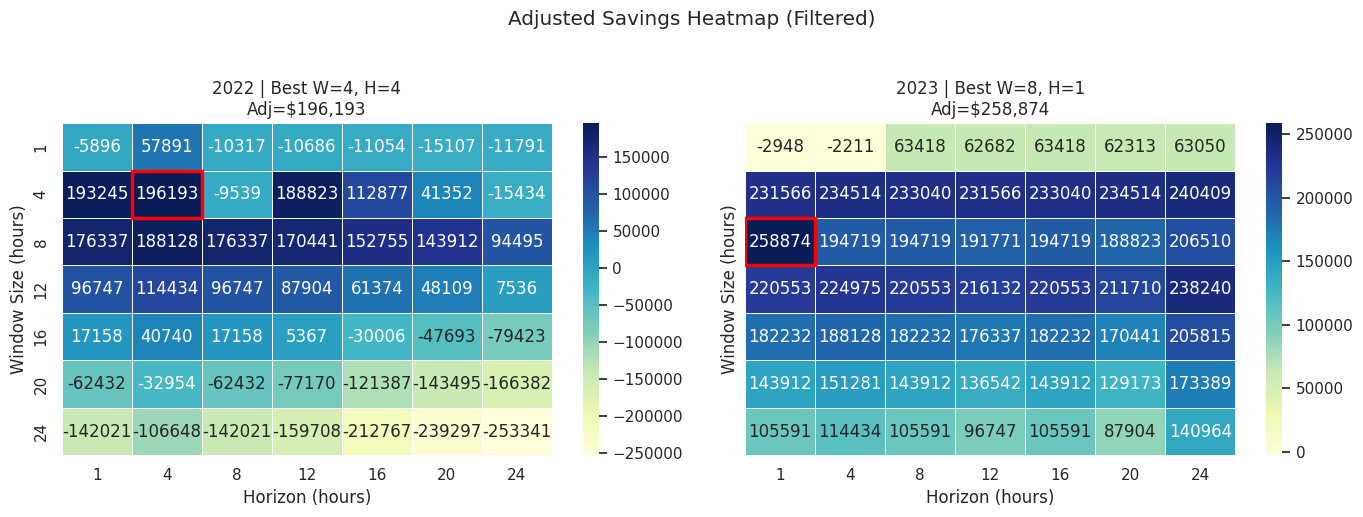


Best Window-Horizon by Year (Filtered):
 Year  Best_Window  Best_Horizon  Best_Adjusted_Savings
 2022            4             4              196192.68
 2023            8             1              258874.24


In [ ]:
# ============================================================================
# HEATMAP: FILTERED WINDOW x HORIZON COMBINATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------- FILTERS (edit these) --------
years_filter = [2022, 2023]
window_filter = [1,4, 8, 12, 16, 20, 24]
horizon_filter = [1, 4, 8, 12, 16, 20, 24]
# --------------------------------------

if window_results_df.empty:
    print("No optimization results available for heatmap.")
else:
    # Apply filters
    viz_df = window_results_df[
        window_results_df["Year"].isin(years_filter) &
        window_results_df["Window_Size"].isin(window_filter) &
        window_results_df["Horizon"].isin(horizon_filter)
    ].copy()

    if viz_df.empty:
        print("No rows left after filtering. Check filter values.")
    else:
        windows_analyzed = sorted(viz_df["Window_Size"].unique())
        horizons_analyzed = sorted(viz_df["Horizon"].unique())
        years_analyzed = sorted(viz_df["Year"].unique())

        n_years = len(years_analyzed)
        fig, axes = plt.subplots(1, n_years, figsize=(7 * n_years, 5), sharey=True)
        if n_years == 1:
            axes = [axes]

        best_rows = []

        for ax, year in zip(axes, years_analyzed):
            df_year = viz_df[viz_df["Year"] == year].copy()

            heat = (
                df_year.pivot_table(
                    index="Window_Size",
                    columns="Horizon",
                    values="Adjusted_Savings",
                    aggfunc="mean"
                )
                .reindex(index=windows_analyzed, columns=horizons_analyzed)
            )

            sns.heatmap(
                heat,
                annot=True,
                fmt=".0f",
                cmap="YlGnBu",
                linewidths=0.4,
                cbar=True,
                ax=ax
            )

            s = heat.stack(dropna=True)
            if len(s) > 0:
                best_window, best_horizon = s.idxmax()
                best_value = s.max()

                r = list(heat.index).index(best_window)
                c = list(heat.columns).index(best_horizon)
                ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="red", linewidth=2.5))

                ax.set_title(f"{year} | Best W={best_window}, H={best_horizon}\nAdj=${best_value:,.0f}")
                best_rows.append({
                    "Year": year,
                    "Best_Window": best_window,
                    "Best_Horizon": best_horizon,
                    "Best_Adjusted_Savings": best_value
                })
            else:
                ax.set_title(f"{year} | No valid cells")

            ax.set_xlabel("Horizon (hours)")
            ax.set_ylabel("Window Size (hours)")

        plt.suptitle("Adjusted Savings Heatmap (Filtered)", y=1.03)
        plt.tight_layout()
        plt.show()

        if best_rows:
            best_df = pd.DataFrame(best_rows)
            print("\nBest Window-Horizon by Year (Filtered):")
            print(best_df.to_string(index=False))

In [ ]:
# ============================================================================
# SAVINGS + IESO TOP-5 PENALTY HELPERS
# ============================================================================

SAVINGS_SLOPE = -368.47
SAVINGS_INTERCEPT = 335516
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT / 5


def calculate_savings(num_peak_hours):
    """
    Base savings only.
    Formula: y = -368.47x + 335516
    """
    if num_peak_hours <= 0:
        return 0.0
    return SAVINGS_SLOPE * num_peak_hours + SAVINGS_INTERCEPT


def calculate_ieso_top5_penalty(peaks_updated_df, year, ieso_top5_peaks):
    """
    Penalize each missed IESO top-5 event by 1/5 of total possible savings.

    A top-5 event is missed if:
    - there is no predicted window for that day, or
    - the exact IESO timestamp is not inside the predicted window
    """
    if year not in ieso_top5_peaks:
        return 0.0, 0, []

    missed_count = 0
    details = []

    for peak_info in ieso_top5_peaks[year]:
        peak_date = pd.to_datetime(peak_info['date']).normalize()
        ieso_timestamp = peak_date + pd.Timedelta(hours=peak_info['hour_ending'] - 1)

        day_row = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_row) == 0:
            captured = False
            window_start = pd.NaT
            window_end = pd.NaT
        else:
            day_row = day_row.iloc[0]
            window_start = day_row.get('predicted_window_start', pd.NaT)
            window_end = day_row.get('predicted_window_end', pd.NaT)

            captured = (
                pd.notna(window_start) and
                pd.notna(window_end) and
                pd.to_datetime(window_start) <= ieso_timestamp <= pd.to_datetime(window_end)
            )

        if not captured:
            missed_count += 1

        details.append({
            'year': year,
            'rank': peak_info['rank'],
            'date': peak_date,
            'ieso_timestamp': ieso_timestamp,
            'predicted_window_start': window_start,
            'predicted_window_end': window_end,
            'captured': captured
        })

    penalty = missed_count * PENALTY_PER_TOP5_MISSED
    return penalty, missed_count, details


# ============================================================================
# WINDOW SIZE OPTIMIZATION ANALYSIS
# Previous-year z-score hourly labels + daily window detection
# ============================================================================

print(f"\n{'='*70}")
print("=== Window Size Optimization Analysis ===")
print(f"{'='*70}")

window_sizes_to_test = [4,5,6,7,8,9,10]
horizons_to_optimize = [4, 8, 12, 16, 20, 24]
years_to_analyze = [2021, 2022, 2023]

window_optimization_results = []

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    df_horizon = df_horizon[df_horizon["year"].isin(years_to_analyze)].copy()

    if len(df_horizon) == 0:
        print(f"No data for horizon {horizon} in selected years.")
        continue

    for window_size in window_sizes_to_test:
        print(f"  Testing window size = {window_size} hour(s)")

        # Use detect_peaks_daily if available for prev-year labeled data.
        # If not, replace with your labeled detect_peaks_updated(df_horizon, window_hours=window_size).
        peaks_updated = detect_peaks_daily(
            df_horizon,
            window_hours=window_size
        )

        for year in years_to_analyze:
            year_data = peaks_updated[peaks_updated["year"] == year].copy()

            if len(year_data) == 0:
                continue

            TP_y = (year_data["classification"] == "TP").sum()
            FP_y = (year_data["classification"] == "FP").sum()
            FN_y = (year_data["classification"] == "FN").sum()
            TN_y = (year_data["classification"] == "TN").sum()

            total_days_active = TP_y + FP_y
            total_hours_active = total_days_active * window_size

            # Base savings
            total_savings = calculate_savings(total_hours_active)

            # Exact IESO top-5 penalty
            penalty, missed_top5_count, top5_details = calculate_ieso_top5_penalty(
                peaks_updated_df=year_data,
                year=year,
                ieso_top5_peaks=IESO_TOP5_PEAKS
            )

            adjusted_savings = total_savings - penalty

            window_optimization_results.append({
                "Horizon": horizon,
                "Window_Size": window_size,
                "Year": year,
                "TP": int(TP_y),
                "FP": int(FP_y),
                "FN": int(FN_y),
                "TN": int(TN_y),
                "Hours_Active": int(total_hours_active),
                "Total_Savings": total_savings,
                "Missed_IESO_Top5": int(missed_top5_count),
                "Penalty": penalty,
                "Adjusted_Savings": adjusted_savings
            })

window_results_df = pd.DataFrame(window_optimization_results)

# ============================================================================
# SUMMARY
# ============================================================================

print(f"\n{'='*70}")
print("=== Window Size Optimization Summary ===")
print(f"{'='*70}")

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    horizon_data = window_results_df[window_results_df["Horizon"] == horizon].copy()

    summary_list = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data["Window_Size"] == window_size]

        for year in years_to_analyze:
            year_window = window_data[window_data["Year"] == year]
            if len(year_window) > 0:
                row = year_window.iloc[0]
                summary_list.append({
                    "Window": window_size,
                    "Year": year,
                    "TP": row["TP"],
                    "FP": row["FP"],
                    "FN": row["FN"],
                    "TN": row["TN"],
                    "Hours": row["Hours_Active"],
                    "Savings": row["Total_Savings"],
                    "Missed_IESO_Top5": row["Missed_IESO_Top5"],
                    "Penalty": row["Penalty"],
                    "Adj_Savings": row["Adjusted_Savings"]
                })

    summary_df = pd.DataFrame(summary_list)

    if len(summary_df) > 0:
        print("\nBy Year:")
        print(summary_df.to_string(index=False))

        print(f"\n{'='*70}")
        print("Best Window Size by Year (Adjusted Savings):")
        print(f"{'='*70}")
        for year in years_to_analyze:
            year_summary = summary_df[summary_df["Year"] == year]
            if len(year_summary) > 0:
                best = year_summary.loc[year_summary["Adj_Savings"].idxmax()]
                print(
                    f"Year {year}: Window = {best['Window']}h "
                    f"(Adj Savings: ${best['Adj_Savings']:,.2f}, "
                    f"Hours: {best['Hours']}, "
                    f"Missed IESO Top5: {best['Missed_IESO_Top5']}, "
                    f"TP: {best['TP']}, FP: {best['FP']}, FN: {best['FN']})"
                )

    overall_summary = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data["Window_Size"] == window_size]
        if len(window_data) > 0:
            overall_summary.append({
                "Window": window_size,
                "TP": window_data["TP"].sum(),
                "FP": window_data["FP"].sum(),
                "FN": window_data["FN"].sum(),
                "TN": window_data["TN"].sum(),
                "Hours": window_data["Hours_Active"].sum(),
                "Savings": window_data["Total_Savings"].sum(),
                "Missed_IESO_Top5": window_data["Missed_IESO_Top5"].sum(),
                "Penalty": window_data["Penalty"].sum(),
                "Adj_Savings": window_data["Adjusted_Savings"].sum()
            })

    overall_df = pd.DataFrame(overall_summary)

    if len(overall_df) > 0:
        print(f"\n{'='*70}")
        print("=== Overall Summary (All Years Combined) ===")
        print(f"{'='*70}")
        print(overall_df.to_string(index=False))

        best_overall = overall_df.loc[overall_df["Adj_Savings"].idxmax()]
        print(f"\n{'='*70}")
        print(f"Best Overall Window Size: {best_overall['Window']} hours")
        print(f"  Adjusted Savings: ${best_overall['Adj_Savings']:,.2f}")
        print(f"  Total Savings: ${best_overall['Savings']:,.2f}")
        print(f"  Total Penalty: ${best_overall['Penalty']:,.2f}")
        print(f"  Missed IESO Top5: {best_overall['Missed_IESO_Top5']}")
        print(f"  Total Hours: {best_overall['Hours']}")
        print(
            f"  TP: {best_overall['TP']}, "
            f"FP: {best_overall['FP']}, "
            f"FN: {best_overall['FN']}, "
            f"TN: {best_overall['TN']}"
        )
        print(f"{'='*70}")




=== Window Size Optimization Analysis ===

Horizon 4
  Testing window size = 4 hour(s)
  Testing window size = 5 hour(s)
  Testing window size = 6 hour(s)
  Testing window size = 7 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 9 hour(s)
  Testing window size = 10 hour(s)

Horizon 8
  Testing window size = 4 hour(s)
  Testing window size = 5 hour(s)
  Testing window size = 6 hour(s)
  Testing window size = 7 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 9 hour(s)
  Testing window size = 10 hour(s)

Horizon 12
  Testing window size = 4 hour(s)
  Testing window size = 5 hour(s)
  Testing window size = 6 hour(s)
  Testing window size = 7 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 9 hour(s)
  Testing window size = 10 hour(s)

Horizon 16
  Testing window size = 4 hour(s)
  Testing window size = 5 hour(s)
  Testing window size = 6 hour(s)
  Testing window size = 7 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 

In [ ]:
# ============================================================================
# HEATMAP: FILTERED WINDOW x HORIZON COMBINATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------- FILTERS (edit these) --------
years_filter = [2022, 2023]
window_filter = [1,4, 8, 12, 16, 20, 24]
horizon_filter = [1, 4, 8, 12, 16, 20, 24]
# --------------------------------------

if window_results_df.empty:
    print("No optimization results available for heatmap.")
else:
    # Apply filters
    viz_df = window_results_df[
        window_results_df["Year"].isin(years_filter) &
        window_results_df["Window_Size"].isin(window_filter) &
        window_results_df["Horizon"].isin(horizon_filter)
    ].copy()

    if viz_df.empty:
        print("No rows left after filtering. Check filter values.")
    else:
        windows_analyzed = sorted(viz_df["Window_Size"].unique())
        horizons_analyzed = sorted(viz_df["Horizon"].unique())
        years_analyzed = sorted(viz_df["Year"].unique())

        n_years = len(years_analyzed)
        fig, axes = plt.subplots(1, n_years, figsize=(7 * n_years, 5), sharey=True)
        if n_years == 1:
            axes = [axes]

        best_rows = []

        for ax, year in zip(axes, years_analyzed):
            df_year = viz_df[viz_df["Year"] == year].copy()

            heat = (
                df_year.pivot_table(
                    index="Window_Size",
                    columns="Horizon",
                    values="Adjusted_Savings",
                    aggfunc="mean"
                )
                .reindex(index=windows_analyzed, columns=horizons_analyzed)
            )

            sns.heatmap(
                heat,
                annot=True,
                fmt=".0f",
                cmap="YlGnBu",
                linewidths=0.4,
                cbar=True,
                ax=ax
            )

            s = heat.stack(dropna=True)
            if len(s) > 0:
                best_window, best_horizon = s.idxmax()
                best_value = s.max()

                r = list(heat.index).index(best_window)
                c = list(heat.columns).index(best_horizon)
                ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="red", linewidth=2.5))

                ax.set_title(f"{year} | Best W={best_window}, H={best_horizon}\nAdj=${best_value:,.0f}")
                best_rows.append({
                    "Year": year,
                    "Best_Window": best_window,
                    "Best_Horizon": best_horizon,
                    "Best_Adjusted_Savings": best_value
                })
            else:
                ax.set_title(f"{year} | No valid cells")

            ax.set_xlabel("Horizon (hours)")
            ax.set_ylabel("Window Size (hours)")

        plt.suptitle("Adjusted Savings Heatmap (Filtered)", y=1.03)
        plt.tight_layout()
        plt.show()

        if best_rows:
            best_df = pd.DataFrame(best_rows)
            print("\nBest Window-Horizon by Year (Filtered):")
            print(best_df.to_string(index=False))

/tmp/ipykernel_29795/2601537832.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = heat.stack(dropna=True)
/tmp/ipykernel_29795/2601537832.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = heat.stack(dropna=True)
/tmp/ipykernel_29795/2601537832.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  s = heat.stack(dropna=True)


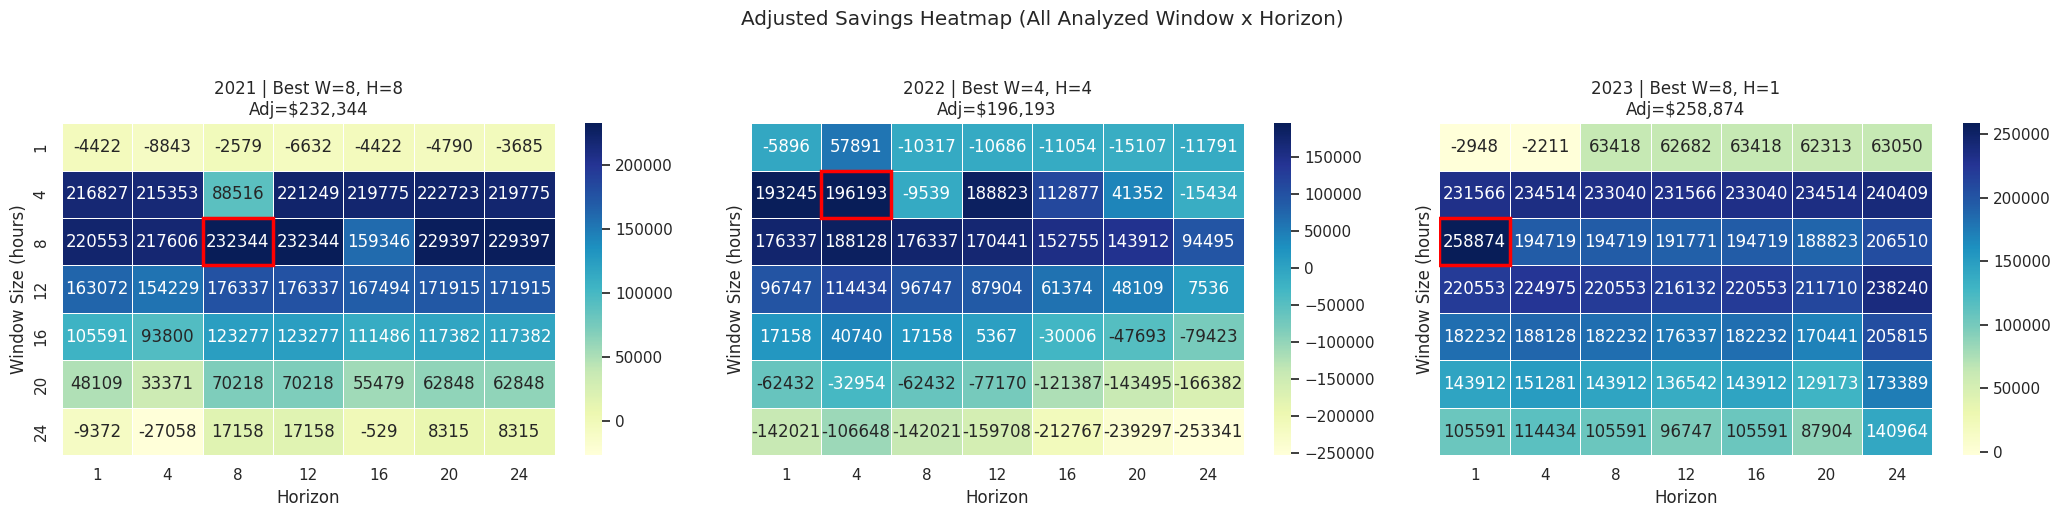


Best Window-Horizon by Year:
 Year  Best_Window  Best_Horizon  Best_Adjusted_Savings
 2021            8             8              232344.40
 2022            4             4              196192.68
 2023            8             1              258874.24


In [ ]:
# ============================================================================
# HEATMAP: ALL ANALYZED WINDOW x HORIZON COMBINATIONS (from window_results_df)
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if window_results_df.empty:
    print("No optimization results available for heatmap.")
else:
    # Use ONLY combinations that were actually analyzed
    windows_analyzed = sorted(window_results_df["Window_Size"].unique())
    horizons_analyzed = sorted(window_results_df["Horizon"].unique())
    years_analyzed = sorted(window_results_df["Year"].unique())  # or years_to_analyze

    n_years = len(years_analyzed)
    fig, axes = plt.subplots(1, n_years, figsize=(7 * n_years, 5), sharey=True)
    if n_years == 1:
        axes = [axes]

    best_rows = []

    for ax, year in zip(axes, years_analyzed):
        df_year = window_results_df[window_results_df["Year"] == year].copy()

        # Matrix: rows=Window_Size, cols=Horizon, values=Adjusted_Savings
        heat = (
            df_year.pivot_table(
                index="Window_Size",
                columns="Horizon",
                values="Adjusted_Savings",
                aggfunc="mean"
            )
            .reindex(index=windows_analyzed, columns=horizons_analyzed)
        )

        sns.heatmap(
            heat,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu",
            linewidths=0.4,
            cbar=True,
            ax=ax
        )

        # Highlight best analyzed combo for this year
        s = heat.stack(dropna=True)
        if len(s) > 0:
            best_window, best_horizon = s.idxmax()
            best_value = s.max()

            r = list(heat.index).index(best_window)
            c = list(heat.columns).index(best_horizon)
            ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor="red", linewidth=2.5))

            ax.set_title(f"{year} | Best W={best_window}, H={best_horizon}\nAdj=${best_value:,.0f}")

            best_rows.append({
                "Year": year,
                "Best_Window": best_window,
                "Best_Horizon": best_horizon,
                "Best_Adjusted_Savings": best_value
            })
        else:
            ax.set_title(f"{year} | No valid cells")

        ax.set_xlabel("Horizon")
        ax.set_ylabel("Window Size (hours)")

    plt.suptitle("Adjusted Savings Heatmap (All Analyzed Window x Horizon)", y=1.03)
    plt.tight_layout()
    plt.show()

    # Optional: print best combo table
    if best_rows:
        best_df = pd.DataFrame(best_rows)
        print("\nBest Window-Horizon by Year:")
        print(best_df.to_string(index=False))

## optimize the window hour and parametric analysis

In [ ]:
# ============================================================================
# SAVINGS + IESO TOP-5 PENALTY HELPERS
# ============================================================================

SAVINGS_SLOPE = -368.47
SAVINGS_INTERCEPT = 335516
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT / 5


def calculate_savings(num_peak_hours):
    """
    Base savings only.
    Formula: y = -368.47x + 335516
    """
    if num_peak_hours <= 0:
        return 0.0
    return SAVINGS_SLOPE * num_peak_hours + SAVINGS_INTERCEPT


def calculate_ieso_top5_penalty(peaks_updated_df, year, ieso_top5_peaks):
    """
    Penalize each missed IESO top-5 event by 1/5 of total possible savings.

    A top-5 event is missed if:
    - there is no predicted window for that day, or
    - the exact IESO timestamp is not inside the predicted window
    """
    if year not in ieso_top5_peaks:
        return 0.0, 0, []

    missed_count = 0
    details = []

    for peak_info in ieso_top5_peaks[year]:
        peak_date = pd.to_datetime(peak_info['date']).normalize()
        ieso_timestamp = peak_date + pd.Timedelta(hours=peak_info['hour_ending'] - 1)

        day_row = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_row) == 0:
            captured = False
            window_start = pd.NaT
            window_end = pd.NaT
        else:
            day_row = day_row.iloc[0]
            window_start = day_row.get('predicted_window_start', pd.NaT)
            window_end = day_row.get('predicted_window_end', pd.NaT)

            captured = (
                pd.notna(window_start) and
                pd.notna(window_end) and
                pd.to_datetime(window_start) <= ieso_timestamp <= pd.to_datetime(window_end)
            )

        if not captured:
            missed_count += 1

        details.append({
            'year': year,
            'rank': peak_info['rank'],
            'date': peak_date,
            'ieso_timestamp': ieso_timestamp,
            'predicted_window_start': window_start,
            'predicted_window_end': window_end,
            'captured': captured
        })

    penalty = missed_count * PENALTY_PER_TOP5_MISSED
    return penalty, missed_count, details


# ============================================================================
# WINDOW SIZE OPTIMIZATION ANALYSIS
# Previous-year z-score hourly labels + daily window detection
# ============================================================================
print(f"\n{'='*70}")
print("=== Window Size Optimization Analysis ===")
print(f"{'='*70}")

# Updated ranges requested
window_sizes_to_test = [1, 4, 8, 12, 16, 20]
horizons_to_optimize = [8, 12, 16, 20, 24]
years_to_analyze = [2021, 2022, 2023]

window_optimization_results = []
top5_capture_results = []

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    df_horizon = df_horizon[df_horizon["year"].isin(years_to_analyze)].copy()

    if len(df_horizon) == 0:
        print(f"No data for horizon {horizon} in selected years.")
        continue

    for window_size in window_sizes_to_test:
        print(f"  Testing window size = {window_size} hour(s)")

        peaks_updated = detect_peaks_daily(
            df_horizon,
            window_hours=window_size
        )

        for year in years_to_analyze:
            year_data = peaks_updated[peaks_updated["year"] == year].copy()

            if len(year_data) == 0:
                continue

            TP_y = (year_data["classification"] == "TP").sum()
            FP_y = (year_data["classification"] == "FP").sum()
            FN_y = (year_data["classification"] == "FN").sum()
            TN_y = (year_data["classification"] == "TN").sum()

            total_days_active = TP_y + FP_y
            total_hours_active = total_days_active * window_size

            # Base savings from all activated windows (TP + FP)
            total_savings = calculate_savings(total_hours_active)

            # IESO top-5 penalty
            penalty, missed_top5_count, top5_details = calculate_ieso_top5_penalty(
                peaks_updated_df=year_data,
                year=year,
                ieso_top5_peaks=IESO_TOP5_PEAKS
            )

            adjusted_savings = total_savings - penalty
            top5_hit_rate = np.nan if year not in IESO_TOP5_PEAKS else (5 - missed_top5_count) / 5

            window_optimization_results.append({
                "Horizon": horizon,
                "Window_Size": window_size,
                "Year": year,
                "TP": int(TP_y),
                "FP": int(FP_y),
                "FN": int(FN_y),
                "TN": int(TN_y),
                "Total_Days_Active": int(total_days_active),
                "Hours_Active": int(total_hours_active),
                "Total_Savings": total_savings,
                "Missed_IESO_Top5": int(missed_top5_count),
                "Top5_Hit_Rate": top5_hit_rate,
                "Penalty": penalty,
                "Adjusted_Savings": adjusted_savings
            })

            for d in top5_details:
                top5_capture_results.append({
                    "Horizon": horizon,
                    "Window_Size": window_size,
                    "Year": year,
                    "IESO_Rank": d["rank"],
                    "IESO_Date": d["date"],
                    "IESO_Timestamp": d["ieso_timestamp"],
                    "Predicted_Window_Start": d["predicted_window_start"],
                    "Predicted_Window_End": d["predicted_window_end"],
                    "Captured": d["captured"]
                })

window_results_df = pd.DataFrame(window_optimization_results)
top5_capture_df = pd.DataFrame(top5_capture_results)

# ============================================================================
# SUMMARY TABLES
# ============================================================================
print(f"\n{'='*70}")
print("=== Window Size Optimization Summary ===")
print(f"{'='*70}")

# One row per horizon/window/year
window_results_df = window_results_df.sort_values(["Horizon", "Window_Size", "Year"]).reset_index(drop=True)

print("\nDetailed case-by-case results:")
print(window_results_df.to_string(index=False))

# Combined across years for each horizon/window
combined_summary_df = (
    window_results_df
    .groupby(["Horizon", "Window_Size"], as_index=False)
    .agg({
        "TP": "sum",
        "FP": "sum",
        "FN": "sum",
        "TN": "sum",
        "Total_Days_Active": "sum",
        "Hours_Active": "sum",
        "Total_Savings": "sum",
        "Missed_IESO_Top5": "sum",
        "Penalty": "sum",
        "Adjusted_Savings": "sum"
    })
)

combined_summary_df["Top5_Hit_Rate"] = (
    1 - combined_summary_df["Missed_IESO_Top5"] / (len(years_to_analyze) * 5)
)

print(f"\n{'='*70}")
print("=== Combined Summary Across All Years ===")
print(f"{'='*70}")
print(combined_summary_df.to_string(index=False))

# Best window by horizon
best_window_by_horizon_df = (
    combined_summary_df
    .loc[combined_summary_df.groupby("Horizon")["Adjusted_Savings"].idxmax()]
    .sort_values("Horizon")
    .reset_index(drop=True)
)

print(f"\n{'='*70}")
print("=== Best Window Size by Horizon (Adjusted Savings) ===")
print(f"{'='*70}")
print(best_window_by_horizon_df.to_string(index=False))

# Best overall case
if len(combined_summary_df) > 0:
    best_overall = combined_summary_df.loc[combined_summary_df["Adjusted_Savings"].idxmax()]

    print(f"\n{'='*70}")
    print("=== Best Overall Combination ===")
    print(f"{'='*70}")
    print(f"Horizon: {int(best_overall['Horizon'])}")
    print(f"Window Size: {int(best_overall['Window_Size'])} hours")
    print(f"Adjusted Savings: ${best_overall['Adjusted_Savings']:,.2f}")
    print(f"Total Savings: ${best_overall['Total_Savings']:,.2f}")
    print(f"Penalty: ${best_overall['Penalty']:,.2f}")
    print(f"Missed IESO Top5: {int(best_overall['Missed_IESO_Top5'])}")
    print(f"Top5 Hit Rate: {best_overall['Top5_Hit_Rate']:.2%}")
    print(f"Hours Active: {int(best_overall['Hours_Active'])}")
    print(f"TP={int(best_overall['TP'])}, FP={int(best_overall['FP'])}, FN={int(best_overall['FN'])}, TN={int(best_overall['TN'])}")
    print(f"{'='*70}")

# Optional: per-horizon yearly tables, kept close to your original structure
for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    horizon_data = window_results_df[window_results_df["Horizon"] == horizon].copy()
    if len(horizon_data) == 0:
        continue

    print("\nBy Year:")
    print(horizon_data[[
        "Window_Size", "Year", "TP", "FP", "FN", "TN",
        "Hours_Active", "Total_Savings", "Missed_IESO_Top5",
        "Penalty", "Adjusted_Savings"
    ]].to_string(index=False))

    print(f"\n{'='*70}")
    print("Best Window Size by Year (Adjusted Savings):")
    print(f"{'='*70}")
    for year in years_to_analyze:
        year_summary = horizon_data[horizon_data["Year"] == year]
        if len(year_summary) > 0:
            best = year_summary.loc[year_summary["Adjusted_Savings"].idxmax()]
            print(
                f"Year {year}: Window = {int(best['Window_Size'])}h "
                f"(Adj Savings: ${best['Adjusted_Savings']:,.2f}, "
                f"Hours: {int(best['Hours_Active'])}, "
                f"Missed IESO Top5: {int(best['Missed_IESO_Top5'])}, "
                f"TP: {int(best['TP'])}, FP: {int(best['FP'])}, FN: {int(best['FN'])})"
            )

# ============================================================================
# CSV EXPORTS
# ============================================================================
detailed_csv = "window_optimization_detailed_results.csv"
combined_csv = "window_optimization_combined_summary.csv"
best_horizon_csv = "window_optimization_best_window_by_horizon.csv"
top5_capture_csv = "window_optimization_top5_capture_detail.csv"

window_results_df.to_csv(detailed_csv, index=False)
combined_summary_df.to_csv(combined_csv, index=False)
best_window_by_horizon_df.to_csv(best_horizon_csv, index=False)
top5_capture_df.to_csv(top5_capture_csv, index=False)

print(f"\n{'='*70}")
print("CSV EXPORT COMPLETE")
print(f"{'='*70}")
print(f"Detailed results:         {detailed_csv}  | rows = {len(window_results_df)}")
print(f"Combined summary:        {combined_csv}   | rows = {len(combined_summary_df)}")
print(f"Best by horizon:         {best_horizon_csv} | rows = {len(best_window_by_horizon_df)}")
print(f"Top-5 capture detail:    {top5_capture_csv} | rows = {len(top5_capture_df)}")
print(f"{'='*70}")


=== Window Size Optimization Analysis ===

Horizon 8
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 12
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 16
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 20
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 24
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  

## top 30 peak analysis

In [ ]:
# ============================================================================
# TOP-30 PEAK PARAMETRIC ANALYSIS
# Previous-year z-score hourly labels + daily window detection
# No savings, no penalties
# ============================================================================

TOP_N_PEAKS = 30
window_sizes_to_test = [1, 4, 8, 12, 16, 20]
horizons_to_optimize = [8, 12, 16, 20, 24]
years_to_analyze = [2021, 2022, 2023]

print(f"\n{'='*70}")
print(f"=== Top-{TOP_N_PEAKS} Peak Parametric Analysis ===")
print(f"{'='*70}")


# ----------------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------------
def build_top_n_peak_events(df_horizon, year, top_n=30):
    """
    Build exact top-N peak-hour table for one year from actual load.
    """
    df_year = df_horizon[df_horizon["year"] == year].copy()

    if len(df_year) == 0:
        return pd.DataFrame(columns=[
            "Year", "Rank", "Peak_Timestamp", "Peak_Date",
            "Actual_At_Peak", "Forecast_At_Peak"
        ])

    top_n_df = (
        df_year.nlargest(top_n, "actual")[["actual", "forecast"]]
        .copy()
        .reset_index()
        .rename(columns={
            "index": "Peak_Timestamp",
            "actual": "Actual_At_Peak",
            "forecast": "Forecast_At_Peak"
        })
    )

    top_n_df["Peak_Timestamp"] = pd.to_datetime(top_n_df["Peak_Timestamp"])
    top_n_df["Peak_Date"] = top_n_df["Peak_Timestamp"].dt.normalize()
    top_n_df["Year"] = year
    top_n_df["Rank"] = np.arange(1, len(top_n_df) + 1)

    return top_n_df[[
        "Year", "Rank", "Peak_Timestamp", "Peak_Date",
        "Actual_At_Peak", "Forecast_At_Peak"
    ]]


def build_top_n_capture_detail(top_n_events_df, peaks_updated_df, horizon, window_size):
    """
    For each exact top-N peak timestamp, check whether the predicted window captured it.
    """
    detail_rows = []

    for _, peak_row in top_n_events_df.iterrows():
        peak_ts = pd.to_datetime(peak_row["Peak_Timestamp"])
        peak_date = pd.to_datetime(peak_row["Peak_Date"]).normalize()

        day_row = peaks_updated_df[peaks_updated_df["date"] == peak_date]

        if len(day_row) == 0:
            classification = "NoDailyRow"
            has_true_peak = False
            has_predicted_peak = False
            pred_start = pd.NaT
            pred_end = pd.NaT
            captured = False
            true_peak_timestamp = pd.NaT
            true_peak_hour = np.nan
            true_peak_demand = np.nan
            true_peak_zscore = np.nan
            predicted_window_sum = np.nan
        else:
            day_row = day_row.iloc[0]
            classification = day_row.get("classification", None)
            has_true_peak = day_row.get("has_true_peak", False)
            has_predicted_peak = day_row.get("has_predicted_peak", False)
            pred_start = day_row.get("predicted_window_start", pd.NaT)
            pred_end = day_row.get("predicted_window_end", pd.NaT)
            true_peak_timestamp = day_row.get("true_peak_timestamp", pd.NaT)
            true_peak_hour = day_row.get("true_peak_hour", np.nan)
            true_peak_demand = day_row.get("true_peak_demand", np.nan)
            true_peak_zscore = day_row.get("true_peak_zscore", np.nan)
            predicted_window_sum = day_row.get("predicted_window_sum", np.nan)

            captured = (
                pd.notna(pred_start) and
                pd.notna(pred_end) and
                pd.to_datetime(pred_start) <= peak_ts <= pd.to_datetime(pred_end)
            )

        detail_rows.append({
            "Horizon": horizon,
            "Window_Size": window_size,
            "Year": int(peak_row["Year"]),
            "Rank": int(peak_row["Rank"]),
            "Peak_Timestamp": peak_ts,
            "Peak_Date": peak_date,
            "Actual_At_Peak": peak_row["Actual_At_Peak"],
            "Forecast_At_Peak": peak_row["Forecast_At_Peak"],
            "Day_Classification": classification,
            "Has_True_Peak_Day": has_true_peak,
            "Has_Predicted_Peak_Day": has_predicted_peak,
            "True_Peak_Timestamp": true_peak_timestamp,
            "True_Peak_Hour": true_peak_hour,
            "True_Peak_Demand": true_peak_demand,
            "True_Peak_Zscore": true_peak_zscore,
            "Predicted_Window_Start": pred_start,
            "Predicted_Window_End": pred_end,
            "Predicted_Window_Sum": predicted_window_sum,
            "Captured": captured
        })

    return pd.DataFrame(detail_rows)


def calculate_confusion_metrics_from_daily(daily_df):
    TP = (daily_df["classification"] == "TP").sum()
    FP = (daily_df["classification"] == "FP").sum()
    FN = (daily_df["classification"] == "FN").sum()
    TN = (daily_df["classification"] == "TN").sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1_score = (
        2 * precision * recall / (precision + recall)
        if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0
        else np.nan
    )

    return {
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1_score
    }


def wrapped_hour_diff(h1, h2):
    diff = abs(int(h1) - int(h2))
    return min(diff, 24 - diff)


def calculate_displacement_score_from_daily(daily_df):
    """
    DS on daily rows: average wrapped hour difference between true peak and predicted window start.
    """
    valid = daily_df[
        daily_df["true_peak_timestamp"].notna() &
        daily_df["predicted_window_start"].notna()
    ].copy()

    if len(valid) == 0:
        return np.nan

    valid["hour_difference"] = valid.apply(
        lambda row: wrapped_hour_diff(
            pd.to_datetime(row["true_peak_timestamp"]).hour,
            pd.to_datetime(row["predicted_window_start"]).hour
        ),
        axis=1
    )

    return valid["hour_difference"].mean()


def safe_div(numerator, denominator):
    return numerator / denominator if denominator != 0 else np.nan


# ----------------------------------------------------------------------------
# MAIN LOOP
# ----------------------------------------------------------------------------
top30_case_results = []
top30_event_detail_results = []
top30_daily_detail_results = []

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    df_horizon = create_ontario_peak_dataframe_prev_year(
        ontario,
        city_frames,
        horizon=horizon,
        threshold=ZSCORE_THRESHOLD
    ).copy()

    df_horizon = df_horizon[df_horizon["year"].isin(years_to_analyze)].copy()

    if len(df_horizon) == 0:
        print(f"No data for horizon {horizon} in selected years.")
        continue

    for window_size in window_sizes_to_test:
        print(f"  Testing window size = {window_size} hour(s)")

        peaks_updated = detect_peaks_daily(
            df_horizon,
            window_hours=window_size
        ).copy()

        for year in years_to_analyze:
            year_data = peaks_updated[peaks_updated["year"] == year].copy()
            df_year_horizon = df_horizon[df_horizon["year"] == year].copy()

            if len(year_data) == 0 or len(df_year_horizon) == 0:
                continue

            # Exact top-30 peak events for this year
            top30_events_df = build_top_n_peak_events(
                df_year_horizon,
                year=year,
                top_n=TOP_N_PEAKS
            )

            if len(top30_events_df) == 0:
                continue

            # Event-level capture detail
            top30_detail_df = build_top_n_capture_detail(
                top30_events_df,
                year_data,
                horizon=horizon,
                window_size=window_size
            )

            # Restrict daily metrics to dates containing top-30 peak hours
            top30_dates = top30_events_df["Peak_Date"].drop_duplicates()
            top30_daily_df = year_data[year_data["date"].isin(top30_dates)].copy()

            confusion = calculate_confusion_metrics_from_daily(top30_daily_df)

            top30_events = int(len(top30_detail_df))
            captured_top30 = int(top30_detail_df["Captured"].sum())
            missed_top30 = int((~top30_detail_df["Captured"]).sum())
            top30_hit_rate = safe_div(captured_top30, top30_events)
            ds_top30 = calculate_displacement_score_from_daily(top30_daily_df)

            top30_case_results.append({
                "Horizon": horizon,
                "Window_Size": window_size,
                "Year": year,
                "TopN": TOP_N_PEAKS,
                "Top30_Days": int(len(top30_dates)),
                "Top30_Events": top30_events,
                "Captured_Top30": captured_top30,
                "Missed_Top30": missed_top30,
                "Top30_Hit_Rate": top30_hit_rate,
                "DS_Top30_Days": ds_top30,
                **confusion
            })

            top30_event_detail_results.append(top30_detail_df)

            top30_daily_detail_results.append(
                top30_daily_df.assign(
                    Horizon=horizon,
                    Window_Size=window_size,
                    TopN=TOP_N_PEAKS
                )
            )

top30_results_df = pd.DataFrame(top30_case_results)

top30_event_detail_df = (
    pd.concat(top30_event_detail_results, ignore_index=True)
    if len(top30_event_detail_results) > 0 else
    pd.DataFrame()
)

top30_daily_detail_df = (
    pd.concat(top30_daily_detail_results, ignore_index=True)
    if len(top30_daily_detail_results) > 0 else
    pd.DataFrame()
)

# ----------------------------------------------------------------------------
# SUMMARY TABLES
# ----------------------------------------------------------------------------
print(f"\n{'='*70}")
print(f"=== Top-{TOP_N_PEAKS} Peak Summary ===")
print(f"{'='*70}")

if len(top30_results_df) == 0:
    print("No results generated.")
else:
    top30_results_df = top30_results_df.sort_values(
        ["Horizon", "Window_Size", "Year"]
    ).reset_index(drop=True)

    print("\nDetailed case-by-case results:")
    print(top30_results_df.to_string(index=False))

    combined_summary_df = (
        top30_results_df
        .groupby(["Horizon", "Window_Size"], as_index=False)
        .agg({
            "Top30_Days": "sum",
            "Top30_Events": "sum",
            "Captured_Top30": "sum",
            "Missed_Top30": "sum",
            "TP": "sum",
            "FP": "sum",
            "FN": "sum",
            "TN": "sum"
        })
    )

    combined_summary_df["Top30_Hit_Rate"] = combined_summary_df.apply(
        lambda row: safe_div(row["Captured_Top30"], row["Top30_Events"]), axis=1
    )
    combined_summary_df["Accuracy"] = combined_summary_df.apply(
        lambda row: safe_div(row["TP"] + row["TN"], row["TP"] + row["FP"] + row["FN"] + row["TN"]), axis=1
    )
    combined_summary_df["Precision"] = combined_summary_df.apply(
        lambda row: safe_div(row["TP"], row["TP"] + row["FP"]), axis=1
    )
    combined_summary_df["Recall"] = combined_summary_df.apply(
        lambda row: safe_div(row["TP"], row["TP"] + row["FN"]), axis=1
    )
    combined_summary_df["F1_Score"] = combined_summary_df.apply(
        lambda row: (
            2 * row["Precision"] * row["Recall"] / (row["Precision"] + row["Recall"])
            if pd.notna(row["Precision"]) and pd.notna(row["Recall"]) and (row["Precision"] + row["Recall"]) > 0
            else np.nan
        ),
        axis=1
    )

    print(f"\n{'='*70}")
    print("=== Combined Summary Across All Years ===")
    print(f"{'='*70}")
    print(combined_summary_df.to_string(index=False))

    # Best by Top-30 hit rate
    best_hit_rate_by_horizon_df = (
        combined_summary_df
        .loc[combined_summary_df.groupby("Horizon")["Top30_Hit_Rate"].idxmax()]
        .sort_values("Horizon")
        .reset_index(drop=True)
    )

    print(f"\n{'='*70}")
    print("=== Best Window Size by Horizon (Top-30 Hit Rate) ===")
    print(f"{'='*70}")
    print(best_hit_rate_by_horizon_df.to_string(index=False))

    # Best by F1
    best_f1_by_horizon_df = (
        combined_summary_df
        .loc[combined_summary_df.groupby("Horizon")["F1_Score"].idxmax()]
        .sort_values("Horizon")
        .reset_index(drop=True)
    )

    print(f"\n{'='*70}")
    print("=== Best Window Size by Horizon (F1 Score) ===")
    print(f"{'='*70}")
    print(best_f1_by_horizon_df.to_string(index=False))

    # Best overall by hit rate
    best_overall_hit_rate = combined_summary_df.loc[combined_summary_df["Top30_Hit_Rate"].idxmax()]

    print(f"\n{'='*70}")
    print(f"=== Best Overall Combination (Top-{TOP_N_PEAKS} Hit Rate) ===")
    print(f"{'='*70}")
    print(f"Horizon: {int(best_overall_hit_rate['Horizon'])}")
    print(f"Window Size: {int(best_overall_hit_rate['Window_Size'])} hours")
    print(f"Top-{TOP_N_PEAKS} Hit Rate: {best_overall_hit_rate['Top30_Hit_Rate']:.2%}")
    print(f"Captured Top-{TOP_N_PEAKS}: {int(best_overall_hit_rate['Captured_Top30'])}")
    print(f"Missed Top-{TOP_N_PEAKS}: {int(best_overall_hit_rate['Missed_Top30'])}")
    print(f"TP={int(best_overall_hit_rate['TP'])}, FP={int(best_overall_hit_rate['FP'])}, FN={int(best_overall_hit_rate['FN'])}, TN={int(best_overall_hit_rate['TN'])}")
    print(f"Precision={best_overall_hit_rate['Precision']:.4f}, Recall={best_overall_hit_rate['Recall']:.4f}, F1={best_overall_hit_rate['F1_Score']:.4f}")
    print(f"{'='*70}")

    # Best overall by F1
    best_overall_f1 = combined_summary_df.loc[combined_summary_df["F1_Score"].idxmax()]

    print(f"\n{'='*70}")
    print("=== Best Overall Combination (F1 Score) ===")
    print(f"{'='*70}")
    print(f"Horizon: {int(best_overall_f1['Horizon'])}")
    print(f"Window Size: {int(best_overall_f1['Window_Size'])} hours")
    print(f"Top-{TOP_N_PEAKS} Hit Rate: {best_overall_f1['Top30_Hit_Rate']:.2%}")
    print(f"Captured Top-{TOP_N_PEAKS}: {int(best_overall_f1['Captured_Top30'])}")
    print(f"Missed Top-{TOP_N_PEAKS}: {int(best_overall_f1['Missed_Top30'])}")
    print(f"TP={int(best_overall_f1['TP'])}, FP={int(best_overall_f1['FP'])}, FN={int(best_overall_f1['FN'])}, TN={int(best_overall_f1['TN'])}")
    print(f"Precision={best_overall_f1['Precision']:.4f}, Recall={best_overall_f1['Recall']:.4f}, F1={best_overall_f1['F1_Score']:.4f}")
    print(f"{'='*70}")

    # Per-horizon yearly tables
    for horizon in horizons_to_optimize:
        print(f"\n{'='*70}")
        print(f"Horizon {horizon}")
        print(f"{'='*70}")

        horizon_data = top30_results_df[top30_results_df["Horizon"] == horizon].copy()
        if len(horizon_data) == 0:
            continue

        print("\nBy Year:")
        print(horizon_data[[
            "Window_Size", "Year",
            "Top30_Days", "Top30_Events", "Captured_Top30", "Missed_Top30", "Top30_Hit_Rate",
            "TP", "FP", "FN", "TN", "Accuracy", "Precision", "Recall", "F1_Score", "DS_Top30_Days"
        ]].to_string(index=False))

        print(f"\n{'='*70}")
        print(f"Best Window Size by Year (Top-{TOP_N_PEAKS} Hit Rate):")
        print(f"{'='*70}")
        for year in years_to_analyze:
            year_summary = horizon_data[horizon_data["Year"] == year]
            if len(year_summary) > 0:
                best = year_summary.loc[year_summary["Top30_Hit_Rate"].idxmax()]
                print(
                    f"Year {year}: Window = {int(best['Window_Size'])}h "
                    f"(Hit Rate: {best['Top30_Hit_Rate']:.2%}, "
                    f"Captured: {int(best['Captured_Top30'])}/{int(best['Top30_Events'])}, "
                    f"TP: {int(best['TP'])}, FP: {int(best['FP'])}, FN: {int(best['FN'])}, "
                    f"Precision: {best['Precision']:.4f}, Recall: {best['Recall']:.4f}, F1: {best['F1_Score']:.4f})"
                )

# ----------------------------------------------------------------------------
# CSV EXPORTS
# ----------------------------------------------------------------------------
detailed_csv = f"top{TOP_N_PEAKS}_parametric_case_results.csv"
combined_csv = f"top{TOP_N_PEAKS}_parametric_combined_summary.csv"
best_hit_rate_csv = f"top{TOP_N_PEAKS}_best_window_by_horizon_hit_rate.csv"
best_f1_csv = f"top{TOP_N_PEAKS}_best_window_by_horizon_f1.csv"
event_detail_csv = f"top{TOP_N_PEAKS}_event_capture_detail.csv"
daily_detail_csv = f"top{TOP_N_PEAKS}_daily_detail_on_top_peak_days.csv"

top30_results_df.to_csv(detailed_csv, index=False)
combined_summary_df.to_csv(combined_csv, index=False)
best_hit_rate_by_horizon_df.to_csv(best_hit_rate_csv, index=False)
best_f1_by_horizon_df.to_csv(best_f1_csv, index=False)
top30_event_detail_df.to_csv(event_detail_csv, index=False)
top30_daily_detail_df.to_csv(daily_detail_csv, index=False)

print(f"\n{'='*70}")
print("CSV EXPORT COMPLETE")
print(f"{'='*70}")
print(f"Case results:            {detailed_csv} | rows = {len(top30_results_df)}")
print(f"Combined summary:        {combined_csv} | rows = {len(combined_summary_df)}")
print(f"Best by hit rate:        {best_hit_rate_csv} | rows = {len(best_hit_rate_by_horizon_df)}")
print(f"Best by F1:              {best_f1_csv} | rows = {len(best_f1_by_horizon_df)}")
print(f"Event capture detail:    {event_detail_csv} | rows = {len(top30_event_detail_df)}")
print(f"Daily detail:            {daily_detail_csv} | rows = {len(top30_daily_detail_df)}")
print(f"{'='*70}")


=== Top-30 Peak Parametric Analysis ===

Horizon 8
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 12
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 16
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 20
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Testing window size = 8 hour(s)
  Testing window size = 12 hour(s)
  Testing window size = 16 hour(s)
  Testing window size = 20 hour(s)

Horizon 24
  Testing window size = 1 hour(s)
  Testing window size = 4 hour(s)
  Te